# Set Up and Import



##Set up

In [ ]:
%pip install optuna optunahub
%pip install -r https://hub.optuna.org/samplers/auto_sampler/requirements.txt

In [2]:
import pandas as pd
import functools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns
import requests
from sklearn.metrics import root_mean_squared_error,mean_absolute_error,ndcg_score
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.special import expit
from scipy.stats import uniform, randint, loguniform, poisson, rankdata, norm, skellam
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn import set_config
import pulp
import json
import optuna
from optuna.samplers import GridSampler
import optunahub
import warnings
from datetime import datetime
import pytz
from tqdm.auto import tqdm
from typing import List, Callable
import re
import pickle
import gc
import os
import asyncio
import aiohttp
import time

warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARN)

In [3]:
module = optunahub.load_module(package="samplers/auto_sampler")

# Define Functions

## Pulling Data

In [4]:
def get_fpl_gameweek_summary():
    """
    Fetches the bootstrap-static data from the FPL API and extracts gameweek (event) summaries.

    Returns:
        pd.DataFrame: A pandas DataFrame containing details for each gameweek, or None if an error occurs.
    """
    api_url = "https://fantasy.premierleague.com/api/bootstrap-static/"

    try:
        # Make a GET request to the FPL API
        response = requests.get(api_url)
        response.raise_for_status() # Raise an exception for HTTP errors (4xx or 5xx)

        # Parse the JSON response
        data = response.json()

        # The gameweek information is under the 'events' key
        events = data.get('events', [])

        if not events:
            print("No event data found in the FPL API response.")
            return None

        # Prepare a list of dictionaries to easily convert to a DataFrame
        gameweek_data_list = []
        for event in events:
            gameweek_id = event.get('id')
            name = event.get('name')
            finished = event.get('finished')
            is_current = event.get('is_current')
            is_next = event.get('is_next')
            avg_points = event.get('average_entry_score')
            highest_score = event.get('highest_score')
            deadline_time = event.get('deadline_time')
            chip_plays = event.get('chip_plays')

            gameweek_data_list.append({
                "Gameweek ID": gameweek_id,
                "Name": name,
                "Finished": finished,
                "Is Current": is_current,
                "Is Next": is_next,
                "Average Score": avg_points,
                "Highest Score": highest_score,
                "Deadline Time": deadline_time,
                "Chip Plays": json.dumps(chip_plays) # Store chip plays as a JSON string for DataFrame compatibility
            })

        # Convert the list of dictionaries to a pandas DataFrame
        df = pd.DataFrame(gameweek_data_list)
        return df

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data from FPL API: {e}")
        return None
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON response: {e}")
        return None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None

In [5]:
def get_fpl_gameweek_data(fpl_id):
    """Fetches FPL history data and processes gameweek information.

    Args:
        fpl_id: The Fantasy Premier League ID.

    Returns:
        A pandas DataFrame containing processed gameweek data.
    """
    # Fetch static data (events)
    url_static = "https://fantasy.premierleague.com/api/bootstrap-static/"
    response_static = requests.get(url_static)
    response_static.raise_for_status()
    data_static = response_static.json()

    events_df = pd.DataFrame(data_static['events'])

    def extract_chip_plays(chip_list):
        chips = {}
        if isinstance(chip_list, list):
            for chip_info in chip_list:
                chips[chip_info['chip_name'] + "_played"] = chip_info['num_played']
        return chips

    chip_plays_df = events_df['chip_plays'].apply(extract_chip_plays).apply(pd.Series)
    events_df = pd.concat([events_df, chip_plays_df], axis=1)

    # Fetch user's history data
    url_history = f"https://fantasy.premierleague.com/api/entry/{fpl_id}/history"
    response_history = requests.get(url_history)
    response_history.raise_for_status()
    data_history = response_history.json()

    my_performance_df = pd.DataFrame(data_history['current'])

    # Check if 'chips' list is not empty before creating DataFrame
    if data_history.get('chips') and isinstance(data_history['chips'], list) and data_history['chips']:
        my_chips_df = pd.DataFrame(data_history['chips'])[['event', 'name']].rename(columns={'name': 'used_chip_name'})
    else:
        # Create an empty DataFrame with the expected columns if no chips are used
        my_chips_df = pd.DataFrame(columns=['event', 'used_chip_name'])


    my_performance_df = pd.merge(my_performance_df, my_chips_df, left_on='event', right_on='event', how='left')
    my_performance_df.columns = ["my_" + col for col in my_performance_df.columns]


    # Join dataframes on event/my_event
    fpl_gameweeks = pd.merge(events_df, my_performance_df, left_on='id', right_on='my_event', how='left')

    # Set relevant columns to NaN if gameweek is not finished
    unfinished_mask = fpl_gameweeks['finished'] == False
    fpl_gameweeks.loc[unfinished_mask, ['average_entry_score', 'highest_score', 'ranked_count','my_points']] = pd.NA


    fpl_gameweeks['my_overall_percentile_rank'] = round(1 - (fpl_gameweeks['my_overall_rank'] / fpl_gameweeks['ranked_count']),3)*100
    fpl_gameweeks['my_week_percentile_rank'] = round(1 - (fpl_gameweeks['my_rank'] / fpl_gameweeks['ranked_count']),3)*100

    return fpl_gameweeks[[
        'id', 'name', 'deadline_time', 'average_entry_score',
       'finished', 'data_checked', 'highest_score',
       'is_previous', 'is_current', 'is_next',
       'ranked_count', 'most_selected',
       'transfers_made', 'most_captained', 'most_vice_captained',
       'bboost_played', '3xc_played', 'freehit_played', 'wildcard_played',
       'my_total_points', 'my_rank',
       'my_overall_rank','my_overall_percentile_rank','my_points', 'my_week_percentile_rank', 'my_bank', 'my_value',
       'my_event_transfers', 'my_event_transfers_cost', 'my_points_on_bench','my_used_chip_name'
       ]].rename(columns={
        'id': 'gameweek_id',
        'my_points': 'my_week_points',})

In [6]:
def get_max_finished_gameweek():
    """
    Gets the maximum finished gameweek number from the gameweek summary DataFrame.

    Args:
        gameweek_summary_df (pd.DataFrame): DataFrame containing gameweek summaries.

    Returns:
        int or None: The maximum finished gameweek ID as an integer, or None if not found.
    """
    gameweek_summary_df = get_fpl_gameweek_summary()
    if gameweek_summary_df is None:
        print("Failed to fetch gameweek summary data.")
        return None
    finished_gameweeks_rows = gameweek_summary_df[gameweek_summary_df['Finished'] == True]
    if not finished_gameweeks_rows.empty:
        # Ensure the 'Gameweek ID' is treated as an integer
        return int(finished_gameweeks_rows['Gameweek ID'].max())
    else:
        print("No finished gameweeks found in gameweek_summary.")
        return None

In [7]:
def get_current_gameweek():
    """
    Gets the maximum finished gameweek number from the gameweek summary DataFrame.

    Args:
        gameweek_summary_df (pd.DataFrame): DataFrame containing gameweek summaries.

    Returns:
        int or None: The maximum finished gameweek ID as an integer, or None if not found.
    """
    gameweek_summary_df = get_fpl_gameweek_summary()
    if gameweek_summary_df is None:
        print("Failed to fetch gameweek summary data.")
        return None
    current_gameweeks_rows = gameweek_summary_df[gameweek_summary_df['Is Current'] == True]
    if not current_gameweeks_rows.empty:
        # Ensure the 'Gameweek ID' is treated as an integer
        return int(current_gameweeks_rows['Gameweek ID'].iloc[0])
    else:
        print("No finished gameweeks found in gameweek_summary.")
        return None

In [8]:
def get_my_player_ids(manager_id, gameweek=1):
    """
    Fetches the list of player IDs for a specific FPL manager's team.
    This is used to get your initial squad.
    """
    try:
        url = f"https://fantasy.premierleague.com/api/entry/{manager_id}/event/{gameweek}/picks/"
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()
        if data['active_chip'] == 'freehit':
            if gameweek <= 1:
                print("Free hit used in GW1. Fetching current GW team IDs instead.")
                return [player['element'] for player in data['picks']]

            print(f"Free hit was used in previous week, fetching your team IDs from Gameweek {gameweek-1} instead")
            return get_my_player_ids(manager_id, gameweek-1)
        else:
          player_ids = [player['element'] for player in data['picks']]
          print(f"Successfully fetched your team IDs for Gameweek {gameweek}:")
          print(player_ids)
          return player_ids
    except requests.exceptions.RequestException as e:
        print(f"Error fetching your team data: {e}")
        print("Please check if your FPL Manager ID is correct.")
        return []

In [9]:
def get_current_players_df():
    """
    Fetches current player data and adds average minutes from the last 2 finished Gameweeks
    using the optimized 'live' endpoint to minimize API calls.
    """
    # 1. Fetch Base Data (Bootstrap Static)
    base_url = "https://fantasy.premierleague.com/api/bootstrap-static/"
    response = requests.get(base_url)
    response.raise_for_status()
    data = response.json()

    # Create base dataframes
    elements_df = pd.DataFrame(data['elements'])
    teams_df = pd.DataFrame(data['teams'])
    pos_df = pd.DataFrame(data['element_types'])
    events_df = pd.DataFrame(data['events'])

    # ------------------------------------------------------------------

    # Standard Transformations (Your original logic)
    if 'now_cost' in elements_df.columns:
      elements_df['now_cost'] = elements_df['now_cost'] / 10.0

    pos_map = pos_df.set_index('id')['singular_name_short']
    team_map = teams_df.set_index('id')['name']
    elements_df['position'] = elements_df['element_type'].map(pos_map)
    elements_df['team_name'] = elements_df['team'].map(team_map)

    # Handle numeric columns safely
    numeric_cols = ['total_points', 'points_per_game', 'starts', 'minutes',
                'influence', 'creativity', 'threat', 'ict_index',
                'yellow_cards', 'red_cards', 'saves', 'goals_scored',
                'expected_goals', 'expected_assists', 'expected_goal_involvements',
                'expected_goals_conceded', 'goals_conceded', 'clean_sheets']

    # Ensure columns exist and fill NaNs before division
    for col in numeric_cols:
        if col not in elements_df.columns:
            elements_df[col] = 0
        elements_df[col] = pd.to_numeric(elements_df[col], errors='coerce').fillna(0)

    # Metric Calculations
    elements_df['game_played'] = round(elements_df['total_points'] / (elements_df['points_per_game'] + 1e-10),0)
    elements_df['start_per_gameplayed'] = (elements_df['starts'] / (elements_df['game_played'] + 1e-10))
    elements_df['start_share_total_game'] = (elements_df['starts'] / (get_current_gameweek() + 1e-10))
    elements_df['minutes_per_game'] = (elements_df['minutes'] / (elements_df['game_played'] + 1e-10)).clip(lower=0, upper=90)

    elements_df['influence_per_90'] = elements_df['influence'] / (elements_df['minutes'] + 1e-10) * 90
    elements_df['creativity_per_90'] = elements_df['creativity'] / (elements_df['minutes'] + 1e-10 ) * 90
    elements_df['threat_per_90'] = elements_df['threat'] / (elements_df['minutes'] + 1e-10) * 90
    elements_df['ict_index_per_90'] = elements_df['ict_index'] / (elements_df['minutes'] + 1e-10) * 90

    elements_df['bps_per_90'] = elements_df['bps'] / (elements_df['minutes'] + 1e-10) * 90
    elements_df['bonus_per_90'] = elements_df['bonus'] / (elements_df['minutes'] + 1e-10) * 90

    elements_df['yellow_cards_per_90'] = elements_df['yellow_cards'] / (elements_df['minutes'] + 1e-10) * 90
    elements_df['red_cards_index_per_90'] = elements_df['red_cards'] / (elements_df['minutes'] + 1e-10) * 90
    elements_df['saves_per_90'] = elements_df['saves'] / (elements_df['minutes'] + 1e-10) * 90

    # Calculate global means across the whole dataset (excluding players with 0 mins)
    active_players = elements_df[elements_df['minutes'] > 0]
    mean_goals = (active_players['goals_scored'].sum() / (active_players['minutes'].sum() + 1e-10)) * 90
    mean_xg = (active_players['expected_goals'].sum() / (active_players['minutes'].sum() + 1e-10)) * 90
    mean_GC = (active_players['goals_conceded'].sum() / (active_players['minutes'].sum() + 1e-10)) * 90
    mean_xGC = (active_players['expected_goals_conceded'].sum() / (active_players['minutes'].sum() + 1e-10)) * 90

    # C is your "confidence" in the prior. Events (Goals/xG) are rare. You need a higher threshold to avoid "luck" bias.
    # Add as parameter or global constant with comment
    C_FINISHING  = 20     # ~20–25 most common for goals/xG in PL
    C_PROTECTIVE = 30     # slightly higher for GK/defenders (goals conceded are even noisier)
                          # because defenders/GKs face more events but variance remains high

    # Then use separately if desired:
    elements_df['finishing_factor'] = (
        (elements_df['goals_scored']   + C_FINISHING  * mean_goals) /
        (elements_df['expected_goals'] + C_FINISHING  * mean_xg)
    )

    elements_df['protective_factor'] = (
        (elements_df['goals_conceded']         + C_PROTECTIVE * mean_GC) /
        (elements_df['expected_goals_conceded'] + C_PROTECTIVE * mean_xGC)
    )

    elements_df['total_non_minutes_points'] = elements_df['total_points'] - (elements_df['game_played'] * ((elements_df['minutes_per_game'] > 0).astype(int) + (elements_df['minutes_per_game'] >= 60).astype(int)))

    # Added necessary columns for calculation to the return list if they were missing
    return elements_df[[
            'id', 'now_cost', 'selected_by_percent', 'team', 'web_name',
            'position', 'team_name', 'game_played', 'total_points',
            'points_per_game','form',
            'starts_per_90', 'starts',
            'start_per_gameplayed' ,
            'start_share_total_game',
            'chance_of_playing_this_round',
            'chance_of_playing_next_round', 'minutes_per_game',
            'minutes',
            'finishing_factor',
            'protective_factor',
            'expected_goals',
            'goals_scored',
            'expected_assists',
            'assists',
            'goals_conceded',
            'expected_goals_conceded',
            'clean_sheets',
            'total_non_minutes_points',
            'ict_index',
            'creativity',
            'threat',
            'bps_per_90',
            'bonus_per_90',
            'yellow_cards_per_90', 'red_cards_index_per_90', 'saves_per_90',
            'influence_per_90', 'creativity_per_90', 'threat_per_90',
            'ict_index_per_90', 'expected_goals_per_90',
            'expected_assists_per_90', 'expected_goal_involvements_per_90',
            'expected_goals_conceded_per_90', 'goals_conceded_per_90',
            'clean_sheets_per_90','defensive_contribution_per_90'
    ]]

In [10]:
def get_pos_constraint_df():
    url = "https://fantasy.premierleague.com/api/bootstrap-static/"
    response = requests.get(url)
    response.raise_for_status()
    data = response.json()

    pos_df = pd.DataFrame(data['element_types'])

    return pos_df[
        ['id',
         'singular_name_short',
         'squad_select',
         'squad_min_play',
         'squad_max_play',
       ]
        ]

In [11]:
def get_team_df():
    url = "https://fantasy.premierleague.com/api/bootstrap-static/"
    response = requests.get(url)
    response.raise_for_status()
    data = response.json()

    team_df = pd.DataFrame(data['element_types'])

    return pd.DataFrame(data['teams'])[['code', 'id', 'name',
       'position', 'short_name', 'strength','strength_overall_home', 'strength_overall_away',
       'strength_attack_home', 'strength_attack_away', 'strength_defence_home',
       'strength_defence_away', 'pulse_id']]

In [12]:
def get_fixture_df():
    url = "https://fantasy.premierleague.com/api/fixtures/"
    response = requests.get(url)
    response.raise_for_status()
    data = response.json()

    # 1. Load the initial data (Added scores and finished status)
    df = pd.DataFrame(data)[['event', 'id', 'kickoff_time', 'team_a', 'team_h',
                             'team_a_score', 'team_h_score', 'finished', 'stats']]

    # 2. Create the "Home" perspective DataFrame
    df_home = df.rename(columns={
        'team_h': 'team',
        'team_a': 'opponent',
        'team_h_score': 'team_score',
        'team_a_score': 'opponent_score'
    })
    df_home['is_home'] = True

    # 3. Create the "Away" perspective DataFrame
    df_away = df.rename(columns={
        'team_a': 'team',
        'team_h': 'opponent',
        'team_a_score': 'team_score',
        'team_h_score': 'opponent_score'
    })
    df_away['is_home'] = False

    # 4. Concatenate them together and sort
    final_df = pd.concat([df_home, df_away])
    final_df = final_df.sort_values(by=['id', 'kickoff_time'])
    final_df = final_df.rename(columns={'event': 'gameweek'})

    # 5. Return requested columns (Now includes contextual match outcomes)
    return final_df[['gameweek', 'id', 'kickoff_time', 'team', 'opponent',
                     'is_home', 'team_score', 'opponent_score', 'finished', 'stats']].reset_index(drop=True)

In [13]:
def get_dynamic_weights(
    df_gameweek,
    current_gw,
    max_diff_weight:   float = 0.13,
    max_upside_weight: float = 0.12,
    target_low:        float = 88,   # 88 = top 12%
    target_high:       float = 95,  # 95 = top 5%
) -> dict:
    """
    Weight logic anchored to a specific rank TARGET ZONE.

    ┌──────────────────┬────────────────────────────────────────────────┐
    │ Rank Percentile  │ Mode & Rationale                               │
    ├──────────────────┼────────────────────────────────────────────────┤
    │ 0  – 60          │ CHASE HARD  — far from target, take risks      │
    │ 60 – target_low  │ PUSH        — closing in, still need gains     │
    │ target_low – high│ PROTECT+    — inside zone, small edges only    │
    │ target_high+     │ LOCK DOWN   — above target, preserve lead      │
    └──────────────────┴────────────────────────────────────────────────┘
    """

    # --- 1. Extract rank ---
    rank_pct = None
    source = None
    try:
        row = df_gameweek.loc[df_gameweek['gameweek_id'] == current_gw]
        if not row.empty:
            rank_pct = float(row['my_overall_percentile_rank'].values[0])
            source = 'live'
    except (KeyError, IndexError, TypeError):
        pass

    if rank_pct is None:
        rank_pct = 50.0
        source = 'default (data missing)'

    rank_pct = float(np.clip(rank_pct, 0, 100))

    # --- 2. Target-anchored decay ---
    # Sigmoid centred at target_low (where you start protecting)
    # Below target_low: decay > 1 (aggressive)
    # Above target_high: decay at floor (conservative)

    # Primary sigmoid — transitions around your target entry point
    sigmoid_primary = 2.0 / (1 + np.exp(0.10 * (rank_pct - target_low)))

    # Secondary dampener — extra suppression once above target_high
    above_target = max(0, rank_pct - target_high)
    sigmoid_secondary = np.exp(-0.08 * above_target)

    decay_factor = float(np.clip(
        sigmoid_primary * sigmoid_secondary,
        0.25,   # floor: always keep some differential exposure
        1.60    # ceiling: max aggression when far from target
    ))

    # --- 3. Compute weights ---
    # diff decays slower — low-owned quality players are lower risk
    # upside decays faster — captain swing is binary win/lose
    diff_weight   = float(np.clip(
        max_diff_weight   * decay_factor,
        max_diff_weight   * 0.25,   # floor at 25% of max
        max_diff_weight   * 1.60    # ceiling at 160% of max
    ))
    upside_weight = float(np.clip(
        max_upside_weight * decay_factor * 0.85,  # 15% faster decay than diff
        max_upside_weight * 0.20,   # higher floor — always some captain lean
        max_upside_weight * 1.60
    ))

    # --- 4. Mode + proximity to target ---
    gap_to_target = target_low - rank_pct   # positive = below target

    if rank_pct <= 60:
        mode = 'CHASE HARD 🔴'
    elif rank_pct < target_low:
        mode = f'PUSH 🟠  ({gap_to_target:.1f}% from target)'
    elif rank_pct <= target_high:
        mode = f'PROTECT+ 🟡  (inside target zone)'
    else:
        mode = f'LOCK DOWN 🟢  ({rank_pct - target_high:.1f}% above target)'

    return {
        'diff_weight':    round(diff_weight, 4),
        'upside_weight':  round(upside_weight, 4),
        'decay_factor':   round(decay_factor, 4),
        'rank_pct':       rank_pct,
        'gap_to_target':  round(gap_to_target, 1),
        'mode':           mode,
        'source':         source,
    }

In [14]:
async def _fetch_player_async(session, p_id, semaphore):
    url = f"https://fantasy.premierleague.com/api/element-summary/{p_id}/"

    async with semaphore:
        async with session.get(url) as response:
            if response.status != 200:
                return []
            data = await response.json()

    player_records = []
    # Removed the 'if match['minutes'] > 0:' filter to capture all matches
    for match in data.get('history', []):
        player_records.append({
            'id_player': p_id,
            'id_fixture': match['fixture'],
            'gameweek': match['round'],
            'kickoff_time': match['kickoff_time'],
            'opponent': match['opponent_team'],
            'was_home': match['was_home'],
            'minutes': match['minutes'],
            'expected_goals': float(match['expected_goals']),
            'expected_assists': float(match['expected_assists']),
            'expected_goals_conceded': float(match['expected_goals_conceded']),
            'threat': float(match['threat']),
            'creativity': float(match['creativity']),
            'goals_scored': match['goals_scored'],
            'goals_conceded': match['goals_conceded'],
            'saves': match['saves'],
            'clean_sheets': match['clean_sheets'],
            'bonus':match['bonus'],
            'bps':match['bps'],
            'defensive_contribution':match['defensive_contribution'],
            'actual_points': match['total_points'],
        })
    return player_records

async def _fetch_all_async(active_player_ids):
    semaphore = asyncio.Semaphore(50)

    async with aiohttp.ClientSession() as session:
        tasks = [_fetch_player_async(session, p_id, semaphore) for p_id in active_player_ids]

        results = []
        # Wrap asyncio.as_completed with your existing tqdm.auto import
        for f in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="Fetching Match History (Async)"):
            results.append(await f)

        return [record for sublist in results for record in sublist]

async def fetch_raw_history_cache(active_player_ids, use_cache=True):
    cache_file = "raw_history_cache.parquet"

    if use_cache and os.path.exists(cache_file):
        print(f"Loading raw match history from {cache_file}...")
        return pd.read_parquet(cache_file)

    # 2. Await the helper function directly instead of using asyncio.run()
    records = await _fetch_all_async(active_player_ids)

    raw_df = pd.DataFrame(records)

    if use_cache:
        raw_df.to_parquet(cache_file, index=False)
        print(f"Saved {len(raw_df)} match records to {cache_file}.")

    return raw_df

## Transform

In [15]:
def enforce_datatypes(df, numeric_threshold=1.0):
    """
    Attempts to convert columns to numeric if the percentage of values that
    can be converted without error meets or exceeds the numeric_threshold.

    Args:
        df (pd.DataFrame): The input DataFrame.
        numeric_threshold (float, optional): The percentage threshold (between 0.0 and 1.0)
                                             for automatic numeric conversion. Defaults to 1.0 (100%).

    Returns:
        pd.DataFrame: The DataFrame with columns converted to numeric where the
                      threshold is met.
    """
    df_cleaned = df.copy()

    # Attempt to convert columns to numeric based on the threshold
    for col in df_cleaned.columns:
        # Attempt conversion and count how many values are not NaN after coercion
        numeric_series = pd.to_numeric(df_cleaned[col], errors='coerce')
        non_nan_count = numeric_series.notna().sum()

        # Calculate the percentage of non-NaN values after attempted conversion
        convertible_percentage = non_nan_count / len(df_cleaned) if len(df_cleaned) > 0 else 0

        # If the percentage meets the threshold, convert the column
        if convertible_percentage >= numeric_threshold:
            df_cleaned[col] = numeric_series
        # Else, keep the original data type (no change needed)

    return df_cleaned

In [16]:
def compute_rolling_team_ratings(
    raw_history_df: pd.DataFrame,
    ema_alpha: float = 0.15,
    min_fixtures: int = 3,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Computes rolling EMA team attack (xG) and defence (xGC) ratings
    from aggregated player-level fixture history.

    Returns
    -------
    team_fixture_df : historical fixture-level ratings (for past fixture merge)
    latest_ratings  : most recent rating per team (for future fixture fallback)
    """
    # Strictly deduplicate player-fixture rows to prevent double-counting xG
    hist = raw_history_df.drop_duplicates(subset=['id_player', 'id_fixture']).copy()

    # raw_history_df has no 'team' column — resolve from player data
    if 'team' not in hist.columns:
        player_team_map = (
            get_current_players_df()[['id', 'team']]
            .rename(columns={'id': 'id_player'})
        )
        hist = pd.merge(hist, player_team_map, on='id_player', how='left')

    # Use median of top-7 player minutes per fixture
    def _team_mins(x):
        return x.nlargest(7).median() if len(x) >= 3 else x.max()

    team_fixture = (
        hist.groupby(['team', 'id_fixture', 'kickoff_time', 'was_home'])
        .agg(
            team_xG  = ('expected_goals',          'sum'),
            team_xGC = ('expected_goals_conceded',  'sum'),
            team_mins= ('minutes',                  _team_mins),
        )
        .reset_index()
        .sort_values(['team', 'kickoff_time'])
    )

    # Convert to per-90 rates — clip minutes floor to avoid divide-by-zero
    team_fixture['team_mins'] = team_fixture['team_mins'].clip(lower=45)
    team_fixture['team_xG_per90']  = (team_fixture['team_xG']  / team_fixture['team_mins']) * 90
    team_fixture['team_xGC_per90'] = (team_fixture['team_xGC'] / team_fixture['team_mins']) * 90

    # Walk-forward EMA — shift(1) prevents data leakage into current fixture
    team_fixture['rolling_xG_per90'] = (
        team_fixture.groupby('team')['team_xG_per90']
        .transform(lambda x: x.shift(1).ewm(alpha=ema_alpha, adjust=False).mean())
    )
    team_fixture['rolling_xGC_per90'] = (
        team_fixture.groupby('team')['team_xGC_per90']
        .transform(lambda x: x.shift(1).ewm(alpha=ema_alpha, adjust=False).mean())
    )

    # Mask sparse early-season data — fallback handled in blend step
    fixture_count = team_fixture.groupby('team').cumcount()
    sparse_mask   = fixture_count < min_fixtures
    team_fixture.loc[sparse_mask, 'rolling_xG_per90']  = np.nan
    team_fixture.loc[sparse_mask, 'rolling_xGC_per90'] = np.nan

    # FIX 2: Extract most recent rating per team — used for future fixture fallback
    latest_ratings = (
        team_fixture
        .sort_values('kickoff_time')
        .groupby('team')[['rolling_xG_per90', 'rolling_xGC_per90']]
        .last()
        .reset_index()
        .rename(columns={
            'rolling_xG_per90' : 'latest_xG_per90',
            'rolling_xGC_per90': 'latest_xGC_per90',
        })
    )

    return (
        team_fixture[[
            'team', 'id_fixture', 'kickoff_time', 'was_home',
            'team_xG_per90', 'team_xGC_per90',
            'rolling_xG_per90', 'rolling_xGC_per90'
        ]],
        latest_ratings
    )

In [17]:
def blend_team_ratings(
    team_fixture_df: pd.DataFrame,
    latest_ratings: pd.DataFrame,
    fpl_team_df: pd.DataFrame,
    league_avg_xG: float  = 1.45,
    league_avg_xGC: float = 1.45,
    blend_alpha: float    = 0.75,
    min_fixtures_full_trust: int = 10,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    df = team_fixture_df.copy()

    # [FIX 3]: Sort explicitly before cumcount to prevent backwards blend weights
    df = df.sort_values(['team', 'kickoff_time'])
    fpl_id_map = fpl_team_df.set_index('id')

    # [CRITICAL SYSTEM NOTE]: FPL API Naming Convention Inversion
    # _away = TRUE HOME STRENGTH | _home = TRUE AWAY STRENGTH
    df['fpl_attack_norm'] = np.where(
        df['was_home'],
        df['team'].map(fpl_id_map['strength_attack_away']),  # True Home
        df['team'].map(fpl_id_map['strength_attack_home'])   # True Away
    )
    df['fpl_defence_norm'] = np.where(
        df['was_home'],
        df['team'].map(fpl_id_map['strength_defence_away']), # True Home
        df['team'].map(fpl_id_map['strength_defence_home'])  # True Away
    )

    # [FIX 5]: Compute bounds dynamically from actual data to prevent inverted values
    all_strength_vals = pd.concat([
        fpl_team_df['strength_attack_home'],
        fpl_team_df['strength_attack_away'],
        fpl_team_df['strength_defence_home'],
        fpl_team_df['strength_defence_away'],
    ])
    fpl_att_min = all_strength_vals.min()
    fpl_att_max = max(all_strength_vals.max(), fpl_att_min + 1) # Fallback to avoid div zero

    # Normalize FPL ratings to xG space
    for col, avg in [('fpl_attack_norm', league_avg_xG), ('fpl_defence_norm', league_avg_xGC)]:
        df[col] = (
            df[col]
            .sub(fpl_att_min)
            .div(fpl_att_max - fpl_att_min)
            .mul(avg * 2)
            .add(avg * 0.5)
        )

    # Dynamic blend weight — scales from 0 to blend_alpha as fixtures accumulate
    fixture_count = df.groupby('team').cumcount()
    w = (fixture_count / min_fixtures_full_trust).clip(upper=1.0) * blend_alpha

    df['final_attack_rating'] = (
        w       * df['rolling_xG_per90'].fillna(league_avg_xG)
        + (1-w) * df['fpl_attack_norm']
    )
    df['final_defence_rating'] = (
        w       * df['rolling_xGC_per90'].fillna(league_avg_xGC)
        + (1-w) * df['fpl_defence_norm']
    )

    # [FIX 6]: Split Latest Ratings into Home/Away variants (preserving API inversion rule)
    latest = latest_ratings.copy()

    # True Home Strengths (Mapping to API's _away suffix)
    latest['fpl_attack_norm_home'] = latest['team'].map(fpl_id_map['strength_attack_away']).sub(fpl_att_min).div(fpl_att_max - fpl_att_min).mul(league_avg_xG * 2).add(league_avg_xG * 0.5)
    latest['fpl_defence_norm_home'] = latest['team'].map(fpl_id_map['strength_defence_away']).sub(fpl_att_min).div(fpl_att_max - fpl_att_min).mul(league_avg_xGC * 2).add(league_avg_xGC * 0.5)

    # True Away Strengths (Mapping to API's _home suffix)
    latest['fpl_attack_norm_away'] = latest['team'].map(fpl_id_map['strength_attack_home']).sub(fpl_att_min).div(fpl_att_max - fpl_att_min).mul(league_avg_xG * 2).add(league_avg_xG * 0.5)
    latest['fpl_defence_norm_away'] = latest['team'].map(fpl_id_map['strength_defence_home']).sub(fpl_att_min).div(fpl_att_max - fpl_att_min).mul(league_avg_xGC * 2).add(league_avg_xGC * 0.5)

    # Output distinct home and away latest ratings
    w_latest = blend_alpha
    latest['latest_final_attack_home']  = w_latest * latest['latest_xG_per90'].fillna(league_avg_xG)  + (1-w_latest) * latest['fpl_attack_norm_home']
    latest['latest_final_defence_home'] = w_latest * latest['latest_xGC_per90'].fillna(league_avg_xGC) + (1-w_latest) * latest['fpl_defence_norm_home']

    latest['latest_final_attack_away']  = w_latest * latest['latest_xG_per90'].fillna(league_avg_xG)  + (1-w_latest) * latest['fpl_attack_norm_away']
    latest['latest_final_defence_away'] = w_latest * latest['latest_xGC_per90'].fillna(league_avg_xGC) + (1-w_latest) * latest['fpl_defence_norm_away']

    return (
        df[['team', 'id_fixture', 'kickoff_time', 'was_home', 'final_attack_rating', 'final_defence_rating']],
        latest[['team', 'latest_final_attack_home', 'latest_final_defence_home', 'latest_final_attack_away', 'latest_final_defence_away']]
    )

In [18]:
def get_historical_normalized_stats(
    raw_history_df,
    team_df,
    params,
    global_dists,
    team_ratings_df=None,
    latest_team_ratings=None # [FIX 2]: Ensure this is passed to prevent silent NaNs
):
    history_df = raw_history_df.sort_values(['id_player', 'kickoff_time']).copy()

    alpha_att      = params.get('fixture_alpha_att', 0.15)
    alpha_def      = params.get('fixture_alpha_def', 0.15)
    recency_alpha  = params.get('recency_ema_alpha', 0.20)

    if 'team' not in history_df.columns:
        player_team_map = (
            get_current_players_df()[['id', 'team']]
            .rename(columns={'id': 'id_player'})
        )
        history_df = pd.merge(history_df, player_team_map, on='id_player', how='left')

    if team_ratings_df is not None:
        own_xg = team_ratings_df[['team', 'id_fixture', 'final_attack_rating', 'final_defence_rating']].add_prefix('own_')
        history_df = pd.merge(history_df, own_xg, left_on=['team', 'id_fixture'], right_on=['own_team', 'own_id_fixture'], how='left')

        opp_xg = team_ratings_df[['team', 'id_fixture', 'final_attack_rating', 'final_defence_rating']].add_prefix('opp_')
        history_df = pd.merge(history_df, opp_xg, left_on=['opponent', 'id_fixture'], right_on=['opp_team', 'opp_id_fixture'], how='left')

        # [FIX 2 & 6]: Fill unmatched historical rows with Home/Away split logic
        if latest_team_ratings is not None:
            latest_map = latest_team_ratings.set_index('team')

            # Own Team Fallback
            history_df['own_final_attack_rating'] = history_df['own_final_attack_rating'].fillna(
                pd.Series(np.where(history_df['was_home'], history_df['team'].map(latest_map['latest_final_attack_home']), history_df['team'].map(latest_map['latest_final_attack_away'])), index=history_df.index)
            )
            history_df['own_final_defence_rating'] = history_df['own_final_defence_rating'].fillna(
                pd.Series(np.where(history_df['was_home'], history_df['team'].map(latest_map['latest_final_defence_home']), history_df['team'].map(latest_map['latest_final_defence_away'])), index=history_df.index)
            )

            # Opp Team Fallback (~was_home because Opponent perspective is inverted)
            history_df['opp_final_attack_rating'] = history_df['opp_final_attack_rating'].fillna(
                pd.Series(np.where(~history_df['was_home'], history_df['opponent'].map(latest_map['latest_final_attack_home']), history_df['opponent'].map(latest_map['latest_final_attack_away'])), index=history_df.index)
            )
            history_df['opp_final_defence_rating'] = history_df['opp_final_defence_rating'].fillna(
                pd.Series(np.where(~history_df['was_home'], history_df['opponent'].map(latest_map['latest_final_defence_home']), history_df['opponent'].map(latest_map['latest_final_defence_away'])), index=history_df.index)
            )

        att_delta = history_df['own_final_attack_rating'] - history_df['opp_final_defence_rating']
        def_delta = history_df['opp_final_attack_rating'] - history_df['own_final_defence_rating']

    else:
        # [FIX 1]: Resolve Scope crash and cross-map inverted API data correctly
        strength_cols = [
            'id', 'strength_attack_home', 'strength_attack_away',
            'strength_defence_home', 'strength_defence_away'
        ]
        opp_df = team_df[strength_cols].add_prefix('opp_')
        own_df = team_df[strength_cols].add_prefix('own_')
        history_df = pd.merge(history_df, opp_df, left_on='opponent', right_on='opp_id', how='left')
        history_df = pd.merge(history_df, own_df, left_on='team', right_on='own_id', how='left')

        # Own team perspective cross-map
        team_attack_rating  = np.where(history_df['was_home'], history_df['own_strength_attack_away'], history_df['own_strength_attack_home'])
        team_defence_rating = np.where(history_df['was_home'], history_df['own_strength_defence_away'], history_df['own_strength_defence_home'])

        # Opponent team perspective cross-map
        opp_defence_rating  = np.where(~history_df['was_home'], history_df['opp_strength_defence_away'], history_df['opp_strength_defence_home'])
        opp_attack_rating   = np.where(~history_df['was_home'], history_df['opp_strength_attack_away'], history_df['opp_strength_attack_home'])

        att_delta = team_attack_rating - opp_defence_rating
        def_delta = opp_attack_rating  - team_defence_rating

    # Normalization Calculations
    att_mu, att_std = global_dists['att_mu'], global_dists['att_std']
    def_mu, def_std = global_dists['def_mu'], global_dists['def_std']

    raw_att_multiplier = 1 + (alpha_att * ((att_delta - att_mu) / att_std))
    raw_def_multiplier = 1 + (alpha_def * ((def_delta - def_mu) / def_std))

    Z_CLIP = 3.0
    history_df['hist_attack_multiplier']  = np.clip(raw_att_multiplier, max(0.5, 1.0 - alpha_att * Z_CLIP), min(2.0, 1.0 + alpha_att * Z_CLIP))
    history_df['hist_defence_multiplier'] = np.clip(raw_def_multiplier, max(0.5, 1.0 - alpha_def * Z_CLIP), min(2.0, 1.0 + alpha_def * Z_CLIP))

    # --- Normalised per-game totals ---
    history_df['norm_xG']            = history_df['expected_goals']           / history_df['hist_attack_multiplier']
    history_df['norm_xA']            = history_df['expected_assists']          / history_df['hist_attack_multiplier']
    history_df['norm_xGC']           = history_df['expected_goals_conceded']   / history_df['hist_defence_multiplier']
    history_df['norm_threat']        = history_df['threat']                    / history_df['hist_attack_multiplier']
    history_df['norm_creativity']    = history_df['creativity']                / history_df['hist_attack_multiplier']
    history_df['norm_goals_scored']  = history_df['goals_scored']              / history_df['hist_attack_multiplier']
    history_df['norm_goals_conceded']= history_df['goals_conceded']            / history_df['hist_defence_multiplier']
    history_df['norm_saves']         = history_df['saves']                     / history_df['hist_defence_multiplier']
    history_df['norm_defcon']        = history_df['defensive_contribution']    / history_df['hist_defence_multiplier']

    played_mask = history_df['minutes'] > 0
    history_df['norm_xGC_per_90'] = 0.0
    minutes_floored = history_df.loc[played_mask, 'minutes'].clip(lower=15.0)
    history_df.loc[played_mask, 'norm_xGC_per_90'] = (history_df.loc[played_mask, 'norm_xGC'] / (minutes_floored / 90.0))
    history_df['norm_clean_sheets'] = np.exp(-history_df['norm_xGC_per_90'])

    rate_cols = ['norm_xG', 'norm_xA', 'norm_xGC', 'norm_threat', 'norm_creativity', 'norm_goals_scored', 'norm_goals_conceded', 'norm_saves','norm_defcon']

    for col in rate_cols:
        r90_col = f'{col}_r90'
        history_df[r90_col] = 0.0
        history_df.loc[played_mask, r90_col] = (history_df.loc[played_mask, col] / (history_df.loc[played_mask, 'minutes'] / 90.0))

    history_df['norm_clean_sheets_r90'] = history_df['norm_clean_sheets']

    if recency_alpha == 0.0:
        result = (history_df.groupby('id_player')[['minutes'] + rate_cols + ['norm_clean_sheets']].sum().reset_index())
    else:
        grouped = history_df.groupby('id_player')
        totals = grouped['minutes'].agg(['sum', 'count']).rename(columns={'sum': 'minutes', 'count': 'games'})
        ema_cols = [f'{col}_r90' for col in rate_cols] + ['norm_clean_sheets_r90']
        emas = grouped[ema_cols].apply(lambda x: x.ewm(alpha=recency_alpha, adjust=False).mean().iloc[-1])
        result = pd.concat([totals, emas], axis=1).reset_index()

        for col in rate_cols:
            result[col] = result[f'{col}_r90'] * (result['minutes'] / 90.0)
        result['norm_clean_sheets'] = result['norm_clean_sheets_r90'] * result['games']

    keep_cols = ['id_player', 'minutes', 'norm_xG', 'norm_xA', 'norm_xGC', 'norm_threat', 'norm_creativity', 'norm_goals_scored', 'norm_goals_conceded', 'norm_saves', 'norm_clean_sheets', 'norm_defcon']
    return result[keep_cols]

In [19]:
def apply_normalized_baselines(df, season_norm_df):
    df = df.copy()

    # Merge normalized stats with a suffix to avoid clashing with existing columns
    df = pd.merge(df, season_norm_df, on='id_player', how='left', suffixes=('', '_norm'))

    # Helper to safely get the original column or derive it if possible
    def safe_fillna(norm_col, orig_col, per_90_col=None):
        if orig_col in df.columns:
            return df[norm_col].fillna(df[orig_col])
        elif per_90_col in df.columns and 'minutes' in df.columns:
            # Back-calculate raw from per_90 if raw is missing
            derived_raw = (df[per_90_col] * df['minutes']) / 90.0
            return df[norm_col].fillna(derived_raw)
        else:
            return df[norm_col].fillna(0)  # Ultimate fallback

    # Overwrite the base columns safely
    df['expected_goals'] = safe_fillna('norm_xG', 'expected_goals', 'expected_goals_per_90')
    df['expected_assists'] = safe_fillna('norm_xA', 'expected_assists', 'expected_assists_per_90')
    df['expected_goals_conceded'] = safe_fillna('norm_xGC', 'expected_goals_conceded', 'expected_goals_conceded_per_90')
    df['threat'] = safe_fillna('norm_threat', 'threat', 'threat_per_90')
    df['creativity'] = safe_fillna('norm_creativity', 'creativity', 'creativity_per_90')
    df['goals_scored'] = safe_fillna('norm_goals_scored', 'goals_scored')
    df['goals_conceded'] = safe_fillna('norm_goals_conceded', 'goals_conceded')
    df['saves'] = safe_fillna('norm_saves', 'saves', 'saves_per_90')
    df['defensive_contribution'] = safe_fillna('norm_defcon', 'defensive_contribution', 'defensive_contribution_per_90')

    # FIX Issue 3: norm_clean_sheets now carries a Poisson CS probability (0-1 range),
    # not a fractional count. Treat it as expected CS per game — do not raw-fill from
    # integer clean_sheets, which would break the probability scale.
    if 'norm_clean_sheets' in df.columns:
        df['clean_sheets'] = df['norm_clean_sheets'].fillna(0)
    elif 'clean_sheets' in df.columns:
        df['clean_sheets'] = df['clean_sheets'].fillna(0)
    else:
        df['clean_sheets'] = 0

    # FIX Issue 4: Explicit if/else — avoids Python truthiness bug where
    # `df['minutes'] if 'minutes' in df.columns else 1` always evaluates the
    # Series branch (non-empty Series is always truthy), making `else 1` unreachable.
    if 'minutes' in df.columns:
        df['minutes'] = df['minutes_norm'].fillna(df['minutes'])
    else:
        df['minutes'] = df['minutes_norm'].fillna(1)

    mins = df['minutes'].clip(lower=1)

    # Recalculate Per 90 Rates based on normalized totals
    df['expected_goals_per_90'] = (df['expected_goals'] / mins) * 90
    df['expected_assists_per_90'] = (df['expected_assists'] / mins) * 90
    df['expected_goals_conceded_per_90'] = (df['expected_goals_conceded'] / mins) * 90
    df['threat_per_90'] = (df['threat'] / mins) * 90
    df['creativity_per_90'] = (df['creativity'] / mins) * 90
    df['saves_per_90'] = (df['saves'] / mins) * 90
    df['defensive_contribution_per_90'] = (df['defensive_contribution'] / mins) * 90

    # Recalculate other metrics if minutes changed slightly
    if 'bps' in df.columns:
        df['bps_per_90'] = (df['bps'] / mins) * 90
    if 'defensive_contribution' in df.columns:
        df['defensive_contribution_per_90'] = (df['defensive_contribution'] / mins) * 90

    # Clean up intermediate columns
    drop_cols = [c for c in df.columns if c.startswith('norm_') or c.endswith('_norm')]
    df.drop(columns=drop_cols, inplace=True, errors='ignore')

    return df

In [20]:
def compute_global_z_distributions(team_ratings_df: pd.DataFrame) -> dict:
    """
    Calculates the league-wide attack and defense delta distributions
    in xG rating space instead of old FPL strength rating space.

    Accepts the output of blend_team_ratings (team_ratings_df).
    Uses the most recent rating per team to represent the current season state.
    """
    # Use most recent fixture rating per team (end-of-season snapshot)
    latest = (
        team_ratings_df
        .sort_values('kickoff_time', ascending=False)
        .drop_duplicates('team')
        [['team', 'final_attack_rating', 'final_defence_rating']]
    )

    all_matchups = pd.merge(
        latest.assign(key=1),
        latest.assign(key=1),
        on='key',
        suffixes=('_own', '_opp')
    ).query('team_own != team_opp')

    att_deltas = (
        all_matchups['final_attack_rating_own']
        - all_matchups['final_defence_rating_opp']
    )
    def_deltas = (
        all_matchups['final_attack_rating_opp']
        - all_matchups['final_defence_rating_own']
    )

    return {
        'att_mu':  float(att_deltas.mean()),
        'att_std': float(max(att_deltas.std(), 1e-6)),
        'def_mu':  float(def_deltas.mean()),
        'def_std': float(max(def_deltas.std(), 1e-6)),
    }

In [21]:
def compute_walkforward_minutes_features(
    fixture_player_df: pd.DataFrame,
    raw_history_df: pd.DataFrame,
    ema_alpha: float = 0.40,
) -> pd.DataFrame:

    # 1. Isolate the IDs of fixtures that have actually finished
    finished_fixtures = fixture_player_df[fixture_player_df['finished'] == True]['id_fixture'].unique()

    # 2. Filter raw history: drop duplicates, nulls, AND unplayed games
    hist = (
        raw_history_df
        .drop_duplicates(subset=['id_player', 'id_fixture'])
        .dropna(subset=['id_fixture', 'kickoff_time'])
    )
    hist = hist[hist['id_fixture'].isin(finished_fixtures)]
    hist = hist.sort_values(['id_player', 'kickoff_time']).copy()
    hist['minutes'] = hist['minutes'].fillna(0)

    records = []

    for player_id, grp in hist.groupby('id_player'):
        grp      = grp.reset_index(drop=True)
        mins_arr = grp['minutes'].values
        fix_arr  = grp['id_fixture'].values
        gw_arr   = grp['gameweek'].values
        n        = len(grp)

        ema = None

        for i in range(n + 1):
            if i == 0:
                rec = dict(
                    id_player=player_id,
                    _ref_fixture=fix_arr[0] if n > 0 else -1,
                    _is_future=(n == 0),
                    recent_minutes_form=0.0,
                    last_match_minutes=0.0,
                    consecutive_start_streak=0,
                    minutes_volatility=30.0,
                    minutes_trend_slope=0.0,
                )
                records.append(rec)
                if n > 0:
                    ema = float(mins_arr[0])
                continue

            prev_min = float(mins_arr[i - 1])
            ema      = prev_min if ema is None else ema_alpha * prev_min + (1 - ema_alpha) * ema

            streak = 0
            for j in range(i - 1, -1, -1):
                if mins_arr[j] >= 60: streak += 1
                else: break

            tail_idx = max(0, i - 6)
            tail6 = mins_arr[tail_idx : i]
            vol   = float(np.std(tail6, ddof=1)) if len(tail6) >= 3 else 30.0

            tail5_idx = max(0, i - 5)
            tail5_mins = mins_arr[tail5_idx : i]
            tail5_gws = gw_arr[tail5_idx : i]

            if len(tail5_mins) >= 3:
                slope = float(np.polyfit(tail5_gws, tail5_mins, 1)[0])
                slope = float(np.clip(slope, -20, 20))
            else:
                slope = 0.0

            ref_fix = fix_arr[i] if i < n else -1

            rec = dict(
                id_player=player_id,
                _ref_fixture=ref_fix,
                _is_future=(i >= n),
                recent_minutes_form=round(ema, 4),
                last_match_minutes=prev_min,
                consecutive_start_streak=streak,
                minutes_volatility=round(vol, 4),
                minutes_trend_slope=round(slope, 4),
            )
            records.append(rec)

    features_df = pd.DataFrame(records)

    future_features = features_df[features_df['_is_future']].drop(columns=['_ref_fixture', '_is_future'])
    past_features = features_df[~features_df['_is_future']].rename(columns={'_ref_fixture': 'id_fixture'}).drop(columns=['_is_future'])

    result = fixture_player_df.copy()

    result = pd.merge(result, past_features, on=['id_player', 'id_fixture'], how='left')

    unmatched = result['recent_minutes_form'].isna()
    if unmatched.any():
        result = pd.merge(result, future_features, on='id_player', how='left', suffixes=('', '_future'))
        for col in ['recent_minutes_form', 'last_match_minutes', 'consecutive_start_streak', 'minutes_volatility', 'minutes_trend_slope']:
            result[col] = result[col].fillna(result.get(f'{col}_future', np.nan))
        result.drop(columns=[c for c in result.columns if c.endswith('_future')], inplace=True)

    result.fillna({
        'recent_minutes_form': 0.0,
        'last_match_minutes': 0.0,
        'consecutive_start_streak': 0.0,
        'minutes_volatility': 30.0,
        'minutes_trend_slope': 0.0
    }, inplace=True)

    return result

### Create Fixture Player

In [22]:
def get_fixture_players_stats_df(
    params,
    raw_history_df,
    global_dists,
    team_ratings_df=None,
    latest_team_ratings=None,
):
    # 1. LOAD DATA
    player_df = enforce_datatypes(get_current_players_df())
    fixture_df = enforce_datatypes(get_fixture_df())

    # 2. MERGE FIXTURES AND PLAYERS
    fixture_player_df = pd.merge(fixture_df, player_df, on='team', how='left', suffixes=['_fixture', '_player'])
    team_df = get_team_df()

    # 3. APPLY NORMALIZED BASELINES EARLY
    # [FIX 2]: Ensure latest_team_ratings is sent down to prevent silent NaN cascade
    normalized_history = get_historical_normalized_stats(
        raw_history_df,
        team_df,
        params,
        global_dists,
        team_ratings_df=team_ratings_df,
        latest_team_ratings=latest_team_ratings
    )
    fixture_player_df = apply_normalized_baselines(fixture_player_df, normalized_history)

    # 4. MERGE FIXTURE-LEVEL ACTUALS (Deduplicated)
    historical_actuals = raw_history_df.drop_duplicates(subset=['id_player', 'id_fixture']).copy()
    historical_actuals = historical_actuals[['id_player', 'id_fixture', 'minutes', 'actual_points']]
    historical_actuals.rename(columns={'minutes': 'actual_minutes'}, inplace=True)

    fixture_player_df = pd.merge(fixture_player_df, historical_actuals, on=['id_player', 'id_fixture'], how='left')
    fixture_player_df['actual_minutes'] = fixture_player_df['actual_minutes'].fillna(0)
    fixture_player_df['actual_points'] = fixture_player_df['actual_points'].fillna(0)

    # 5. CALCULATE UNIFIED BASE TEAM STATS
    active_players = player_df.loc[player_df['minutes'] > 0].copy()
    team_stats = active_players.groupby('team')[['goals_scored', 'expected_goals', 'goals_conceded', 'expected_goals_conceded', 'minutes']].sum().reset_index()

    team_stats['team_expected_goals_per_90']          = (team_stats['expected_goals']          / team_stats['minutes']) * 90
    team_stats['team_expected_goals_conceded_per_90'] = (team_stats['expected_goals_conceded'] / team_stats['minutes']) * 90

    # [FIX 4]: Normalize team_xGC_per90 using the team's average defence multiplier to avoid systematic biases
    if team_ratings_df is not None:
        team_avg_def_mult = team_ratings_df.groupby('team')['final_defence_rating'].mean().reset_index()
        team_avg_def_mult.rename(columns={'final_defence_rating': 'team_avg_def_mult'}, inplace=True)
        team_stats = pd.merge(team_stats, team_avg_def_mult, on='team', how='left')
        team_stats['team_expected_goals_conceded_per_90'] = (
            team_stats['team_expected_goals_conceded_per_90'] / team_stats['team_avg_def_mult'].fillna(1.0)
        )

    fixture_player_df = pd.merge(
        fixture_player_df,
        team_stats[['team', 'team_expected_goals_per_90', 'team_expected_goals_conceded_per_90']],
        on='team', how='left'
    )

    # 6. GENERATE NORMALIZED DELTA MULTIPLIERS (xG-based, with FPL fallback)
    fixture_alpha_att = params.get('fixture_alpha_att', 0.14)
    fixture_alpha_def = params.get('fixture_alpha_def', 0.075)
    att_mu, att_std   = global_dists['att_mu'], global_dists['att_std']
    def_mu, def_std   = global_dists['def_mu'], global_dists['def_std']

    if team_ratings_df is not None:
        own_ratings = team_ratings_df[['team', 'id_fixture', 'final_attack_rating', 'final_defence_rating']].add_prefix('own_')
        opp_ratings = team_ratings_df[['team', 'id_fixture', 'final_attack_rating', 'final_defence_rating']].add_prefix('opp_')

        fixture_player_df = pd.merge(fixture_player_df, own_ratings, left_on=['team', 'id_fixture'], right_on=['own_team', 'own_id_fixture'], how='left')
        fixture_player_df = pd.merge(fixture_player_df, opp_ratings, left_on=['opponent', 'id_fixture'], right_on=['opp_team', 'opp_id_fixture'], how='left')

        # [FIX 6]: Utilize proper is_home masks for future fixtures
        if latest_team_ratings is not None:
            latest_map = latest_team_ratings.set_index('team')
            is_home_mask = fixture_player_df['is_home'].fillna(True)

            fixture_player_df['own_final_attack_rating'] = fixture_player_df['own_final_attack_rating'].fillna(
                pd.Series(np.where(is_home_mask, fixture_player_df['team'].map(latest_map['latest_final_attack_home']), fixture_player_df['team'].map(latest_map['latest_final_attack_away'])), index=fixture_player_df.index)
            )
            fixture_player_df['own_final_defence_rating'] = fixture_player_df['own_final_defence_rating'].fillna(
                pd.Series(np.where(is_home_mask, fixture_player_df['team'].map(latest_map['latest_final_defence_home']), fixture_player_df['team'].map(latest_map['latest_final_defence_away'])), index=fixture_player_df.index)
            )
            fixture_player_df['opp_final_attack_rating'] = fixture_player_df['opp_final_attack_rating'].fillna(
                pd.Series(np.where(~is_home_mask, fixture_player_df['opponent'].map(latest_map['latest_final_attack_home']), fixture_player_df['opponent'].map(latest_map['latest_final_attack_away'])), index=fixture_player_df.index)
            )
            fixture_player_df['opp_final_defence_rating'] = fixture_player_df['opp_final_defence_rating'].fillna(
                pd.Series(np.where(~is_home_mask, fixture_player_df['opponent'].map(latest_map['latest_final_defence_home']), fixture_player_df['opponent'].map(latest_map['latest_final_defence_away'])), index=fixture_player_df.index)
            )

        att_delta = fixture_player_df['own_final_attack_rating'] - fixture_player_df['opp_final_defence_rating']
        def_delta = fixture_player_df['opp_final_attack_rating'] - fixture_player_df['own_final_defence_rating']

        drop_cols = [c for c in fixture_player_df.columns if c.startswith('own_') or c.startswith('opp_')]
        fixture_player_df.drop(columns=drop_cols, inplace=True, errors='ignore')

    else:
        # FPL strength rating fallback
        strength_cols = ['id', 'strength_attack_home', 'strength_attack_away', 'strength_defence_home', 'strength_defence_away']
        opp_df = team_df[strength_cols].add_prefix('opp_')
        own_df = team_df[strength_cols].add_prefix('own_')
        fixture_player_df = pd.merge(fixture_player_df, opp_df, left_on='opponent', right_on='opp_id', how='left')
        fixture_player_df = pd.merge(fixture_player_df, own_df, left_on='team', right_on='own_id', how='left')

        # [FIX 1]: FPL API Cross-Mapping applying the strict inverse rule
        team_attack_rating  = np.where(fixture_player_df['is_home'], fixture_player_df['own_strength_attack_away'], fixture_player_df['own_strength_attack_home'])
        team_defence_rating = np.where(fixture_player_df['is_home'], fixture_player_df['own_strength_defence_away'], fixture_player_df['own_strength_defence_home'])

        opp_defence_rating  = np.where(~fixture_player_df['is_home'], fixture_player_df['opp_strength_defence_away'], fixture_player_df['opp_strength_defence_home'])
        opp_attack_rating   = np.where(~fixture_player_df['is_home'], fixture_player_df['opp_strength_attack_away'], fixture_player_df['opp_strength_attack_home'])

        att_delta = team_attack_rating - opp_defence_rating
        def_delta = opp_attack_rating  - team_defence_rating

        drop_cols = [c for c in fixture_player_df.columns if c.startswith('opp_strength') or c.startswith('own_strength') or c in ['opp_id', 'own_id']]
        fixture_player_df.drop(columns=drop_cols, inplace=True)

    # Shared multiplier calculation
    raw_att = 1 + (fixture_alpha_att * ((att_delta - att_mu) / att_std))
    raw_def = 1 + (fixture_alpha_def * ((def_delta - def_mu) / def_std))

    Z_CLIP = 3.0
    fixture_player_df['fixture_attack_multiplier'] = np.clip(raw_att, max(0.5, 1.0 - fixture_alpha_att * Z_CLIP), min(2.0, 1.0 + fixture_alpha_att * Z_CLIP))
    fixture_player_df['fixture_defence_multiplier'] = np.clip(raw_def, max(0.5, 1.0 - fixture_alpha_def * Z_CLIP), min(2.0, 1.0 + fixture_alpha_def * Z_CLIP))

    # 7. CALCULATE WALK-FORWARD MINUTES FEATURES
    fixture_player_df = compute_walkforward_minutes_features(
        fixture_player_df,
        raw_history_df,
        ema_alpha=params.get('minutes_ema_alpha', 0.40),
    )

    return fixture_player_df

### Create Estimate Score

In [23]:
def _fit_regression_params(
    fixture_player_df: pd.DataFrame,
) -> dict:
    df = fixture_player_df.copy()

    # --- Goals ---
    comb_g = df[['expected_goals', 'threat', 'goals_scored']].dropna()
    model_goals = LinearRegression(fit_intercept=False, positive=True).fit(
        comb_g[['expected_goals', 'threat']], comb_g['goals_scored']
    )

    # --- Assists ---
    comb_a = df[['expected_assists', 'creativity', 'assists']].dropna()
    model_assists = LinearRegression(fit_intercept=False, positive=True).fit(
        comb_a[['expected_assists', 'creativity']], comb_a['assists']
    )

    return {
        'w_xG':        model_goals.coef_[0],
        'w_threat':    model_goals.coef_[1],
        'w_xA':        model_assists.coef_[0],
        'w_creativity': model_assists.coef_[1],
    }

In [24]:
def _fit_bonus_multinomial(raw_history_df: pd.DataFrame, min_minutes: int = 45) -> LogisticRegression:
    """ Fit P(bonus ∈ {0,1,2,3} | absolute bps) on per-fixture observations.
    Returns a fitted sklearn LogisticRegression with .classes = [0, 1, 2, 3].
    """
    hist = raw_history_df[raw_history_df['minutes'] >= min_minutes].copy()  # ← starters only
    hist = hist[['bps', 'bonus']].dropna()
    hist = hist[hist['bps'] >= 0]
    hist['bonus'] = hist['bonus'].clip(0, 3).astype(int)

    # Fit Model
    bonus_model = LogisticRegression()
    bonus_model.fit(hist[['bps']], hist['bonus'])

    # [PATCH]: Moved BPS monotonicity validation check BEFORE the return statement
    test_bps = np.array([[10], [20], [30], [40], [50]])
    probs = bonus_model.predict_proba(test_bps)
    expected_values = [np.dot(p, bonus_model.classes_) for p in probs]

    is_monotonic = all(expected_values[i] <= expected_values[i+1] for i in range(len(expected_values)-1))
    if not is_monotonic:
        import warnings
        warnings.warn("CRITICAL: BPS to Bonus multinomial curve is not strictly monotonic! "
                      "Consider post-fit isotonic regression calibration.")

    return bonus_model

In [25]:
def fit_bps_calibration(
    df: pd.DataFrame,
    estimate_col: str = 'estimate_bps_calibrate',
    actual_col: str = 'actual_avg_bps',
    min_minutes: int = 45,
) -> dict:
    """
    Fits per-position linear calibration: actual_bps ~ estimate_bps.
    Call once on bootstrap output (train data only). Returns frozen calibrators.
    """
    sub = df[df['actual_minutes'] >= min_minutes].copy()
    sub = sub[['position', estimate_col, actual_col]].dropna()
    sub = sub[sub[actual_col] >= 0]

    calibrators = {}
    for pos in ['GKP', 'DEF', 'MID', 'FWD']:
        pos_df = sub[sub['position'] == pos]
        if len(pos_df) < 50:
            print(f"WARNING: {pos} has only {len(pos_df)} rows — skipping, will use fallback.")
            continue
        X = pos_df[[estimate_col]].values
        y = pos_df[actual_col].values
        model = LinearRegression().fit(X, y)
        calibrators[pos] = model
        print(f"{pos}: scale={model.coef_[0]:.3f}  intercept={model.intercept_:.3f}  "
              f"R²={model.score(X, y):.3f}  n={len(pos_df)}")

    return calibrators


def _apply_bps_calibration(
    estimate_series: pd.Series,
    positions: pd.Series,
    calibrators: dict,
) -> pd.Series:
    """
    Applies per-position linear calibration to a BPS estimate Series.
    Falls back to average scale/intercept for unknown positions.
    """
    result = pd.Series(np.nan, index=estimate_series.index)

    for pos, model in calibrators.items():
        mask = positions == pos
        if mask.any():
            result[mask] = np.clip(
                model.predict(estimate_series[mask].values.reshape(-1, 1)).flatten(),
                0, None
            )

    missing = result.isna()
    if missing.any():
        avg_coef      = np.mean([m.coef_[0] for m in calibrators.values()])
        avg_intercept = np.mean([m.intercept_ for m in calibrators.values()])
        result[missing] = np.clip(
            avg_coef * estimate_series[missing] + avg_intercept,
            0, None
        )

    return result

In [26]:
# --- Diagnostics (run once after fitting) ---
def _diagnose_bonus_model(bonus_model: LogisticRegression):
    print(f"{'bps':>6}  {'P(0)':>6}  {'P(1)':>6}  {'P(2)':>6}  {'P(3)':>6}  {'E(bonus)':>8}")
    for bps in [0, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70]:
        p = bonus_model.predict_proba([[bps]])[0]
        ev = float(p @ bonus_model.classes_.astype(float))
        print(f"{bps:>6}  {p[0]:>6.3f}  {p[1]:>6.3f}  {p[2]:>6.3f}  {p[3]:>6.3f}  {ev:>8.3f}")

#### Perf IDX

In [27]:
def _calculate_performance_indices(
    fixture_player_df: pd.DataFrame,
    params: dict,
    bonus_model: LogisticRegression,
    bps_calibrators: dict = None,
    minute_overrides: dict = None,
    UPSIDE_Z: float = 1.5,
):
    """
    Calculates FPL performance indices for every player-fixture row.
    Regression weights must be pre-injected into params.

    Produces three core output columns:
      - Perf_IDX               : expected points (probability-weighted mean outcome)
      - fixture_calibrated_pts : Perf_IDX re-run on actual minutes (for model validation)
      - ceiling_score          : upside scenario using CORRECT variance aggregation.
                                 ceiling = Perf_IDX + UPSIDE_Z * √(Σ component variances)
                                 This replaces the old approach that added √var per component
                                 separately, which incorrectly assumed all ceiling events
                                 (peak goals, peak CS, peak saves) co-occur in the same match.

    Parameters
    ----------
    fixture_player_df : player-fixture projection dataframe
    params            : dict of model hyperparameters (weights, clips, thresholds)
    bonus_model       : fitted LogisticRegression — maps BPS → P(0,1,2,3 bonus pts)
    bps_calibrators   : optional dict of per-position BPS scalers.
                        If None, the function fits them internally from actual_minutes rows.
    minute_overrides  : optional dict of {player_id: minutes} or {gw: {player_id: minutes}}
                        to manually override the minutes engine for specific players/GWs.
    UPSIDE_Z          : float — ceiling = mean + Z * std.
                        1.0 = 84th percentile, 1.5 = 93rd percentile (recommended), 2.0 = 98th.
    """

    if minute_overrides is None:
        minute_overrides = {}

    p  = params.copy()
    df = fixture_player_df.copy()

    # =========================================================================
    # PART A — PRE-CALCULATIONS (PER-90 RATES)
    # Compute per-90 rates and player-level multipliers.
    # These are fixture-agnostic calibrations that anchor expected vs actual
    # performance — applied to minutes projections later.
    # =========================================================================

    C_FINISH  = p.get('c_finish', 5.0)
    C_PROTECT = p.get('c_protect', 15.0)
    C         = p.get('c_base_defense', 5.0)

    # --- A1. Finishing Factor ---
    # Measures whether this player outperforms (>1) or underperforms (<1) their xG.
    # Bayesian shrinkage constant C_FINISH pulls extreme values toward 1.0
    # to avoid overweighting small sample flukes.
    # Clipped to prevent outliers from dominating the goal projection.
    df['indiv_finishing_factor'] = (
        (df['goals_scored'] + C_FINISH) / (df['expected_goals'] + C_FINISH)
    ).clip(
        lower=p['finishing_factor_clip_lower'],
        upper=p['finishing_factor_clip_upper']
    )
    finishing_mult = df['indiv_finishing_factor']

    # --- A2. Protective Factor (GKP/DEF only) ---
    # Measures whether this player's team concedes fewer goals than xGC predicts.
    # Outfield players are set to 1.0 (no adjustment) — they do not affect
    # the defensive structure independently.
    df['raw_protective_factor'] = (
        (df['goals_conceded'] + C_PROTECT) / (df['expected_goals_conceded'] + C_PROTECT)
    ).clip(
        lower=p['protective_factor_clip_lower'],
        upper=p['protective_factor_clip_upper']
    )
    df['indiv_protective_factor'] = np.where(
        df['position'].isin(['GKP', 'DEF']),
        df['raw_protective_factor'],
        1.0
    )
    protective_mult = df['indiv_protective_factor']

    # --- A3. Expected Goals Conceded Per 90 (adj_xGC_90) ---
    # Blends player-level xGC with team-level xGC per 90 using a Bayesian
    # prior weight C (default 5). This stabilises the rate for players with
    # fewer historical minutes while still reflecting their individual record.
    # Then adjusted by fixture difficulty and the player's protective factor.
    xGC_90_base = (
        (df['expected_goals_conceded'] + (C * df['team_expected_goals_conceded_per_90']))
        / (df['minutes'] + (C * 90))
    ) * 90
    adj_xGC_90 = np.maximum(
        xGC_90_base * df['fixture_defence_multiplier'] * protective_mult,
        0.001   # floor to avoid log(0) in CS probability calculations
    )

    # --- A4. Attacking Rates (Hybrid xG/xA per 90) ---
    # Blends two signals for each attacking metric:
    #   - Creativity/Threat: FPL's proprietary in-match contribution metric
    #   - xA/xG:             StatsBomb expected values from chance quality
    # Fixture attack multiplier adjusts for opponent defensive strength.
    hybrid_xA_90 = (
        p['w_creativity'] * df['creativity_per_90'].fillna(0)
        + p['w_xA']       * df['expected_assists_per_90'].fillna(0)
    ) * df['fixture_attack_multiplier']

    hybrid_xG_90 = (
        p['w_threat'] * df['threat_per_90'].fillna(0)
        + p['w_xG']   * df['expected_goals_per_90'].fillna(0)
    ) * df['fixture_attack_multiplier']

    # --- A5. Points and BPS Scalars by Position ---
    # FPL official points values per action, mapped by position.
    # Also maps the equivalent BPS weights (for bonus point model input).
    minutes_mask_bonus  = 3                                                          # BPS per appearance / per 60-min appearance
    pos_mask_cs         = df['position'].map({'GKP': 4,  'DEF': 4,  'MID': 1, 'FWD': 0}).fillna(0)   # pts per CS
    pos_mask_cs_bonus   = df['position'].map({'GKP': 12, 'DEF': 12, 'MID': 0, 'FWD': 0}).fillna(0)   # BPS per CS
    pos_mask_goal       = df['position'].map({'GKP': 10, 'DEF': 6,  'MID': 5, 'FWD': 4}).fillna(0)   # pts per goal
    pos_mask_goal_bonus = df['position'].map({'GKP': 12, 'DEF': 12, 'MID': 18, 'FWD': 24}).fillna(0) # BPS per goal
    penalty_mask        = df['position'].map({'GKP': -1, 'DEF': -1}).fillna(0)      # pts per goal conceded
    penalty_mask_bonus  = df['position'].map({'GKP': -4, 'DEF': -4}).fillna(0)      # BPS per goal conceded
    assist_mask         = 3     # pts per assist (all positions)
    assist_mask_bonus   = 9     # BPS per assist
    yellow_card_mask    = -1    # pts per yellow card
    yellow_card_mask_bonus = -3 # BPS per yellow card
    red_card_mask       = -3    # pts per red card
    red_card_mask_bonus = -9    # BPS per red card
    defcon_mask         = 2     # pts per defensive bonus event (clearance/block/interception)
    defcon_mask_bonus   = 1/2   # BPS per defensive action (threshold-triggered)
    save_mask           = 1/3   # pts per save (GKP: 1pt per 3 saves)
    save_mask_bonus     = 2.75  # BPS per save

    # =========================================================================
    # PART B — MINUTES ENGINE
    # Produces df['minutes_IDX']: fixture-adjusted projected minutes per player.
    # This is the key quantity that scales every downstream expected value.
    # =========================================================================

    w_form           = p.get('minutes_w_form', 0.65)
    w_season         = 1.0 - w_form
    w_haaland_season = p.get('minutes_w_haaland_season', 0.90)
    w_haaland_form   = 1.0 - w_haaland_season
    w_gk_form        = p.get('minutes_w_gk_form', 0.80)
    w_gk_season      = 1.0 - w_gk_form
    role_floor       = p.get('minutes_role_floor', 0.85)

    # --- B1. Base Blend ---
    # Default: 65% recent form (last N games) + 35% season average.
    # Weighted toward form to capture current fitness and rotation trends.
    base_minutes = (
        w_form   * df['recent_minutes_form'].fillna(0)
        + w_season * df['minutes_per_game'].fillna(0)
    )

    # Boolean flags used in multiple conditions below
    is_fully_fit      = df['chance_of_playing_next_round'].fillna(100) == 100
    recent_dip        = df['recent_minutes_form'].fillna(0) < (df['minutes_per_game'].fillna(0) - 15)
    is_proven_starter = (
        (df['start_per_gameplayed'].fillna(0) > 0.80)
        & (df['start_share_total_game'].fillna(0) > 0.50)
    )
    is_outfielder = df['position'] != 'GKP'

    # --- B2. Proven Starter / GKP Dropped Correction ---
    # A star outfielder (>80% start rate, fully fit) with a recent dip in minutes
    # is more likely being managed/rested than genuinely dropped.
    # → Reweight toward season average (90%) rather than punishing them for rotation.
    #
    # Same logic for goalkeepers — GKPs are almost never genuinely dropped;
    # a recent dip usually means an injury or cup game, not a permanent change.
    haaland_condition   = is_proven_starter & is_fully_fit & recent_dip & is_outfielder
    gk_dropped_condition = (df['position'] == 'GKP') & is_fully_fit & recent_dip

    base_minutes = np.where(
        haaland_condition,
        w_haaland_form   * df['recent_minutes_form'].fillna(0)
        + w_haaland_season * df['minutes_per_game'].fillna(0),
        np.where(
            gk_dropped_condition,
            w_gk_form   * df['recent_minutes_form'].fillna(0)
            + w_gk_season * df['minutes_per_game'].fillna(0),
            base_minutes
        )
    )

    # --- B3. Manager Loyalty Adjustment ---
    # If a player has low minutes volatility (consistent starter), is on a streak,
    # is fully fit, and played ≥45 last game, anchor strongly to their last match
    # minutes rather than the season average. Captures in-form starters who are
    # being used regularly by their manager.
    LOW_VOL_THRESH = p.get('minutes_low_vol_thresh', 18.0)
    HIGH_STREAK    = p.get('minutes_high_streak', 3)
    LOYALTY_W      = p.get('minutes_loyalty_w', 0.85)

    is_consistent  = df['minutes_volatility'].fillna(30) < LOW_VOL_THRESH
    is_on_streak   = df['consecutive_start_streak'].fillna(0) >= HIGH_STREAK

    loyalty_signal = (
        is_consistent & is_on_streak & is_fully_fit
        & (df['last_match_minutes'].fillna(0) >= 45)
    )

    base_minutes = np.where(
        loyalty_signal,
        LOYALTY_W * df['last_match_minutes'].fillna(0)
        + (1 - LOYALTY_W) * base_minutes,
        base_minutes
    )

    # --- B4. Minutes Trend Adjustment ---
    # If a player's minutes have been trending up or down across recent games
    # (captured by minutes_trend_slope), adjust the projection accordingly.
    # Clipped to ±10 minutes to prevent a single-game outlier from dominating.
    TREND_SCALE = p.get('minutes_trend_scale', 0.5)
    trend_adjustment = np.clip(
        df['minutes_trend_slope'].fillna(0) * TREND_SCALE,
        -10, 10
    )
    base_minutes = base_minutes + trend_adjustment

    # --- B5. Reclaimed Starter Condition ---
    # If base_minutes is projecting low (<65) but the player is fully fit and
    # played ≥60 last game, they have likely reclaimed a starting spot.
    # → Blend heavily toward last match and full game to avoid under-projecting.
    reclaimed_starter_condition = (
        is_fully_fit
        & (df['last_match_minutes'].fillna(0) >= 60)
        & (base_minutes < 65)
    )
    base_minutes = np.where(
        reclaimed_starter_condition,
        0.70 * df['last_match_minutes'].fillna(0) + 0.30 * 90.0,
        base_minutes
    )

    # --- B6. Final Clip ---
    # Hard cap at [0, 90]. No player can be projected for negative or >90 minutes.
    base_minutes = np.clip(base_minutes, 0, 90)

    # --- B7. Volatility-Dampened Role Multiplier ---
    # A player with high minutes volatility (rotation risk) gets a lower
    # effective minutes projection even if their raw average looks good.
    # dynamic_role_floor scales between role_floor (high volatility) and a
    # higher floor (low volatility / consistent starter).
    # Final multiplier also scales with starter_confidence (% of games started).
    starter_confidence = df['start_per_gameplayed'].fillna(0)
    vol_norm           = np.clip(df['minutes_volatility'].fillna(30) / 35.0, 0, 1)
    dynamic_role_floor = role_floor + (1.0 - role_floor) * (1.0 - vol_norm) * 0.5
    role_multiplier    = dynamic_role_floor + ((1.0 - dynamic_role_floor) * starter_confidence)

    # Injury discount: linearly scale down for players with <75% chance of playing,
    # with an additional non-linear penalty for more serious injury doubts.
    injury_prob          = df['chance_of_playing_next_round'].fillna(100) / 100.0
    adjusted_injury_prob = np.where(injury_prob >= 0.75, injury_prob, injury_prob ** 1.5)

    # minutes_IDX: the final fixture-adjusted projected minutes.
    # Used as the primary scaling denominator for all subsequent expected values.
    df['minutes_IDX'] = base_minutes * role_multiplier * adjusted_injury_prob

    # --- B8. Manual Overrides ---
    # Allow callers to override minutes_IDX for specific players or GWs.
    # 'default' key applies to all gameweeks; numeric keys apply per-GW.
    if minute_overrides:
        if 'default' in minute_overrides:
            df['minutes_IDX'] = (
                df['id_player'].map(minute_overrides['default'])
                .fillna(df['minutes_IDX'])
            )
        for gw_key, gw_dict in minute_overrides.items():
            if gw_key == 'default':
                continue
            mask = (df['gameweek'] == gw_key) & (df['id_player'].isin(gw_dict.keys()))
            if mask.any():
                df.loc[mask, 'minutes_IDX'] = df.loc[mask, 'id_player'].map(gw_dict)

    # =========================================================================
    # PART C — EXPECTED VALUE COMPONENTS (Perf_IDX)
    # Scale per-90 rates by minutes_IDX to produce expected points per component.
    # All values are probability-weighted means — the average outcome over many
    # matches with this fixture/minutes projection.
    # =========================================================================

    # --- C1. Expected Goals Conceded (absolute, this fixture) ---
    # Converts the per-90 rate to a per-fixture expectation.
    # Used for CS probability, penalty deductions, and variance calculations.
    adj_xGC_pred = adj_xGC_90 * (df['minutes_IDX'] / 90)

    # --- C2. Clean Sheet Points ---
    # CS probability = P(Poisson(λ) = 0) = exp(-λ) where λ = adj_xGC_pred.
    # Only awarded to players who played ≥60 minutes (FPL rule).
    cs_prob_pred = np.clip(
        np.exp(-adj_xGC_pred),
        a_min=p.get('cs_clip_lower', 0.0),
        a_max=p.get('cs_clip_upper', 1.0)
    )
    df['CLEAN_SHEET_INDEX'] = (
        pos_mask_cs
        * cs_prob_pred
        * (df['minutes_IDX'] >= 60).astype(float)
    )

    # --- C3. Goals Conceded Deduction ---
    # Exact expected deduction formula for GKP/DEF:
    # Accounts for the discrete nature of FPL's -1pt per 2 goals conceded rule.
    # deduction = E[floor(xGC / 2)] computed analytically.
    deduction_project = adj_xGC_pred / 2 - 0.25 + 0.25 * np.exp(-2 * adj_xGC_pred)
    df['CONCEDED_PENALTY'] = penalty_mask * deduction_project

    # --- C4. Assists and Goals ---
    # Scale per-90 rates by projected minutes. Apply position multiplier for goals.
    # finishing_mult adjusts for players who historically over/under-convert chances.
    df['ASSIST_INDEX'] = (hybrid_xA_90 * assist_mask) * (df['minutes_IDX'] / 90)
    df['GOAL_INDEX']   = (hybrid_xG_90 * pos_mask_goal * finishing_mult) * (df['minutes_IDX'] / 90)

    # --- C5. Minutes Points ---
    # FPL awards 1pt for playing (>0 min) and an additional 1pt for playing ≥60 min.
    df['minutes_component'] = (
        (df['minutes_IDX'] > 0).astype(int)
        + (df['minutes_IDX'] >= 60).astype(int)
    )

    # --- C6. Save Points (GKP only) ---
    # save_mask = 1/3 (1 point per 3 saves). Outfield players have save_mask = 0.
    df['SAVE_component'] = (
        df['saves_per_90'] * df['fixture_defence_multiplier'] * save_mask
    ) * (df['minutes_IDX'] / 90)

    # --- C7. Card Penalties ---
    # Expected point deduction from cards, scaled by per-90 rates.
    df['RED_YELLOW_PENALTY'] = (
        (red_card_mask * df['red_cards_index_per_90'])
        + (yellow_card_mask * df['yellow_cards_per_90'])
    ) * (df['minutes_IDX'] / 90)

    # --- C8. Defensive Contribution Bonus (DefCon) ---
    # FPL awards bonus BPS for accumulating clearances, blocks, interceptions.
    # Modelled as P(defensive actions > threshold) using a normal approximation.
    # Mean and std are derived from the player's historical defensive contribution
    # per 90, scaled by minutes projection.
    pred_defcon_abs = (
        df['defensive_contribution_per_90'].fillna(0)
        * df['fixture_defence_multiplier']
        * (df['minutes_IDX'] / 90)
    )
    std_defcon   = np.sqrt(pred_defcon_abs.clip(lower=1e-6))
    defcon_thresh = df['position'].map({'GKP': 100, 'DEF': 10, 'MID': 12, 'FWD': 12}).fillna(100)

    df['defcon_prob']      = stats.norm.sf(defcon_thresh - 0.5, loc=pred_defcon_abs, scale=std_defcon)
    df['defcon_component'] = defcon_mask * df['defcon_prob']

    # --- C9. BPS Estimate (for bonus point model) ---
    # The bonus point classifier maps total expected BPS → P(bonus = 0,1,2,3).
    # This mirrors the BPS formula used by FPL, using expected-value inputs
    # rather than actual counts.
    # Note: penalty term uses xGC directly (intentional approximation for BPS mapping).
    estimate_bps = (
        (df['minutes_IDX'] > 0).astype(int)  * minutes_mask_bonus
        + (df['minutes_IDX'] >= 60).astype(int) * minutes_mask_bonus
        + (hybrid_xG_90 * pos_mask_goal_bonus * finishing_mult) * (df['minutes_IDX'] / 90)
        + (hybrid_xA_90 * assist_mask_bonus) * (df['minutes_IDX'] / 90)
        + (pos_mask_cs_bonus * cs_prob_pred * (df['minutes_IDX'] >= 60).astype(float))
        + (df['saves_per_90'] * df['fixture_defence_multiplier'] * save_mask_bonus) * (df['minutes_IDX'] / 90)
        + (penalty_mask_bonus * adj_xGC_pred)
        + (defcon_mask_bonus * df['defcon_prob'])
        + (red_card_mask_bonus  * df['red_cards_index_per_90']) * (df['minutes_IDX'] / 90)
        + (yellow_card_mask_bonus * df['yellow_cards_per_90'])  * (df['minutes_IDX'] / 90)
    )

    # =========================================================================
    # PART D — BPS CALIBRATION
    # Fits or applies per-position BPS scalers to remove systematic model bias.
    # If no external calibrators are provided, fits them internally from rows
    # where actual minutes are known (≥45 min threshold for reliability).
    # =========================================================================

    actual_mins = df['actual_minutes'].fillna(0)

    # Re-compute all expected components using actual_minutes (not projected minutes_IDX).
    # This allows an apples-to-apples comparison between model predictions and actuals.
    minutes_pts      = (actual_mins > 0).astype(int) + (actual_mins >= 60).astype(int)
    adj_xGC_actual   = adj_xGC_90 * (actual_mins / 90)
    cs_prob_actual   = np.clip(np.exp(-adj_xGC_actual), a_min=p['cs_clip_lower'], a_max=p['cs_clip_upper'])
    cs_pts           = pos_mask_cs * cs_prob_actual * (actual_mins >= 60).astype(float)
    deduction_actual = adj_xGC_actual / 2 - 0.25 + 0.25 * np.exp(-2 * adj_xGC_actual)
    deduction_pts    = penalty_mask * deduction_actual

    pred_defcon_abs_calibrate = (
        df['defensive_contribution_per_90'].fillna(0)
        * df['fixture_defence_multiplier']
        * (actual_mins / 90)
    )
    std_defcon_calibrate  = np.sqrt(pred_defcon_abs_calibrate.clip(lower=1e-6))
    defcon_prob_calibrate = stats.norm.sf(
        defcon_thresh - 0.5,
        loc=pred_defcon_abs_calibrate,
        scale=std_defcon_calibrate
    )
    defcon_pts   = defcon_mask * defcon_prob_calibrate
    assist_pts   = (hybrid_xA_90 * assist_mask) * (actual_mins / 90)
    goal_pts     = (hybrid_xG_90 * pos_mask_goal * finishing_mult) * (actual_mins / 90)
    save_pts     = (df['saves_per_90'] * df['fixture_defence_multiplier'] * save_mask) * (actual_mins / 90)
    cards_pts    = (
        (red_card_mask * df['red_cards_index_per_90'])
        + (yellow_card_mask * df['yellow_cards_per_90'])
    ) * (actual_mins / 90)

    estimate_bps_calibrate = (
        minutes_pts * minutes_mask_bonus
        + (hybrid_xG_90 * pos_mask_goal_bonus * finishing_mult) * (actual_mins / 90)
        + (hybrid_xA_90 * assist_mask_bonus) * (actual_mins / 90)
        + (pos_mask_cs_bonus * cs_prob_actual * (actual_mins >= 60).astype(float))
        + (df['saves_per_90'] * df['fixture_defence_multiplier'] * save_mask_bonus) * (actual_mins / 90)
        + (penalty_mask_bonus * adj_xGC_actual)
        + (defcon_mask_bonus * defcon_prob_calibrate)
        + (red_card_mask_bonus  * df['red_cards_index_per_90']) * (actual_mins / 90)
        + (yellow_card_mask_bonus * df['yellow_cards_per_90'])  * (actual_mins / 90)
    )

    # Fit internal calibrators if none were provided externally.
    # Requires ≥50 rows with actual minutes ≥45 for statistical reliability.
    if bps_calibrators is None:
        has_actual = actual_mins >= 45
        if has_actual.sum() >= 50:
            internal_df = pd.DataFrame({
                'position':               df.loc[has_actual, 'position'],
                'estimate_bps_calibrate': estimate_bps_calibrate[has_actual],
                'actual_avg_bps':         (df['bps_per_90'] * (actual_mins / 90))[has_actual],
                'actual_minutes':         actual_mins[has_actual],
            })
            bps_calibrators = fit_bps_calibration(
                internal_df,
                estimate_col='estimate_bps_calibrate',
                actual_col='actual_avg_bps',
                min_minutes=45,
            )

    # Apply calibrators to the forward-looking BPS estimate (estimate_bps).
    # If calibrators exist: 90% calibrated model + 10% historical BPS per 90 (regulariser).
    # If no calibrators: 50/50 blend with historical BPS (more uncertainty, equal weight).
    if bps_calibrators:
        calibrated  = _apply_bps_calibration(estimate_bps, df['position'], bps_calibrators)
        historical  = (df['bps_per_90'] * (df['minutes_IDX'] / 90)).clip(lower=0)
        hybrid_bps_abs = 0.90 * calibrated + 0.10 * historical
    else:
        historical     = (df['bps_per_90'] * (df['minutes_IDX'] / 90)).clip(lower=0)
        hybrid_bps_abs = 0.50 * estimate_bps + 0.50 * historical

    df['hybrid_bps_abs'] = hybrid_bps_abs

    # --- Bonus point expected value from classifier ---
    # predict_proba returns [P(0), P(1), P(2), P(3)] for each player.
    # Dot product with class values gives E[bonus points].
    probs      = bonus_model.predict_proba(hybrid_bps_abs.values.reshape(-1, 1))
    classes    = bonus_model.classes_.astype(float)
    ev_bonus   = probs @ classes
    bonus_rate = np.clip(ev_bonus, 0, 3)

    df['bonus_component'] = pd.Series(bonus_rate, index=df.index)

    # --- C10. Perf_IDX: sum of all expected components ---
    # This is the core expected points score. It is in regular FPL points space.
    # All downstream blend operations must stay in this same space.
    df['Perf_IDX'] = (
        df['minutes_component']
        + df['CLEAN_SHEET_INDEX']
        + df['CONCEDED_PENALTY']
        + df['defcon_component']
        + df['ASSIST_INDEX']
        + df['GOAL_INDEX']
        + df['bonus_component']
        + df['RED_YELLOW_PENALTY']
        + df['SAVE_component']
    )

    # =========================================================================
    # PART E — FIXTURE CALIBRATED POINTS (model validation only)
    # Re-runs the full model on actual_minutes instead of minutes_IDX.
    # Used to compare model predictions vs real outcomes for calibration checks.
    # NOT used in the solver — do not use as an input to custom_score.
    # =========================================================================

    if bps_calibrators:
        calibrated_calibrate     = _apply_bps_calibration(
            estimate_bps_calibrate, df['position'], bps_calibrators
        )
        historical_calibrate     = (df['bps_per_90'] * (actual_mins / 90)).clip(lower=0)
        hybrid_bps_abs_calibrate = 0.90 * calibrated_calibrate + 0.10 * historical_calibrate
    else:
        historical_calibrate     = (df['bps_per_90'] * (actual_mins / 90)).clip(lower=0)
        hybrid_bps_abs_calibrate = 0.50 * estimate_bps_calibrate + 0.50 * historical_calibrate

    df['estimate_bps_calibrate'] = estimate_bps_calibrate
    df['actual_avg_bps']         = df['bps_per_90'] * (actual_mins / 90)

    probs_calibrate    = bonus_model.predict_proba(hybrid_bps_abs_calibrate.values.reshape(-1, 1))
    ev_bonus_calibrate = probs_calibrate @ bonus_model.classes_.astype(float)
    bonus_pts_calibrate = pd.Series(
        np.clip(ev_bonus_calibrate, 0, 3), index=df.index
    )

    df['fixture_calibrated_points'] = (
        minutes_pts
        + cs_pts
        + deduction_pts
        + defcon_pts
        + assist_pts
        + goal_pts
        + bonus_pts_calibrate
        + cards_pts
        + save_pts
    )

    # =========================================================================
    # PART F — CEILING SCORE (Statistical Upside via Variance Aggregation)
    #
    # WHAT CHANGED FROM THE ORIGINAL:
    #   Old approach:
    #     ceiling_goals   = exp_goals   + √exp_goals    ← 1-std ceiling on goals alone
    #     ceiling_assists = exp_assists + √exp_assists  ← 1-std ceiling on assists alone
    #     ceiling_score   = Σ(ceiling_X for each X)    ← INCORRECT: assumes all
    #                                                      components peak simultaneously
    #
    #   New approach (mathematically correct):
    #     Compute Var[points] per component independently.
    #     Sum all variances: Var[total] = Σ Var[component_i]   (components are independent)
    #     Take ONE square root: std[total] = √Var[total]
    #     ceiling_score = Perf_IDX + UPSIDE_Z * std[total]
    #
    #   Why this is correct:
    #     Haaland cannot score 2 goals AND earn a clean sheet AND get maximum saves
    #     all at their individual ceiling rates in the same match. By summing variances
    #     first, we correctly account for the fact that joint extreme events are far
    #     less likely than individual extreme events. The result is a realistic upside
    #     scenario rather than a theoretical all-components-maximum.
    #
    #   Result:
    #     Players with genuinely high scoring variance (e.g. boom-bust FWDs) still
    #     get wide ceilings. Consistent low-variance DEFs get tight ceilings.
    #     No hardcoded co-occurrence discount needed — the math handles it.
    # =========================================================================

    # --- F1. Component expected values (re-use where already computed, recalculate where needed) ---
    exp_goals   = hybrid_xG_90 * (df['minutes_IDX'] / 90)
    exp_assists = hybrid_xA_90 * (df['minutes_IDX'] / 90)
    exp_saves   = (
        df['saves_per_90'] * df['fixture_defence_multiplier'] * save_mask
    ) * (df['minutes_IDX'] / 90)

    # --- F2. Variance: Goal Points ---
    # Goals ~ Poisson(λ). For Poisson: Var[X] = λ.
    # Points from goals = goals × pts_per_goal, so:
    # Var[goal_pts] = Var[goals] × pts_per_goal² = λ × (pos_mask_goal × finishing_mult)²
    goals_pts_per_goal = pos_mask_goal * finishing_mult
    var_goal_pts       = exp_goals * (goals_pts_per_goal ** 2)

    # --- F3. Variance: Assist Points ---
    # Assists ~ Poisson(λ).
    # Var[assist_pts] = λ × assist_pts² = exp_assists × 9  (3 pts per assist, 3²=9)
    var_assist_pts = exp_assists * (assist_mask ** 2)

    # --- F4. Variance: Clean Sheet Points ---
    # CS ~ Bernoulli(p). Var[Bernoulli] = p(1-p).
    # cs_prob_pred is already computed in Part C.
    # Only GKP/DEF receive CS points (pos_mask_cs = 0 for MID/FWD).
    var_cs_pts = (
        (pos_mask_cs ** 2)
        * cs_prob_pred * (1 - cs_prob_pred)
        * (df['minutes_IDX'] >= 60).astype(float)
    )

    # --- F5. Variance: Save Points (GKP only) ---
    # Saves ~ Poisson(λ). Var[save_pts] = λ × save_pts_per_save²
    # save_mask = 1/3, so variance per save = (1/3)² = 1/9.
    var_save_pts = exp_saves * (save_mask ** 2)

    # --- F6. Variance: Bonus Points ---
    # Extract directly from the classifier's probability distribution.
    # Var[bonus] = E[bonus²] - E[bonus]²
    # This is the most accurate source — uses the full discrete probability
    # mass function rather than a normal approximation.
    bonus_classes = bonus_model.classes_.astype(float)
    e_bonus_pred  = probs @ bonus_classes              # already computed in Part D
    e_bonus_sq    = probs @ (bonus_classes ** 2)
    var_bonus_pts = pd.Series(
        (e_bonus_sq - e_bonus_pred ** 2).clip(0),
        index=df.index
    )

    # --- F7. Variance: Defensive Contribution Bonus ---
    # Defcon event ~ Bernoulli(p) approximation on threshold exceedance.
    # Var[Bernoulli] = p(1-p).
    # defcon_mask = 2 (2 pts per defcon bonus event).
    var_defcon_pts = (defcon_mask ** 2) * df['defcon_prob'] * (1 - df['defcon_prob'])

    # --- F8. Total Score Variance and Standard Deviation ---
    # Sum of independent component variances.
    # Independence assumption: goals, assists, CS, saves, bonus, defcon
    # are approximately independent conditional on fixture and minutes.
    # (A player scoring a goal doesn't prevent them from also earning saves —
    # but the JOINT extreme of all peaking simultaneously is penalised by the
    # √(ΣVar) formula vs the old Σ(√Var_i) formula.)
    total_variance = (
        var_goal_pts
        + var_assist_pts
        + var_cs_pts
        + var_save_pts
        + var_bonus_pts
        + var_defcon_pts
    ).clip(lower=0)

    total_std = np.sqrt(total_variance)
    df['score_std'] = total_std   # store for diagnostics and calibration checks

    # --- F9. Ceiling Score ---
    # ceiling_score = Perf_IDX + Z * total_std
    #
    # UPSIDE_Z=1.5 targets the 93rd percentile of the total score distribution,
    # assuming approximate normality of the sum (Central Limit Theorem).
    # This is a "good game" scenario, not a theoretical maximum.
    #
    # UNIT INTEGRITY:
    # ceiling_score is in the same regular FPL points space as Perf_IDX.
    # Blending them in create_optimized_custom_score is unit-safe.
    # The old "captain_score" name was misleading — this is NOT doubled points.
    # Captain selection in the solver uses a separate captain_column (Perf_IDX × 2).
    df['ceiling_score'] = df['Perf_IDX'] + UPSIDE_Z * total_std

    return df

#### Custom Score

In [28]:
def create_optimized_custom_score(
    df: pd.DataFrame,
    differential_weight: float,
    upside_weight: float,
    perf_col: str = 'Perf_IDX',
    upside_metric: str = 'ceiling_score',
    s_curve_midpoint: float = 0.18,
    s_curve_steepness: float = 18.0,
    prior_weight: float = 10.0,
    visualize: bool = False,
) -> pd.DataFrame:
    """
    Produces custom_score and raw_bonus_multiplier for every player row.

    Outputs
    -------
    custom_score         : squad selection score (honest regular-points space blend)
    raw_bonus_multiplier : transfer cost discount [0, 0.15] — consumed by solver only,
                           never added to custom_score.

    Parameters
    ----------
    df                  : projection dataframe (must contain perf_col and upside_metric)
    differential_weight : strength of ownership-based transfer cost discount (0 = off)
    upside_weight       : base blend weight toward ceiling_score (clipped to [0, 0.15])
    perf_col            : expected points column ('Perf_IDX')
    upside_metric       : upside ceiling column ('ceiling_score')
    s_curve_midpoint    : ownership fraction at which differential bonus = 50% of max
    s_curve_steepness   : sharpness of the S-curve transition
    prior_weight        : Bayesian smoothing strength for per-position CV estimates
    visualize           : if True, renders the 6-panel diagnostic dashboard
    """

    df = df.copy()

    # [PATCH 1A]: Add safe default to prevent KeyError when differential_weight=0
    df['raw_bonus_multiplier'] = 0.0

    # --- Safe defaults if columns are missing ---
    if perf_col not in df.columns:
        df[perf_col] = 0.0
    if upside_metric not in df.columns:
        df[upside_metric] = 0.0

    # --- Always initialise — solver reads this even when differential_weight=0 ---
    df['raw_bonus_multiplier'] = 0.0

    def _safe_col(col, default=0.0):
        if col in df.columns:
            return df[col].fillna(default)
        return pd.Series(default, index=df.index)

    upside_weight_clipped = np.clip(upside_weight, 0.0, 0.15)

    # =========================================================================
    # STEP 1 — ACTIVE PLAYER MASK
    # Rank and normalise only among players projected to play.
    # Prefer forward-looking minutes_IDX; fall back to actual_minutes or all rows.
    # =========================================================================
    if 'minutes_IDX' in df.columns and (df['minutes_IDX'] > 0).any():
        active_mask = df['minutes_IDX'] > 0
    elif 'actual_minutes' in df.columns and (df['actual_minutes'] > 0).any():
        active_mask = df['actual_minutes'] > 0
    else:
        active_mask = pd.Series(True, index=df.index)

    # =========================================================================
    # STEP 2 — CEILING GAP AND PERCENTILE RANK
    # ceiling_gap : how many more points does the player's ceiling project vs expected?
    # gap_ratio   : ceiling gap relative to the player's own expected score (normalised).
    # gap_pct     : percentile rank of gap_ratio among active players [0, 1].
    # =========================================================================
    df['ceiling_gap'] = (df[upside_metric] - df[perf_col]).clip(lower=0)
    df['gap_ratio']   = df['ceiling_gap'] / (df[perf_col] + 1e-9)

    df['gap_pct'] = 0.0
    if active_mask.any():
        df.loc[active_mask, 'gap_pct'] = (
            df.loc[active_mask, 'gap_ratio'].rank(pct=True)
        )

    # =========================================================================
    # STEP 3 — DYNAMIC UPSIDE WEIGHT
    # Per-player blend weight toward ceiling_score.
    # Players with a larger relative ceiling gap get a higher weight (up to 0.30).
    # Formula: base × (0.75 + 0.50 × gap_pct)
    #   gap_pct=0 → weight = base × 0.75  (lowest ceiling gap, still some upside)
    #   gap_pct=1 → weight = base × 1.25  (highest ceiling gap, boosted)
    # =========================================================================
    df['dynamic_upside'] = (
        upside_weight_clipped * (0.75 + 0.50 * df['gap_pct'])
    ).clip(lower=0.0, upper=0.30)

    # =========================================================================
    # STEP 4 — CUSTOM SCORE
    # Symmetric blend: same formula for every player, no asymmetric inflation.
    # Both perf_col and upside_metric are in regular FPL points space so the
    # blend output is also in regular points space — transfer math stays clean.
    # =========================================================================
    df['custom_score'] = (
        (1 - df['dynamic_upside']) * df[perf_col]
        + df['dynamic_upside']     * df[upside_metric]
    )

    # =========================================================================
    # STEP 5 — DIFFERENTIAL QUALITY SIGNAL
    # A [0, 1] normalised signal capturing how good this player is as a
    # differential pick — combining performance quality, upside room, and
    # starting reliability. NOT in points space.
    # Multiplicative dampener: players unlikely to start collapse toward 0
    # regardless of how good they look on paper.
    # =========================================================================
    start_per_gp      = _safe_col('start_per_gameplayed').clip(0, 1)
    consec_streak     = _safe_col('consecutive_start_streak').clip(0, 5) / 5
    start_reliability = (start_per_gp * consec_streak).fillna(0.0)

    perf_max = df.loc[active_mask, perf_col].max()      if active_mask.any() else 1.0
    gap_max  = df.loc[active_mask, 'ceiling_gap'].max() if active_mask.any() else 1.0
    perf_max = perf_max if pd.notna(perf_max) and perf_max > 0 else 1.0
    gap_max  = gap_max  if pd.notna(gap_max)  and gap_max  > 0 else 1.0

    df['diff_quality_signal'] = (
        0.60 * df[perf_col]      / (perf_max + 1e-9)
        + 0.25 * df['ceiling_gap'] / (gap_max  + 1e-9)
        + 0.15 * start_reliability
    )
    df['diff_quality_signal'] = (
        df['diff_quality_signal'].fillna(0.0) * start_reliability.clip(0, 1)
    ).fillna(0.0)

    # =========================================================================
    # STEP 6 — DIFFERENTIAL BONUS MULTIPLIER
    # Combines:
    #   (A) unowned_potential — S-curve on ownership: low-owned → high potential
    #   (B) dynamic_diff_weight — per-position Bayesian-smoothed quality scaling
    # Result clipped to [0, 0.15]: maximum 15% discount on a -4 transfer hit.
    # Stored in raw_bonus_multiplier — consumed by the solver's transfer cost
    # calculation, NEVER added to custom_score.
    # =========================================================================
    diff_multiplier_map = {}
    pos_cv              = None

    if differential_weight > 0 and 'selected_by_percent' in df.columns:

        df['selected_by_percent'] = pd.to_numeric(
            df['selected_by_percent'], errors='coerce'
        ).fillna(0)

        ownership = df['selected_by_percent'] / 100.0

        # S-curve maps ownership to differential opportunity [0, 1].
        # Below midpoint → bonus approaches 1. Above midpoint → bonus approaches 0.
        unowned_potential = 1 / (
            1 + np.exp(s_curve_steepness * (ownership - s_curve_midpoint))
        )

        if 'position' in df.columns and active_mask.any():

            # Per-position Bayesian smoothing of diff_quality_signal.
            # Pulls small-sample positions (GKP, FWD) toward the global mean
            # to prevent extreme CV estimates from producing wild multipliers.
            active_df        = df.loc[active_mask]
            diff_global_mean = active_df['diff_quality_signal'].mean()
            diff_global_std  = max(active_df['diff_quality_signal'].std(), 1e-9)

            pos_counts   = active_df.groupby('position').size()
            pos_mean_raw = active_df.groupby('position')['diff_quality_signal'].mean()
            pos_std_raw  = (
                active_df.groupby('position')['diff_quality_signal']
                .std().fillna(diff_global_std)
            )

            smoothed_mean = (
                (pos_counts * pos_mean_raw) + (prior_weight * diff_global_mean)
            ) / (pos_counts + prior_weight)
            smoothed_std  = (
                (pos_counts * pos_std_raw)  + (prior_weight * diff_global_std)
            ) / (pos_counts + prior_weight)

            # CV (coefficient of variation) measures spread relative to mean.
            # High-CV position = more quality variation → differential picks matter more.
            pos_cv = (smoothed_std / smoothed_mean.replace(0, np.nan)).fillna(1.0)
            diff_global_cv      = diff_global_std / diff_global_mean if diff_global_mean > 0 else 1.0
            diff_multiplier_map = (
                pos_cv / diff_global_cv
            ).clip(lower=0.6, upper=1.4).to_dict()

            dynamic_diff_weight = (
                df['position'].map(diff_multiplier_map).fillna(1.0)
                * differential_weight
            )
        else:
            dynamic_diff_weight = differential_weight

        raw_bonus_multiplier       = dynamic_diff_weight * unowned_potential
        df['raw_bonus_multiplier'] = np.clip(raw_bonus_multiplier, 0.0, 0.15)

        df['captain_idx'] = (
            0.3 * df[perf_col]
            + 0.7 * df[upside_metric]
        )

    # =========================================================================
    # STEP 7 — VISUALIZATION
    # =========================================================================
    if visualize and active_mask.any():

        active_df = df.loc[active_mask].copy()

        # Build the mapping table shown in Panel 5
        mapping_data = {}

        if 'position' in active_df.columns:
            mapping_data['Avg_Perf_IDX']      = active_df.groupby('position')[perf_col].mean().round(2)
            mapping_data['Avg_Custom_Score']   = active_df.groupby('position')['custom_score'].mean().round(2)
            mapping_data['Avg_Gap_Ratio']      = active_df.groupby('position')['gap_ratio'].mean().round(3)
            mapping_data['Avg_Dynamic_Upside'] = active_df.groupby('position')['dynamic_upside'].mean().round(3)

            if 'score_std' in active_df.columns:
                mapping_data['Avg_Score_Std'] = active_df.groupby('position')['score_std'].mean().round(3)

            if differential_weight > 0 and pos_cv is not None:
                mapping_data['Smoothed_CV']       = pos_cv.round(3)
                mapping_data['Diff_Final_Weight']  = (
                    pd.Series(diff_multiplier_map) * differential_weight
                ).round(3)

        mapping_table = pd.DataFrame(mapping_data) if mapping_data else pd.DataFrame()

        print('\n=== DYNAMIC MAPPING SUMMARY TABLE ===')
        if not mapping_table.empty:
            display(mapping_table)

        _render_sync_plots(
            active_df        = active_df,
            mapping_table    = mapping_table,
            upside_metric    = upside_metric,
            differential_weight    = differential_weight,
            upside_weight_clipped  = upside_weight_clipped,
        )

    return df

In [29]:
def _render_sync_plots(
    active_df: pd.DataFrame,
    mapping_table: pd.DataFrame,
    upside_metric: str,
    differential_weight: float,
    upside_weight_clipped: float,
):
    """
    Renders a 6-panel diagnostic dashboard for create_optimized_custom_score.

    Panel layout:
      [0] Perf_IDX vs custom_score scatter       — shows upside blend effect per player
      [1] dynamic_upside distribution by position — who gets the most upside weight
      [2] ceiling_gap vs gap_pct scatter          — ceiling gap rank distribution
      [3] score_std by position (box plot)        — variance spread per position
      [4] S-curve: ownership vs differential      — how the differential signal maps
      [5] Mapping table: position-level summary   — CV, weights, avg gap

    Parameters
    ----------
    active_df            : filtered dataframe (active players only)
    mapping_table        : per-position summary produced by create_optimized_custom_score
    upside_metric        : column name of the ceiling score ('ceiling_score')
    differential_weight  : user-supplied differential weight (0 = no differential panel)
    upside_weight_clipped: actual clipped upside weight used in the blend
    """

    fig = plt.figure(figsize=(20, 13))
    fig.patch.set_facecolor('#1a1a2e')

    POSITION_COLOURS = {
        'GKP': '#f5a623',   # amber
        'DEF': '#4a90d9',   # blue
        'MID': '#7ed321',   # green
        'FWD': '#e74c3c',   # red
    }
    DEFAULT_COLOUR = '#aaaaaa'



    gs = gridspec.GridSpec(
        2, 3,
        figure=fig,
        hspace=0.42,
        wspace=0.35,
        left=0.06, right=0.97,
        top=0.91,  bottom=0.07,
    )

    axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]

    # Style every axis consistently
    for ax in axes:
        ax.set_facecolor('#0f0f23')
        ax.tick_params(colors='#cccccc', labelsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor('#333355')

    # Position colour map per row
    pos_colours = active_df['position'].map(POSITION_COLOURS).fillna(DEFAULT_COLOUR) \
        if 'position' in active_df.columns else DEFAULT_COLOUR

    positions = sorted(active_df['position'].unique()) if 'position' in active_df.columns else []

    # =========================================================================
    # PANEL 0 — Perf_IDX vs custom_score
    # Shows how the upside blend shifts each player's score above their base.
    # Points above the diagonal = players benefiting from upside blend.
    # =========================================================================
    ax = axes[0]

    ax.scatter(
        active_df['Perf_IDX'],
        active_df['custom_score'],
        c=pos_colours,
        alpha=0.65,
        s=22,
        linewidths=0,
    )

    # Diagonal reference line (custom_score = Perf_IDX, i.e. no upside premium)
    lim_min = min(active_df['Perf_IDX'].min(), active_df['custom_score'].min()) - 0.2
    lim_max = max(active_df['Perf_IDX'].max(), active_df['custom_score'].max()) + 0.2
    ax.plot([lim_min, lim_max], [lim_min, lim_max], color='#555577', lw=1, ls='--', label='No premium')
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)

    # Annotate top 5 players by upside premium
    if 'web_name' in active_df.columns:
        premium   = active_df['custom_score'] - active_df['Perf_IDX']
        top5_idx  = premium.nlargest(5).index
        for idx in top5_idx:
            ax.annotate(
                active_df.loc[idx, 'web_name'],
                xy=(active_df.loc[idx, 'Perf_IDX'], active_df.loc[idx, 'custom_score']),
                xytext=(4, 2), textcoords='offset points',
                fontsize=6.5, color='#ffffff', alpha=0.85,
            )

    _style_panel(ax, 'Perf_IDX vs Custom Score', 'Perf_IDX (expected pts)', 'Custom Score')
    ax.legend(handles=[
        Line2D([0], [0], color='#555577', ls='--', lw=1, label='No upside premium')
    ], fontsize=7, facecolor='#1a1a2e', labelcolor='#cccccc', framealpha=0.6)

    # =========================================================================
    # PANEL 1 — Dynamic Upside Weight Distribution by Position
    # Shows the distribution of dynamic_upside within each position group.
    # A wider spread = more variation in how much ceiling is blended per position.
    # =========================================================================
    ax = axes[1]

    if positions:
        violin_data   = [active_df.loc[active_df['position'] == pos, 'dynamic_upside'].dropna().values
                         for pos in positions]
        violin_colours = [POSITION_COLOURS.get(pos, DEFAULT_COLOUR) for pos in positions]

        parts = ax.violinplot(violin_data, positions=range(len(positions)),
                              showmedians=True, showextrema=False)

        for i, (body, colour) in enumerate(zip(parts['bodies'], violin_colours)):
            body.set_facecolor(colour)
            body.set_alpha(0.65)
        parts['cmedians'].set_colors('#ffffff')
        parts['cmedians'].set_linewidth(1.5)

        ax.set_xticks(range(len(positions)))
        ax.set_xticklabels(positions, color='#cccccc', fontsize=9)

        # Draw the global upside_weight_clipped as a reference line
        ax.axhline(upside_weight_clipped, color='#f5a623', lw=1, ls='--',
                   label=f'Base weight ({upside_weight_clipped:.3f})')
        ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='#cccccc', framealpha=0.6)

    _style_panel(ax, 'Dynamic Upside Weight by Position', 'Position', 'dynamic_upside')
    ax.set_ylim(bottom=0)

    # =========================================================================
    # PANEL 2 — Ceiling Gap vs Gap Percentile
    # Shows how ceiling_gap (absolute pts room) translates to gap_pct (rank).
    # Players in the top-right corner get the most upside blend.
    # =========================================================================
    ax = axes[2]

    ax.scatter(
        active_df['gap_pct'],
        active_df['ceiling_gap'],
        c=pos_colours,
        alpha=0.60,
        s=20,
        linewidths=0,
    )

    # Reference line at the median gap_pct
    ax.axvline(0.5, color='#555577', lw=1, ls='--')
    ax.text(0.51, active_df['ceiling_gap'].max() * 0.95, 'Median',
            color='#888899', fontsize=7)

    # Annotate top 5 by ceiling_gap
    if 'web_name' in active_df.columns:
        top5_gap = active_df['ceiling_gap'].nlargest(5).index
        for idx in top5_gap:
            ax.annotate(
                active_df.loc[idx, 'web_name'],
                xy=(active_df.loc[idx, 'gap_pct'], active_df.loc[idx, 'ceiling_gap']),
                xytext=(4, 2), textcoords='offset points',
                fontsize=6.5, color='#ffffff', alpha=0.85,
            )

    _style_panel(ax, 'Ceiling Gap vs Gap Percentile', 'gap_pct (rank [0,1])', 'ceiling_gap (pts)')

    # =========================================================================
    # PANEL 3 — Score Standard Deviation by Position (box plot)
    # Shows the spread of total_std (from variance aggregation in ceiling_score).
    # Higher std = higher boom-bust potential within that position.
    # Only shown when score_std column exists (from _calculate_performance_indices).
    # =========================================================================
    ax = axes[3]

    if 'score_std' in active_df.columns and positions:
        box_data    = [active_df.loc[active_df['position'] == pos, 'score_std'].dropna().values
                       for pos in positions]
        bp = ax.boxplot(
            box_data,
            patch_artist=True,
            medianprops=dict(color='white', linewidth=1.5),
            whiskerprops=dict(color='#777799'),
            capprops=dict(color='#777799'),
            flierprops=dict(marker='o', markersize=3, alpha=0.4,
                            markerfacecolor='#aaaaaa', markeredgewidth=0),
        )
        for patch, pos in zip(bp['boxes'], positions):
            patch.set_facecolor(POSITION_COLOURS.get(pos, DEFAULT_COLOUR))
            patch.set_alpha(0.70)

        ax.set_xticks(range(1, len(positions) + 1))
        ax.set_xticklabels(positions, color='#cccccc', fontsize=9)
        _style_panel(ax, 'Score Std Dev by Position\n(ceiling_score variance)', 'Position', 'score_std (pts)')
    else:
        ax.text(0.5, 0.5, 'score_std not available\n(run _calculate_performance_indices first)',
                ha='center', va='center', color='#888899', fontsize=9,
                transform=ax.transAxes)
        _style_panel(ax, 'Score Std Dev by Position', '', '')

    # =========================================================================
    # PANEL 4 — S-Curve: Ownership vs Differential Bonus
    # Shows how unowned_potential maps ownership % to a differential multiplier.
    # Useful for understanding at what ownership level the bonus kicks in.
    # Only meaningful when differential_weight > 0.
    # =========================================================================
    ax = axes[4]

    if differential_weight > 0 and 'selected_by_percent' in active_df.columns:
        ownership_range      = np.linspace(0, 1, 300)
        midpoint             = 0.18   # default — matches s_curve_midpoint in parent fn
        steepness            = 18.0   # default — matches s_curve_steepness in parent fn
        unowned_curve        = 1 / (1 + np.exp(steepness * (ownership_range - midpoint)))
        raw_bonus_curve      = differential_weight * unowned_curve

        ax.plot(ownership_range * 100, np.clip(raw_bonus_curve, 0, 0.15),
                color='#7ed321', lw=2, label='Bonus multiplier (clipped 0.15)')
        ax.axhline(0.15, color='#e74c3c', lw=1, ls='--', label='Hard cap (0.15)')
        ax.axvline(midpoint * 100, color='#f5a623', lw=1, ls='--',
                   label=f'Midpoint ({midpoint*100:.0f}%)')

        # Scatter actual player ownership vs their raw_bonus_multiplier
        if 'raw_bonus_multiplier' in active_df.columns:
            ax.scatter(
                active_df['selected_by_percent'],
                active_df['raw_bonus_multiplier'],
                c=pos_colours, alpha=0.50, s=15, linewidths=0, zorder=3,
            )

        ax.set_xlim(0, 80)
        ax.set_ylim(0, 0.17)
        ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='#cccccc', framealpha=0.6)
        _style_panel(ax, 'S-Curve: Ownership → Differential Bonus',
                     'Ownership (%)', 'raw_bonus_multiplier')
    else:
        ax.text(0.5, 0.5,
                'Differential weight = 0\nor selected_by_percent missing',
                ha='center', va='center', color='#888899', fontsize=9,
                transform=ax.transAxes)
        _style_panel(ax, 'S-Curve: Ownership → Differential Bonus', '', '')

    # =========================================================================
    # PANEL 5 — Position Mapping Summary Table
    # Renders the mapping_table as a formatted table inside the subplot.
    # Columns: avg gap ratio, avg dynamic upside, score std, smoothed CV, diff weight.
    # =========================================================================
    ax = axes[5]
    ax.axis('off')

    if mapping_table is not None and not mapping_table.empty:
        table_data   = mapping_table.reset_index()
        col_labels   = list(table_data.columns)
        cell_text    = table_data.values.tolist()

        tbl = ax.table(
            cellText=cell_text,
            colLabels=col_labels,
            loc='center',
            cellLoc='center',
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(8.5)
        tbl.scale(1.15, 1.6)

        # Style header row
        for j in range(len(col_labels)):
            tbl[0, j].set_facecolor('#2a2a4a')
            tbl[0, j].set_text_props(color='#f5a623', fontweight='bold')

        # Style data rows with alternating shades + position colour left column
        for i, row in enumerate(cell_text):
            bg = '#12122a' if i % 2 == 0 else '#1a1a2e'
            pos_val = str(row[0])
            for j in range(len(col_labels)):
                cell = tbl[i + 1, j]
                cell.set_facecolor(bg)
                cell.set_text_props(color='#dddddd')
                if j == 0:   # position column — use position colour
                    cell.set_text_props(
                        color=POSITION_COLOURS.get(pos_val, '#ffffff'),
                        fontweight='bold'
                    )

        ax.set_title('Position Mapping Summary', color='#dddddd', fontsize=9,
                     pad=6, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'No mapping table available',
                ha='center', va='center', color='#888899', fontsize=9,
                transform=ax.transAxes)

    # =========================================================================
    # Position legend (shared across scatter panels)
    # =========================================================================
    legend_handles = [
        Line2D([0], [0], marker='o', color='w', label=pos,
               markerfacecolor=POSITION_COLOURS.get(pos, DEFAULT_COLOUR),
               markersize=7)
        for pos in positions
    ]
    if legend_handles:
        fig.legend(
            handles=legend_handles,
            loc='upper right',
            bbox_to_anchor=(0.99, 0.99),
            fontsize=8,
            facecolor='#1a1a2e',
            labelcolor='#cccccc',
            framealpha=0.7,
            ncol=len(positions),
        )

    fig.suptitle(
        f'Custom Score Diagnostic Dashboard  '
        f'(upside_weight={upside_weight_clipped:.3f}  |  '
        f'differential_weight={differential_weight:.3f})',
        color='#ffffff', fontsize=13, fontweight='bold', y=0.975,
    )

    plt.show()


def _style_panel(ax, title: str, xlabel: str, ylabel: str):
    """Apply consistent dark-theme styling to a single subplot."""
    ax.set_title(title, color='#dddddd', fontsize=9, pad=5, fontweight='bold')
    ax.set_xlabel(xlabel, color='#aaaaaa', fontsize=8)
    ax.set_ylabel(ylabel, color='#aaaaaa', fontsize=8)
    ax.tick_params(colors='#aaaaaa', labelsize=7.5)
    ax.grid(True, color='#2a2a4a', linewidth=0.5, alpha=0.7)

## Optimizers

In [30]:
def _print_gameweek_report(
    t, prob, player_ids, horizon_df, player_details_df, positions,
    objective_column, captain_column,
    squad, starters, captain, trans_in, trans_out,
    free_transfers, paid_transfers,
    WC_WEEK, FH_WEEK, BB_WEEK,
    display_extra_cols=['selected_by_percent','minutes_IDX','fixture_attack_multiplier' , 'fixture_defence_multiplier','GOAL_INDEX','ASSIST_INDEX','CLEAN_SHEET_INDEX','bonus_component','defcon_component',]
):
    """Helper to handle the verbose printing of weekly results."""
    print(f"\n{'='*20} Plan for Gameweek {t} {'='*20}")

    if t == WC_WEEK: print("--- WILDCARD ACTIVE ---")
    if t == FH_WEEK: print("--- FREE HIT ACTIVE ---")
    if t == BB_WEEK: print("--- BENCH BOOST ACTIVE ---")

    # Get weekly scores
    weekly_stats = horizon_df[horizon_df['gameweek'] == t].set_index('id_player')
    weekly_squad_scores = weekly_stats[objective_column]
    weekly_cap_scores = weekly_stats[captain_column]

    # Identify Moves
    trans_in_ids = [p for p in player_ids if (trans_in[p][t].varValue or 0) > 0.9]
    trans_out_ids = [p for p in player_ids if (trans_out[p][t].varValue or 0) > 0.9]
    hits = pulp.value(paid_transfers[t]) * 4

    print(f"Free Transfers Available: {free_transfers[t].varValue:.0f}")
    print(f"Transfers Made: {len(trans_in_ids)} (Hits Cost: {hits:.0f})")

    # --- NEW: setup Display Configuration ---
    display_cols = ['id_player', 'web_name', 'team_name', 'position', 'now_cost', objective_column]

    # Check which extra columns actually exist in the data
    valid_extras = [c for c in display_extra_cols if c in weekly_stats.columns]

    if captain_column != objective_column:
        display_cols.append(captain_column)

    # Add the extra columns  to the list
    display_cols.extend(valid_extras)
    display_cols = list(dict.fromkeys(display_cols))

    # --- Helper to map data to a dataframe ---
    def enrich_df(base_df):
        base_df[objective_column] = base_df.index.map(weekly_squad_scores)
        base_df[captain_column] = base_df.index.map(weekly_cap_scores)
        for col in valid_extras:
            base_df[col] = base_df.index.map(weekly_stats[col])
        return base_df

    # Print Transfers
    if trans_in_ids:
        print("\n--> OUT:")
        out_df = player_details_df.loc[trans_out_ids].copy()
        out_df = enrich_df(out_df) # <--- Apply mapping
        print(out_df.reset_index()[display_cols].round(3).to_string(index=False))

        print("\n<-- IN:")
        in_df = player_details_df.loc[trans_in_ids].copy()
        in_df = enrich_df(in_df) # <--- Apply mapping
        print(in_df.reset_index()[display_cols].round(3).to_string(index=False))

    # Identify Roles
    squad_ids = [p for p in player_ids if squad[p][t].varValue > 0.9]
    starter_ids = [p for p in player_ids if starters[p][t].varValue > 0.9]
    bench_ids = list(set(squad_ids) - set(starter_ids))

    captain_id = max(player_ids, key=lambda p: captain[p][t].varValue or 0)

    # Prepare Starter DataFrame
    start_df = player_details_df.loc[starter_ids].copy()
    start_df = enrich_df(start_df) # <--- Apply mapping

    # Handle Captain Display
    start_df['is_captain'] = 0
    start_df.loc[captain_id, 'is_captain'] = 1
    start_df['web_name'] = np.where(start_df['is_captain'] == 1, start_df['web_name'] + ' (C)', start_df['web_name'])
    start_df['cap_display_score'] = np.where(start_df['is_captain'] == 1, start_df[captain_column], -1)

    # Sorting
    position_order = ['GKP', 'DEF', 'MID', 'FWD']
    start_df['position'] = pd.Categorical(start_df['position'], categories=position_order, ordered=True)

    # Formation Stats
    formation = {pos: sum(1 for p in starter_ids if positions[p] == pos) for pos in position_order}
    print(f"\n--- Starting Formation: {formation['DEF']}-{formation['MID']}-{formation['FWD']} ---")

    print(f"\n--- Starting XI (Ranked by {objective_column}) ---")
    sort_cols = ['cap_display_score',objective_column] + display_extra_cols
    ascending_vals = ([False] * len(sort_cols))
    print(start_df.reset_index().sort_values(sort_cols, ascending=ascending_vals)[display_cols].round(3).to_string(index=False))

    # Prepare Bench DataFrame
    print("\n--- Bench ---")
    bench_df = player_details_df.loc[bench_ids].copy()
    bench_df = enrich_df(bench_df)
    bench_df['position'] = pd.Categorical(bench_df['position'], categories=position_order, ordered=True)
    print(bench_df.reset_index().sort_values(objective_column, ascending=([False] * 1))[display_cols].round(3).to_string(index=False))

    print(f"\n Optimized Squad ID: {[int(x) for x in squad_ids]}")

    # Cost
    total_cost = start_df['now_cost'].sum() + bench_df['now_cost'].sum()
    print(f"\nTotal Squad Cost: £{total_cost:.1f}m")

In [31]:
def plan_sequential_transfers(
    gw_projection_df,
    start_gameweek,
    current_team_ids=None,
    current_realizable_value_dict=None,
    bank_balance=100.0,
    planning_horizon=3,
    initial_free_transfers=1,
    WC_WEEK=None,
    FH_WEEK=None,
    BB_WEEK=None,
    TC_WEEK=None,
    fixed_player_dict=None,
    banned_player_dict=None,
    preferred_teams_dict=None,
    bench_factor=1e-9,
    ft_value=1.5,
    pos_df=None,
    objective_column='custom_score',
    captain_column='ceiling_score',
    bank_aversion=0.01,
    return_model=False
):
    print(f"\n--- Running Sequential Transfer Planner for GW{start_gameweek} ---")

    # =========================================================================
    # 1. SETUP & DATA
    # =========================================================================
    gameweeks = list(range(start_gameweek, np.minimum(start_gameweek + planning_horizon, 39)))

    horizon_df = gw_projection_df[gw_projection_df['gameweek'].isin(gameweeks)].copy()
    player_ids = sorted(horizon_df['id_player'].unique())

    current_team_ids = current_team_ids or []
    current_realizable_value_dict = current_realizable_value_dict or {}
    is_new_season = len(current_team_ids) == 0

    valid_starting_team = [p for p in current_team_ids if p in player_ids]

    buy_costs = horizon_df.groupby('id_player')['now_cost'].first().to_dict()

    spread_dict = {}
    for p in player_ids:
        if p in valid_starting_team:
            realizable = current_realizable_value_dict.get(p, buy_costs[p])
            spread_dict[p] = buy_costs[p] - realizable
        else:
            spread_dict[p] = 0.0

    positions  = horizon_df.groupby('id_player')['position'].first().to_dict()
    teams      = horizon_df.groupby('id_player')['team_name'].first().to_dict()
    points_safe = horizon_df.set_index(['id_player', 'gameweek'])[objective_column].to_dict()
    points_cap  = horizon_df.set_index(['id_player', 'gameweek'])[captain_column].to_dict()
    # Read the differential discount from the dataframe
    bonus_mult = horizon_df.set_index(['id_player', 'gameweek'])['raw_bonus_multiplier'].to_dict()

    if pos_df is None:
        pos_df = pd.DataFrame([
            {'singular_name_short': 'GKP', 'squad_select': 2, 'squad_min_play': 1, 'squad_max_play': 1},
            {'singular_name_short': 'DEF', 'squad_select': 5, 'squad_min_play': 3, 'squad_max_play': 5},
            {'singular_name_short': 'MID', 'squad_select': 5, 'squad_min_play': 2, 'squad_max_play': 5},
            {'singular_name_short': 'FWD', 'squad_select': 3, 'squad_min_play': 1, 'squad_max_play': 3},
        ])

    # =========================================================================
    # 2. VARIABLES
    # =========================================================================
    prob = pulp.LpProblem("FPL_Sequential_Model", pulp.LpMaximize)

    squad    = pulp.LpVariable.dicts("Squad",   (player_ids, gameweeks), cat='Binary')
    starters = pulp.LpVariable.dicts("Starter", (player_ids, gameweeks), cat='Binary')
    captain  = pulp.LpVariable.dicts("Captain", (player_ids, gameweeks), cat='Binary')

    trans_in  = pulp.LpVariable.dicts("TransIn",  (player_ids, gameweeks), cat='Binary')
    trans_out = pulp.LpVariable.dicts("TransOut", (player_ids, gameweeks), cat='Binary')

    cont_hold = pulp.LpVariable.dicts("ContHold", (player_ids, gameweeks), cat='Binary')

    # Tracks which specific incoming transfers triggered a -4 hit
    paid_trans_in = pulp.LpVariable.dicts("PaidTransIn", (player_ids, gameweeks),cat='Binary')

    bank = pulp.LpVariable.dicts("Bank", gameweeks, lowBound=0)

    transfers_made = pulp.LpVariable.dicts("TransfersMade", gameweeks, lowBound=0)
    paid_transfers = pulp.LpVariable.dicts("PaidTransfers", gameweeks, lowBound=0, cat='Integer')
    free_transfers = pulp.LpVariable.dicts("FreeTransfers", gameweeks, lowBound=1, upBound=5, cat='Integer')
    ft_used        = pulp.LpVariable.dicts("FT_Used",        gameweeks, lowBound=0, upBound=5, cat='Integer')

    carry_ft = pulp.LpVariable.dicts("CarryFT", (gameweeks, range(1, 6)), cat='Binary')

    # =========================================================================
    # 3. OBJECTIVE
    # =========================================================================
    gw_weight    = {t: 1.0 for t in gameweeks}
    is_tc        = {t: 1 if t == TC_WEEK else 0 for t in gameweeks}
    bench_weights = {t: 1.0 if t == BB_WEEK else bench_factor for t in gameweeks}

    transfer_friction = 0.05

    squad_score = pulp.lpSum(
        gw_weight[t] * (
            starters[p][t] * points_safe.get((p, t), 0)
            + captain[p][t] * (1.0 + is_tc[t]) * points_cap.get((p, t), 0)
            + (squad[p][t] - starters[p][t]) * bench_weights[t] * points_safe.get((p, t), 0)
        )
        for p in player_ids for t in gameweeks
    )

    carry_ft_reward = pulp.lpSum(
        gw_weight[t] * pulp.lpSum(
            carry_ft[t][n] * (ft_value * ((len(gameweeks) - i) / planning_horizon) / n)
            for n in range(1, 6)
        )
        for i, t in enumerate(gameweeks[:-1])
    )

    transfer_costs = (
        pulp.lpSum(4 * paid_transfers[t] for t in gameweeks)
        + pulp.lpSum(transfer_friction * transfers_made[t] for t in gameweeks)
    )

    # Calculate the rebate: 4 points * the player's specific discount multiplier
    transfer_hit_discount = pulp.lpSum(
        paid_trans_in[p][t] * 4.0 * bonus_mult.get((p, t), 0.0)
        for p in player_ids for t in gameweeks
    )

    bank_penalty = pulp.lpSum(bank_aversion * bank[t] for t in gameweeks)

    # --- G. Starting XI Differential Tie-Breaker ---
    # We apply a micro-weight to the bonus multiplier ONLY for starters.
    # Max bonus is 0.15. Multiplied by 0.5, the absolute maximum "fake" points
    # added here is 0.075. This is strictly a tie-breaker and will never be
    # large enough to trigger a -4 hit (which requires 4.0 points of utility).
    tiebreaker_weight = 0.5

    starter_diff_tiebreaker = pulp.lpSum(
        starters[p][t] * bonus_mult.get((p, t), 0.0) * tiebreaker_weight
        for p in player_ids for t in gameweeks
    )

    # Update final objective function to include the discount
    # Update final objective function to include the tie-breaker
    prob += squad_score + carry_ft_reward - transfer_costs + transfer_hit_discount - bank_penalty + starter_diff_tiebreaker

    # =========================================================================
    # 4. CONSTRAINTS
    # =========================================================================
    for i, t in enumerate(gameweeks):
        prev_t  = gameweeks[i - 1] if i > 0 else None
        is_wc   = (t == WC_WEEK)
        is_fh   = (t == FH_WEEK)
        is_gw1  = (t == start_gameweek)

        # --- A. Squad Composition ---
        prob += pulp.lpSum(squad[p][t]   for p in player_ids) == 15
        prob += pulp.lpSum(starters[p][t] for p in player_ids) == 11
        prob += pulp.lpSum(captain[p][t]  for p in player_ids) == 1

        for _, r in pos_df.iterrows():
            pos_players = [p for p in player_ids if positions[p] == r['singular_name_short']]
            prob += pulp.lpSum(squad[p][t]    for p in pos_players) == r['squad_select']
            prob += pulp.lpSum(starters[p][t] for p in pos_players) >= r['squad_min_play']
            prob += pulp.lpSum(starters[p][t] for p in pos_players) <= r['squad_max_play']

        for team in horizon_df['team_name'].unique():
            prob += pulp.lpSum(squad[p][t] for p in player_ids if teams[p] == team) <= 3

        for p in player_ids:
            prob += starters[p][t] <= squad[p][t]
            prob += captain[p][t]  <= starters[p][t]

        # --- B. State Transitions & Transfers ---
        for p in player_ids:
            if is_gw1:
                if is_new_season:
                    prob += trans_out[p][t] == 0
                    prob += squad[p][t] == trans_in[p][t]
                    prob += cont_hold[p][t] == 0
                else:
                    init = 1 if p in valid_starting_team else 0
                    prob += squad[p][t] == init - trans_out[p][t] + trans_in[p][t]
                    prob += cont_hold[p][t] == (init - trans_out[p][t])
                    prob += trans_out[p][t] <= init
                    prob += trans_in[p][t]  <= 1 - init

            elif is_fh:
                prob += squad[p][t] == squad[p][prev_t] - trans_out[p][t] + trans_in[p][t]
                prob += cont_hold[p][t] <= cont_hold[p][prev_t]
                prob += cont_hold[p][t] <= squad[p][t]

            elif prev_t == FH_WEEK:
                if i < 2:
                    anchor_squad = 1 if p in valid_starting_team else 0
                    anchor_hold  = 1 if p in valid_starting_team else 0
                else:
                    anchor_gw    = gameweeks[i - 2]
                    anchor_squad = squad[p][anchor_gw]
                    anchor_hold  = cont_hold[p][anchor_gw]

                prob += squad[p][t] == anchor_squad - trans_out[p][t] + trans_in[p][t]
                prob += cont_hold[p][t] <= anchor_hold
                prob += cont_hold[p][t] <= anchor_hold - trans_out[p][t]
                prob += cont_hold[p][t] <= squad[p][t]

            else:
                prob += squad[p][t] == squad[p][prev_t] - trans_out[p][t] + trans_in[p][t]
                prob += trans_out[p][t] <= squad[p][prev_t]
                prob += trans_in[p][t]  <= 1 - squad[p][prev_t]
                prob += cont_hold[p][t] <= cont_hold[p][prev_t]
                prob += cont_hold[p][t] <= squad[p][t]

        # --- C. Financial Logic ---
        cost_in = pulp.lpSum(trans_in[p][t] * buy_costs[p] for p in player_ids)

        if is_gw1:
            if is_new_season:
                prob += bank[t] == bank_balance - cost_in
            else:
                spread_correction = pulp.lpSum(
                    trans_out[p][t] * spread_dict[p]
                    for p in valid_starting_team
                )
                revenue_out = pulp.lpSum(trans_out[p][t] * buy_costs[p] for p in player_ids) - spread_correction
                prob += bank[t] == bank_balance + revenue_out - cost_in
        else:
            spread_correction = pulp.lpSum(
                (cont_hold[p][prev_t] - cont_hold[p][t]) * spread_dict[p]
                for p in player_ids
            )
            revenue_out = pulp.lpSum(trans_out[p][t] * buy_costs[p] for p in player_ids) - spread_correction
            prob += bank[t] == bank[prev_t] + revenue_out - cost_in

        prob += bank[t] >= 0

        # --- D. Free Transfer Accounting ---
        prob += transfers_made[t] == pulp.lpSum(trans_in[p][t] for p in player_ids)

        if is_gw1:
            if is_new_season:
                prob += free_transfers[t] == 1
                prob += paid_transfers[t] == 0
                prob += ft_used[t] == 1
            else:
                prob += free_transfers[t] == initial_free_transfers
                prob += ft_used[t] <= free_transfers[t]
                prob += ft_used[t] <= transfers_made[t]
                if is_wc or is_fh:
                    prob += ft_used[t] == 1
                    prob += paid_transfers[t] == 0
                else:
                    prob += paid_transfers[t] == transfers_made[t] - ft_used[t]
        else:
            prob += free_transfers[t] <= (free_transfers[prev_t] - ft_used[prev_t]) + 1
            prob += free_transfers[t] <= 5
            prob += free_transfers[t] >= 1

            prob += ft_used[t] <= free_transfers[t]
            prob += ft_used[t] <= transfers_made[t]

            if is_wc or is_fh:
                prob += ft_used[t]        == 1
                prob += paid_transfers[t] == 0
            else:
                prob += paid_transfers[t] == transfers_made[t] - ft_used[t]

        remaining_ft = free_transfers[t] - ft_used[t]
        for n in range(1, 6):
            prob += remaining_ft >= n * carry_ft[t][n]

        # --- E. Paid Transfer Discount Accounting ---
        for p in player_ids:
            # A player can only be a 'paid transfer in' if they were actually transferred in
            prob += paid_trans_in[p][t] <= trans_in[p][t]

        # The sum of all 'paid transfers in' must exactly equal the number of hits taken that week
        prob += pulp.lpSum(paid_trans_in[p][t] for p in player_ids) == paid_transfers[t]

        # --- F. User Constraints ---
        if fixed_player_dict:
            for p in list(fixed_player_dict.get('Default', [])) + list(fixed_player_dict.get(t, [])):
                if p in player_ids:
                    prob += squad[p][t] == 1

        if banned_player_dict:
            for p in list(banned_player_dict.get('Default', [])) + list(banned_player_dict.get(t, [])):
                if p in player_ids:
                    prob += squad[p][t] == 0

    # =========================================================================
    # 5. SOLVE & OUTPUT
    # =========================================================================
    prob.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=180))

    if pulp.LpStatus[prob.status] == 'Optimal':
        print("\n" + "=" * 60)
        print("Optimal Sequential Transfer Plan Found!")
        print(f"Projected Total Utility: {pulp.value(prob.objective):.2f}")
        print("=" * 60)

        player_details_df = gw_projection_df.drop_duplicates('id_player').set_index('id_player')

        for t in gameweeks:
            _print_gameweek_report(
                t, prob, player_ids, horizon_df, player_details_df, positions,
                objective_column, captain_column,
                squad, starters, captain, trans_in, trans_out,
                free_transfers, paid_transfers,
                WC_WEEK, FH_WEEK, BB_WEEK,
            )

        if return_model:
            return prob, {
                "player_ids":    player_ids,
                "squad":         squad,
                "starters":      starters,
                "captain":       captain,
                "trans_in":      trans_in,
                "paid_transfers": paid_transfers,
            }
    else:
        print("Optimization Failed. Check constraint conflicts.")
        return None

In [32]:
def create_optimal_fpl_team(budget = 100):
    """
    Selects an optimal fantasy football team (11 starters, 4 bench) based on
    player data using linear programming, visualizes team points by position,
    analyzes team cost, and returns the starter and bench DataFrames.

    Args:
        budget: The maximum allowed total cost for the squad.

    Returns:
        A tuple containing two pandas DataFrames:
        - starter_df_full: DataFrame for the starting 11 players.
        - bench_df_full: DataFrame for the 4 bench players.
    """
    player_df = get_current_players_df()
    # Linear Programming Optimization
    player_ids = sorted(player_df['id'].unique())
    points = player_df.set_index(['id'])['total_points'].to_dict()
    costs = player_df.set_index(['id'])['now_cost'].to_dict()
    positions = player_df.set_index(['id'])['position'].to_dict()
    teams = player_df.set_index(['id'])['team_name'].to_dict()
    names = player_df.set_index(['id'])['web_name'].to_dict()

    prob = pulp.LpProblem("FPL_Dreamteam", pulp.LpMaximize)

    squad = pulp.LpVariable.dicts("Squad", (player_ids), cat='Binary')
    starters = pulp.LpVariable.dicts("Starter", (player_ids), cat='Binary')

    # Objective function: Maximize total points (including bench points at 5%)
    total_score = pulp.lpSum(starters[p] * points.get(p, 0) for p in player_ids) + pulp.lpSum(
                    (squad[p] - starters[p]) * points.get(p, 0) * 0.05
                    for p in player_ids
                )
    prob += total_score, "Total Score"

    # Constraints
    total_cost = pulp.lpSum(squad[p] * costs.get(p, 0) for p in player_ids)
    prob += total_cost <= budget, "Total Cost Constraint"

    prob += pulp.lpSum(starters[p] for p in player_ids) == 11, "Number of Starters"
    prob += pulp.lpSum(squad[p] for p in player_ids) == 15, "Squad Size"

    # Position constraints for squad and starters
    pos_constraint = get_pos_constraint_df()
    for _, row in pos_constraint.iterrows():
        pos = row['singular_name_short']
        min_players = row['squad_min_play']
        max_players = row['squad_max_play']
        squad_select = row['squad_select']

        prob += pulp.lpSum(squad[p] for p in player_ids if positions.get(p) == pos) == squad_select, f"Squad {pos} Constraint"

        if pd.notna(min_players):
            prob += pulp.lpSum(starters[p] for p in player_ids if positions.get(p) == pos) >= min_players, f"Starter Min {pos} Constraint"
        if pd.notna(max_players):
            prob += pulp.lpSum(starters[p] for p in player_ids if positions.get(p) == pos) <= max_players, f"Starter Max {pos} Constraint"

    # Team constraints
    for team in player_df['team_name'].unique():
        prob += pulp.lpSum(squad[p] for p in player_ids if teams.get(p) == team) <= 3, f"Max 3 players from {team}"

    # Ensure starters are also in the squad
    for p in player_ids:
        prob += starters[p] <= squad[p], f"Starter {p} must be in Squad"

    # Solve the problem
    prob.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=180))

    # Team Selection and Sorting
    starter_ids = [p for p in player_ids if pulp.value(starters[p]) == 1]
    bench_ids = [p for p in player_ids if pulp.value(squad[p]) == 1 and pulp.value(starters[p]) == 0]

    starter_df_full = player_df[player_df['id'].isin(starter_ids)].copy()
    bench_df_full = player_df[player_df['id'].isin(bench_ids)].copy()

    position_order = ['GKP', 'DEF', 'MID', 'FWD']
    starter_df_full['position'] = pd.Categorical(starter_df_full['position'], categories=position_order, ordered=True)
    bench_df_full['position'] = pd.Categorical(bench_df_full['position'], categories=position_order, ordered=True)

    starter_df_full = starter_df_full.sort_values(by=['position', 'total_points'], ascending=[True, False])
    bench_df_full = bench_df_full.sort_values(by=['position', 'total_points'], ascending=[True, False])

    # Visualization
    print(f"")
    print(20*"#"+f" Starter "+20*"#")
    print(f"")
    print(starter_df_full[
        [
            'id' ,
            'web_name' ,
            'now_cost' ,
            'position' ,
            'team_name' ,
            'selected_by_percent',
            'total_points',
        ]
    ].to_string(index = False))
    print(f"")
    print(20*"#"+f" Bench "+20*"#")
    print(f"")
    print(bench_df_full[
        [
            'id' ,
            'web_name' ,
            'now_cost' ,
            'position' ,
            'team_name' ,
            'selected_by_percent',
            'total_points',
        ]
    ].to_string(index = False))

    # Cost Analysis
    starter_cost = starter_df_full['now_cost'].sum()
    bench_cost = bench_df_full['now_cost'].sum()
    total_squad_cost = starter_cost + bench_cost


    print(f"")
    print(f"Total cost of the entire squad: £{total_squad_cost:.2f}")
    print(f"Total cost of the starting team: £{starter_cost:.2f}")
    print(f"Total cost of the bench: £{bench_cost:.2f}")

    if total_squad_cost <= budget:
        print(f"The total squad cost (£{total_squad_cost:.2f}) is within the budget (£{budget:.2f}).")
    else:
        print(f"The total squad cost (£{total_squad_cost:.2f}) exceeds the budget (£{budget:.2f}).")

    return starter_df_full, bench_df_full

In [33]:
def optimize_players_by_idx(df, budget, num_slots, position, fixed_players=None, banned_players=None, preferred_teams_dict=None, bench_factor=0.05, pos_df = None, objective_column='Perf_IDX'):
    """
    Optimizes player selection based on their calculated IDX score for a specific position
    or across all positions, within budget and slot constraints, with support for fixed and banned players.

    Args:
        df (pd.DataFrame): DataFrame containing player data with IDX scores (top_player_stats).
        budget (float): Maximum total cost for the selected players.
        num_slots (int or dict): Number of players to select. If 'position' is a single position,
                                 this should be an integer. If 'position' is 'all', this should
                                 be a dictionary where keys are positions ('GKP', 'DEF', 'MID', 'FWD')
                                 and values are the number of slots for each position (total 15).
        position (str): The position to optimize for ('GKP', 'DEF', 'MID', 'FWD', or 'all').
        fixed_players (list, optional): A list of player IDs that must be included in the selection.
                                        Defaults to None.
        banned_players (list, optional): A list of player IDs that must NOT be included in the selection.
                                         Defaults to None.
        preferred_teams_dict (dict, optional): A dictionary where keys are team names and values
                                               are the minimum number of players required from that team.
                                               Defaults to None.
        bench_factor (float, optional): The factor by which bench players' objective_column is multiplied in the objective. Defaults to 0.05.
        pos_df (pd.DataFrame, optional): DataFrame with position constraints (squad_select, squad_min_play, squad_max_play). Defaults to get_pos_constraint_df().
        objective_column (str, optional): The column to use for optimization. Defaults to 'Perf_IDX'.

    Returns:
        pd.DataFrame: DataFrame of selected players, or None if no optimal solution is found.
    """
    if fixed_players is None:
        fixed_players = []
    if banned_players is None:
        banned_players = []
    if preferred_teams_dict is None:
        preferred_teams_dict = {}
    if pos_df is None:
        pos_df = get_pos_constraint_df()


    all_positions = ['GKP', 'DEF', 'MID', 'FWD']
    if position != 'all' and position not in all_positions:
        print(f"Invalid position: {position}. Please use 'GKP', 'DEF', 'MID', 'FWD', or 'all'.")
        return None

    if position == 'all' and not isinstance(num_slots, dict):
        print("Error: When 'position' is 'all', 'num_slots' must be a dictionary specifying slots per position.")
        return None
    elif position != 'all' and not isinstance(num_slots, int):
         print(f"Error: When 'position' is '{position}', 'num_slots' must be an integer.")
         return None

    if objective_column not in df.columns:
         raise ValueError(f"Objective column '{objective_column}' not found in the input DataFrame. Please check the column name.")


    if position == 'all':
        # Ensure num_slots sums to 15 for a full squad optimization
        if not (isinstance(num_slots, dict) and sum(num_slots.values()) == 15):
             print("Error: When 'position' is 'all', 'num_slots' must be a dictionary specifying slots for a 15-player squad.")
             return None

        # Initialize combined_selected_players with necessary columns
        required_cols_all = ['id_player', 'now_cost', 'team_name', 'web_name', 'position', objective_column] + [f'{pos}_IDX' for pos in all_positions]
        # Ensure all required columns exist in the input df before selecting
        required_cols_all = [col for col in required_cols_all if col in df.columns]

        # Filter and add fixed players directly to the combined_selected_players list for later inclusion
        fixed_players_in_df = df[df['id_player'].isin(fixed_players)].copy()
        # Add 'Is_Starter' column to fixed players, initialized to 0 (bench)
        # Fixed players are not initially assumed to be starters; their starting status is determined by optimization
        fixed_players_in_df['Is_Starter'] = 0

        # Create a pool of players to optimize (excluding fixed and banned players)
        players_to_optimize_df = df[~df['id_player'].isin(fixed_players_in_df['id_player'].tolist() + banned_players)].copy()

        # Handle potential NaN/inf values in the objective_column for optimization
        players_to_optimize_df[objective_column] = players_to_optimize_df[objective_column].replace([np.inf, -np.inf], np.nan).fillna(0)
        fixed_players_in_df[objective_column] = fixed_players_in_df[objective_column].replace([np.inf, -np.inf], np.nan).fillna(0)


        if players_to_optimize_df.empty and len(fixed_players_in_df) < 15:
            print("No players available to optimize after excluding fixed and banned players, but slots remain.")
            # Return only the fixed players if no optimization is possible but fixed players exist
            if not fixed_players_in_df.empty:
                 # Sort by position order and then objective_column descending
                position_order = {'GKP': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}
                fixed_players_in_df['position_order'] = fixed_players_in_df['position'].map(position_order)
                fixed_players_in_df = fixed_players_in_df.sort_values(by=['Is_Starter','position_order', objective_column], ascending=[ False,True,False]).drop(columns='position_order')
                print(f"Returning fixed players. Total Cost: £{fixed_players_in_df['now_cost'].sum():.1f}m")
                return fixed_players_in_df[['id_player', 'web_name', 'team_name', 'now_cost', 'position', 'Is_Starter', objective_column,'minutes_IDX',]].round(3)
            else:
                 return None


        # Prepare data for the single optimization problem
        players_to_optimize = players_to_optimize_df['id_player'].tolist()
        costs = dict(zip(players_to_optimize_df['id_player'], players_to_optimize_df['now_cost']))
        objective_scores = dict(zip(players_to_optimize_df['id_player'], players_to_optimize_df[objective_column]))
        positions_dict = dict(zip(players_to_optimize_df['id_player'], players_to_optimize_df['position']))
        teams_dict = dict(zip(players_to_optimize_df['id_player'], players_to_optimize_df['team_name']))

        prob = pulp.LpProblem(f"Optimize_All_Players_by_{objective_column}", pulp.LpMaximize)

        # Decision variables
        # x[p] is 1 if player p is selected in the SQUAD (for players to optimize)
        x = pulp.LpVariable.dicts("Select", players_to_optimize, cat='Binary')
        # y[p] is 1 if player p is in the STARTING XI (for players to optimize)
        y = pulp.LpVariable.dicts("Starter", players_to_optimize, cat='Binary')

        # Total weighted score from both fixed and optimized players
        # Fixed players are assumed to be in the squad; their starter status is determined below
        fixed_players_squad = pulp.LpVariable.dicts("FixedSquad", fixed_players_in_df['id_player'].tolist(), cat='Binary')
        fixed_players_starters = pulp.LpVariable.dicts("FixedStarter", fixed_players_in_df['id_player'].tolist(), cat='Binary')

        # Constraint: Fixed players must be in the squad
        for p_id in fixed_players_in_df['id_player'].tolist():
             prob += fixed_players_squad[p_id] == 1

        # Constraint: Fixed starters must be in the fixed squad
        for p_id in fixed_players_in_df['id_player'].tolist():
             prob += fixed_players_starters[p_id] <= fixed_players_squad[p_id] # This is always true since fixed_players_squad is 1

        # Objective function: Maximize the sum of objective_column for starters + bench_factor * objective_column for bench
        # This includes both fixed and optimized players
        fixed_scores = dict(zip(fixed_players_in_df['id_player'], fixed_players_in_df[objective_column]))

        prob += pulp.lpSum(fixed_scores[p] * fixed_players_starters[p] for p in fixed_players_in_df['id_player'].tolist()) + \
                pulp.lpSum(fixed_scores[p] * bench_factor * (fixed_players_squad[p] - fixed_players_starters[p]) for p in fixed_players_in_df['id_player'].tolist()) + \
                pulp.lpSum(objective_scores[p] * y[p] for p in players_to_optimize) + \
                pulp.lpSum(objective_scores[p] * bench_factor * (x[p] - y[p]) for p in players_to_optimize), f"Total_Weighted_{objective_column}_Score_Optimized"


        # Constraints
        # 1. Total cost constraint (for *all* players in the squad)
        fixed_costs = dict(zip(fixed_players_in_df['id_player'], fixed_players_in_df['now_cost']))
        prob += pulp.lpSum(costs[p] * x[p] for p in players_to_optimize) + pulp.lpSum(fixed_costs[p_id] * fixed_players_squad[p_id] for p_id in fixed_players_in_df['id_player'].tolist()) <= budget, "Total_Budget"

         # 2. Total number of players (squad size must be 15)
        prob += pulp.lpSum(x[p] for p in players_to_optimize) + pulp.lpSum(fixed_players_squad[p_id] for p_id in fixed_players_in_df['id_player'].tolist()) == 15, "Total_Squad_Size"

        # 3. Position constraints for the *squad* (including fixed players)
        fixed_squad_positions = dict(zip(fixed_players_in_df['id_player'], fixed_players_in_df['position']))
        for pos, count in num_slots.items():
            prob += pulp.lpSum(x[p] for p in players_to_optimize if positions_dict.get(p) == pos) + \
                    pulp.lpSum(fixed_players_squad[p_id] for p_id in fixed_players_in_df['id_player'].tolist() if fixed_squad_positions.get(p_id) == pos) == count, f"Squad_Slots_{pos}"

        # 4. Team constraint (Max 3 players per team in the squad)
        # Need to consider teams of fixed players as well
        fixed_squad_teams = dict(zip(fixed_players_in_df['id_player'], fixed_players_in_df['team_name']))
        # Get the 'team_name' column from each DataFrame as a NumPy array
        teams1 = players_to_optimize_df['team_name'].values
        teams2 = fixed_players_in_df['team_name'].values

        # Concatenate the two arrays into one
        all_teams_array = np.concatenate([teams1, teams2])

        # Get the unique values from the combined array
        unique_teams = np.unique(all_teams_array)
        for team_name in unique_teams:
             prob += pulp.lpSum(x[p] for p in players_to_optimize if teams_dict.get(p) == team_name) + \
                     pulp.lpSum(fixed_players_squad[p_id] for p_id in fixed_players_in_df['id_player'].tolist() if fixed_squad_teams.get(p_id) == team_name) <= 3, f"Max_3_Players_{team_name}"

        # 5. Preferred Team Constraints
        if preferred_teams_dict:
            for team_name, min_count in preferred_teams_dict.items():
                 prob += pulp.lpSum(x[p] for p in players_to_optimize if teams_dict.get(p) == team_name) + \
                         pulp.lpSum(fixed_players_squad[p_id] for p_id in fixed_players_in_df['id_player'].tolist() if fixed_squad_teams.get(p_id) == team_name) >= min_count, f"Min_Players_{team_name}"


        # 6. Starting XI constraints
        prob += pulp.lpSum(y[p] for p in players_to_optimize) + pulp.lpSum(fixed_players_starters[p_id] for p_id in fixed_players_in_df['id_player'].tolist()) == 11, "Total_Starting_XI_Size"
        for p in players_to_optimize:
            prob += y[p] <= x[p] # A starter must be in the squad


        # 7. Positional constraints for the *starting XI* from pos_df (including fixed starters)
        for _, row in pos_df.iterrows():
            pos = row['singular_name_short']
            squad_min_play = row['squad_min_play']
            squad_max_play = row['squad_max_play']

            if pd.notna(squad_min_play):
                prob += pulp.lpSum(y[p] for p in players_to_optimize if positions_dict.get(p) == pos) + \
                        pulp.lpSum(fixed_players_starters[p_id] for p_id in fixed_players_in_df['id_player'].tolist() if fixed_squad_positions.get(p_id) == pos) >= squad_min_play, f"Min_Starters_{pos}"
            if pd.notna(squad_max_play):
                 prob += pulp.lpSum(y[p] for p in players_to_optimize if positions_dict.get(p) == pos) + \
                         pulp.lpSum(fixed_players_starters[p_id] for p_id in fixed_players_in_df['id_player'].tolist() if fixed_squad_positions.get(p_id) == pos) <= squad_max_play, f"Max_Starters_{pos}"


        # Solve the problem
        prob.solve(pulp.PULP_CBC_CMD(msg=0))

        # Check the solution status
        if pulp.LpStatus[prob.status] == 'Optimal':
            print("\nOptimal selection found for the combined squad!")
            selected_players_ids = [p for p in players_to_optimize if x[p].varValue > 0.9] + fixed_players_in_df['id_player'].tolist()
            selected_players_df = df[df['id_player'].isin(selected_players_ids)].copy() # Use the original df to get all columns

            # Determine starter status for all selected players
            starter_ids = [p for p in players_to_optimize if y[p].varValue > 0.9] + \
                          [p_id for p_id in fixed_players_in_df['id_player'].tolist() if fixed_players_starters[p_id].varValue > 0.9]

            selected_players_df['Is_Starter'] = selected_players_df['id_player'].apply(lambda p_id: 1 if p_id in starter_ids else 0)

            # Handle potential NaN/inf values in objective_column before recalculating score
            selected_players_df[objective_column] = selected_players_df[objective_column].replace([np.inf, -np.inf], np.nan).fillna(0)

            total_cost = selected_players_df['now_cost'].sum()
            # Recalculate total weighted score based on the final squad
            total_weighted_score = selected_players_df.apply(
                lambda row: row[objective_column] if row['Is_Starter'] == 1 else row[objective_column] * bench_factor, axis=1
            ).sum()


            print(f"Total Combined Weighted {objective_column} Score: {total_weighted_score:.2f}")
            print(f"Total Combined Cost: £{total_cost:.1f}m")

            # Sort by position order and then objective_column descending
            position_order = {'GKP': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}
            selected_players_df['position_order'] = selected_players_df['position'].map(position_order)
            selected_players_df = selected_players_df.sort_values(by=['Is_Starter','position_order', objective_column], ascending=[ False,True,False]).drop(columns='position_order')

            print(selected_players_df['id_player'].tolist())
            return selected_players_df[['id_player', 'web_name', 'team_name', 'now_cost', 'position', 'Is_Starter', objective_column,'minutes_IDX',]].round(3)

        else:
            print(f"\nCould not find an optimal solution for the combined squad. Status: {pulp.LpStatus[prob.status]}")
            return None

    else: # Optimize for a single position
        position_df = df[df['position'] == position].copy()

        if position_df.empty:
            print(f"No players found for position: {position}.")
            return None

        idx_column = objective_column # Use the specified objective_column

        required_cols = ['id_player', 'now_cost', idx_column]
        for col in required_cols:
            if col not in position_df.columns:
                print(f"Error: Required column '{col}' not found in the DataFrame.")
                return None
            if col != 'id_player':
                position_df[col] = pd.to_numeric(position_df[col], errors='coerce')

        position_df.dropna(subset=required_cols, inplace=True)

        # Handle potential NaN/inf values in the IDX column for optimization
        position_df[idx_column] = position_df[idx_column].replace([np.inf, -np.inf], np.nan).fillna(0)

        if position_df.empty:
            print(f"No valid player data after cleaning for position: {position}.")
            return None

        # Filter out banned players
        position_df = position_df[~position_df['id_player'].isin(banned_players)].copy()

        # Ensure fixed players are in the filtered DataFrame and update num_slots and budget
        initial_cost = 0
        initial_slots = 0
        fixed_players_in_pos = [p_id for p_id in fixed_players if p_id in position_df['id_player'].tolist()]

        for p_id in fixed_players_in_pos:
            player_row = position_df[position_df['id_player'] == p_id].iloc[0]
            initial_cost += player_row['now_cost']
            initial_slots += 1

        adjusted_budget = budget - initial_cost
        adjusted_num_slots = num_slots - initial_slots

        if adjusted_num_slots < 0:
            print(f"Error: The number of fixed players ({initial_slots}) exceeds the required slots ({num_slots}) for position {position}.")
            return None
        if adjusted_budget < 0:
            print(f"Error: The cost of fixed players (£{initial_cost:.1f}m) exceeds the budget (£{budget:.1f}m) for position {position}.")
            return None


        # Create a dictionary of players and their IDX scores and costs (excluding fixed players for optimization)
        players_to_optimize = position_df[~position_df['id_player'].isin(fixed_players_in_pos)]['id_player'].tolist()
        costs = dict(zip(position_df['id_player'], position_df['now_cost']))
        objective_scores = dict(zip(position_df['id_player'], position_df[idx_column]))
        teams_dict = dict(zip(position_df['id_player'], position_df['team_name'])) # Added for preferred teams

        # Create the LP problem
        prob = pulp.LpProblem(f"Optimize_{position}_Players_by_{objective_column}", pulp.LpMaximize)

        # Decision variables: x[p] is 1 if player p is selected, 0 otherwise
        x = pulp.LpVariable.dicts("Select", players_to_optimize, cat='Binary')

        # Objective function: Maximize the sum of IDX scores of selected players
        # This only considers the players being optimized; fixed players are implicitly included
        prob += pulp.lpSum(objective_scores[p] * x[p] for p in players_to_optimize), f"Total_{position}_{objective_column}_Score_Optimized"

        # Constraints
        # 1. Total cost constraint (for players to optimize)
        prob += pulp.lpSum(costs[p] * x[p] for p in players_to_optimize) <= adjusted_budget, "Remaining_Budget"

        # 2. Number of players constraint (for players to optimize)
        prob += pulp.lpSum(x[p] for p in players_to_optimize) == adjusted_num_slots, "Remaining_Slots"

        # 3. Preferred Team Constraints (only for players being optimized within this position)
        if preferred_teams_dict:
            for team_name, min_count in preferred_teams_dict.items():
                 # Only apply the constraint if the team is relevant to the current position
                 if team_name in position_df['team_name'].unique():
                     # Need to consider fixed players in this position for the count
                     fixed_players_from_team = [p_id for p_id in fixed_players_in_pos if teams_dict.get(p_id) == team_name]
                     prob += pulp.lpSum(x[p] for p in players_to_optimize if teams_dict.get(p) == team_name) + len(fixed_players_from_team) >= min_count, f"Min_Players_{team_name}_{position}"


        # Solve the problem
        prob.solve(pulp.PULP_CBC_CMD(msg=0))

        # Check the solution status
        if pulp.LpStatus[prob.status] == 'Optimal':
            print(f"\nOptimal selection found for {position}!")
            selected_players_ids = [p for p in players_to_optimize if x[p].varValue > 0.9] + fixed_players_in_pos
            selected_players_df = position_df[position_df['id_player'].isin(selected_players_ids)].copy()
            selected_players_df = selected_players_df.sort_values(by=idx_column, ascending=False).reset_index(drop=True)

            total_cost = selected_players_df['now_cost'].sum()
            total_idx_score = selected_players_df[idx_column].sum()

            print(f"Total {position} {objective_column} Score: {total_idx_score:.2f}")
            print(f"Total Cost: £{total_cost:.1f}m")

            return selected_players_df[['id_player', 'web_name', 'team_name', 'now_cost', idx_column,'minutes_IDX',]].round(3)
        else:
            print(f"\nCould not find an optimal solution for {position}. Status: {pulp.LP_STATUS[prob.status]}")
            return None

## Other

In [34]:
def evaluate_fpl_duel_discrete(df, player_a_id, player_b_id, elo_win, elo_loss):
    """
    Calculates expected ELO using the Skellam distribution.
    Automatically derives the draw ELO impact.
    """
    # Calculate draw ELO internally
    elo_draw = (elo_win + elo_loss) / 2.0

    # Extract player data
    player_a = df[df['id_player'] == player_a_id].iloc[0]
    player_b = df[df['id_player'] == player_b_id].iloc[0]

    # Mean is Perf_IDX
    mu_a = player_a['Perf_IDX']
    mu_b = player_b['Perf_IDX']

    # Approximate Variance using the 95th percentile ceiling
    var_a = max((player_a['ceiling_score'] - mu_a) / 1.645, 1.0) ** 2
    var_b = max((player_b['ceiling_score'] - mu_b) / 1.645, 1.0) ** 2

    # Difference parameters
    mu_diff = mu_a - mu_b
    var_diff = var_a + var_b

    # Skellam parameters
    if var_diff <= abs(mu_diff):
        var_diff = abs(mu_diff) + 1.0

    skellam_mu1 = (var_diff + mu_diff) / 2
    skellam_mu2 = (var_diff - mu_diff) / 2

    # Calculate exact discrete probabilities
    p_draw = skellam.pmf(0, skellam_mu1, skellam_mu2)
    p_loss = skellam.cdf(-1, skellam_mu1, skellam_mu2)
    p_win = skellam.sf(0, skellam_mu1, skellam_mu2)

    # Calculate Expected ELO
    expected_elo = (p_win * elo_win) + (p_loss * elo_loss) + (p_draw * elo_draw)

    # Print results
    print(f"Matchup: {player_a['web_name']} (ID: {player_a_id}) vs {player_b['web_name']} (ID: {player_b_id})")
    print(f"Win: {p_win*100:.1f}% | Exact Draw: {p_draw*100:.1f}% | Loss: {p_loss*100:.1f}%")
    print(f"Expected ELO: {expected_elo:+.2f}")

    return expected_elo, p_win, p_loss, p_draw

In [35]:
def generate_all_duels_matrix(df):
    """
    Generates a matrix of Win, Draw, and Loss probabilities for all possible
    player matchups where Perf_IDX > 0.
    """
    # 1. Filter active players and calculate individual variances
    active_df = df[df['Perf_IDX'] > 0].copy()
    active_df['variance'] = np.maximum((active_df['ceiling_score'] - active_df['Perf_IDX']) / 1.645, 1.0) ** 2

    # 2. Create a cross-join of all possible matchups (Player A vs Player B)
    cols_to_keep = ['id_player', 'web_name', 'Perf_IDX', 'variance']
    duels = pd.merge(
        active_df[cols_to_keep],
        active_df[cols_to_keep],
        how='cross',
        suffixes=('_A', '_B')
    )

    # 3. Remove self-matchups (e.g., Salah vs Salah)
    duels = duels[duels['id_player_A'] != duels['id_player_B']].copy()

    # 4. Calculate Skellam parameters via vectorized NumPy operations
    mu_diff = duels['Perf_IDX_A'] - duels['Perf_IDX_B']
    var_diff = duels['variance_A'] + duels['variance_B']

    # Ensure variance is strictly greater than the absolute mean difference
    var_diff = np.where(var_diff <= np.abs(mu_diff), np.abs(mu_diff) + 0.1, var_diff)

    sk_mu1 = (var_diff + mu_diff) / 2
    sk_mu2 = (var_diff - mu_diff) / 2

    # 5. Calculate probabilities
    duels['Win_%'] = skellam.sf(0, sk_mu1, sk_mu2) * 100
    duels['Draw_%'] = skellam.pmf(0, sk_mu1, sk_mu2) * 100
    duels['Loss_%'] = skellam.cdf(-1, sk_mu1, sk_mu2) * 100

    # Select and format final columns
    final_cols = ['id_player_A','web_name_A','id_player_B', 'web_name_B', 'Win_%', 'Draw_%', 'Loss_%', 'Perf_IDX_A', 'Perf_IDX_B']

    return duels[final_cols].sort_values('Win_%', ascending=False).reset_index(drop=True)

In [36]:
def minutes_composite_loss(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    w_huber: float = 0.40,
    w_played: float = 0.35,
    w_sixty: float = 0.25,
    delta: float = 15.0,
) -> float:
    """
    Three-component loss for minutes prediction.

    Component 1 — Huber (continuous accuracy, lower weight than before)
    Component 2 — Played penalty: misclassifying DNP vs played
    Component 3 — 60-min penalty: misclassifying 1pt vs 2pt appearance
    """
    error = np.abs(y_true - y_pred)

    # 1. Huber — continuous regression accuracy
    is_small = error <= delta
    huber = np.mean(
        np.where(is_small, 0.5 * error**2, delta * (error - 0.5 * delta))
    )

    # 2. Played threshold — binary: did model correctly identify DNP (actual=0)?
    #    Penalty = predicted minutes when true = 0 (false positive playing time)
    #    + true minutes when predicted = 0 but player actually played (false negative)
    dnp_mask    = y_true == 0
    played_mask = y_true > 0
    played_penalty = np.mean(y_pred[dnp_mask]) if dnp_mask.any() else 0.0
    missed_penalty = np.mean(y_true[played_mask & (y_pred == 0)]) if (played_mask & (y_pred == 0)).any() else 0.0
    played_loss = (played_penalty + missed_penalty) / 90.0   # normalise to [0,1] scale

    # 3. Sixty-minute threshold — binary: did we get the 1pt vs 2pt boundary right?
    #    Only evaluate on players who actually played (exclude DNPs)
    sub_sixty_true = (y_true[played_mask] < 60).astype(float)
    sub_sixty_pred = (y_pred[played_mask] < 60).astype(float)
    sixty_loss = np.mean(np.abs(sub_sixty_true - sub_sixty_pred)) if played_mask.any() else 0.0

    return w_huber * huber + w_played * played_penalty + w_sixty * sixty_loss

In [37]:
def asymmetric_mae(y_true, y_pred, under_penalty=1.5):
    """
    Calculates MAE but penalizes under-predictions more heavily.
    This forces the model to respect high-upside hauls.
    """
    error = np.array(y_true) - np.array(y_pred)
    # error > 0 means actual > predicted (missed haul)
    weighted_error = np.where(error > 0, error * under_penalty, np.abs(error))
    return np.mean(weighted_error)

def calculate_overall_score(df, target_col, pred_col, top_k=50):
    """
    Calculates a composite score optimizing for top-tier ranking (80%)
    and realistic point scaling (20%). Evaluated per gameweek to handle blanks and doubles.
    """
    mask = (df[pred_col] > 0.1)
    # Ensure 'gameweek' is available for groupby operations
    clean_df = df[mask].dropna(subset=[target_col, pred_col, 'gameweek']).copy()

    if len(clean_df) < 50:
        return 0.0, 10.0

    # 1. Global Ranking Quality (Per-GW NDCG)
    ndcg_scores = []

    # 2. Error on Top Tier (Per-GW Rank Percentiles)
    clean_df['pred_rank'] = clean_df.groupby('gameweek')[pred_col].rank(pct=True)
    clean_df['actual_rank'] = clean_df.groupby('gameweek')[target_col].rank(pct=True)

    for gw, gw_df in clean_df.groupby('gameweek'):
        if len(gw_df) >= top_k:
            min_target = min(0, gw_df[target_col].min())
            shifted_targets = gw_df[target_col].values - min_target

            true_scores = np.asarray([shifted_targets])
            pred_scores = np.asarray([gw_df[pred_col].values])

            gw_ndcg = ndcg_score(true_scores, pred_scores, k=top_k)
            ndcg_scores.append(gw_ndcg)

    ranking_score = np.mean(ndcg_scores) if ndcg_scores else 0.0

    # Filter top tier using the per-GW percentiles
    top_tier = clean_df[(clean_df['pred_rank'] >= 0.75) | (clean_df['actual_rank'] >= 0.75)]

    if len(top_tier) > 10:
        error_metric = asymmetric_mae(top_tier[target_col], top_tier[pred_col], under_penalty=1.5)
    else:
        error_metric = 10.0

    point_spread = top_tier[target_col].std()

    if np.isnan(point_spread) or point_spread < 1.0:
        point_spread = 10.0

    normalized_mae = min(error_metric / point_spread, 1.0)

    composite_score = (0.80 * ranking_score) - (0.20 * normalized_mae)

    return composite_score

In [38]:
def get_averaged_production_params(study, top_k=5, primary_metric_idx=0, maximize_primary=True):
    """
    Averages parameters for either Single-Objective or Multi-Objective studies.
    """
    # 1. Detect Study Type
    is_multi_objective = len(study.directions) > 1

    # 2. Extract and Sort Trials Appropriately
    if is_multi_objective:
        # Multi-Objective: Use the Pareto front
        valid_trials = study.best_trials
        if not valid_trials:
            print("No Pareto trials found.")
            return None
        valid_trials.sort(key=lambda t: t.values[primary_metric_idx], reverse=maximize_primary)

        print(f"\n--- ENSEMBLE AVERAGING (Top {min(top_k, len(valid_trials))} Pareto Trials) ---")
        print(f"Best Primary Metric: {valid_trials[0].values[primary_metric_idx]:.4f}")

    else:
        # Single-Objective: Use all complete trials
        valid_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        if not valid_trials:
            print("No complete trials found.")
            return None
        valid_trials.sort(key=lambda t: t.value, reverse=maximize_primary)

        print(f"\n--- ENSEMBLE AVERAGING (Top {min(top_k, len(valid_trials))} Trials) ---")
        print(f"Best Score: {valid_trials[0].value:.4f}")

    # 3. Select Top K
    k = min(top_k, len(valid_trials))
    top_trials = valid_trials[:k]

    # 4. Accumulate Sums & Calculate Averages
    param_sums, param_counts, avg_params = {}, {}, {}

    for t in top_trials:
        for p_name, p_val in t.params.items():
            param_sums[p_name] = param_sums.get(p_name, 0.0) + p_val
            param_counts[p_name] = param_counts.get(p_name, 0) + 1

    for p_name in param_sums:
        avg_params[p_name] = param_sums[p_name] / param_counts[p_name]

    return avg_params

#Configurations

## Input

In [39]:
# --- Main Configuration ---
MY_FPL_ID = 6025459
gameweek_summary = get_fpl_gameweek_summary()

In [40]:
# Get the current gameweek (GW) where 'Is Current' is True
current_gameweek_row = gameweek_summary[gameweek_summary['Is Current'] == True]
if not current_gameweek_row.empty:
    GW = current_gameweek_row['Gameweek ID'].iloc[0]
else:
    GW = None # Or set a default value or raise an error if no current gameweek is found
    print("No current gameweek found in gameweek_summary.")

# Get the maximum finished gameweek (Data Game week)
finished_gameweeks = gameweek_summary[gameweek_summary['Finished'] == True]
if not finished_gameweeks.empty:
    data_gameweek = finished_gameweeks['Gameweek ID'].max()
else:
    data_gameweek = None # Or set a default value
    print("No finished gameweeks found in gameweek_summary.")

# Fetch the user's current team IDs for the determined GW
if GW is not None:
    MY_CURRENT_TEAM_IDS = get_my_player_ids(MY_FPL_ID, GW)
else:
    MY_CURRENT_TEAM_IDS = []
    print("Cannot fetch team IDs as the current gameweek (GW) is not determined.")

print(f"Current Gameweek (GW): {GW}")
print(f"Maximum Finished Gameweek (Data Game week): {data_gameweek}")

Successfully fetched your team IDs for Gameweek 36:
[736, 256, 5, 151, 82, 488, 235, 449, 136, 100, 430, 139, 457, 77, 343]
Current Gameweek (GW): 36
Maximum Finished Gameweek (Data Game week): 36


# Results

## Recommendations

### Input


In [41]:
bank_values = 1.1
current_free_transfer_avaliable = 1
max_diff_weight = 0.13
max_upside_weight = 0.12
prior_weight = 10.0

# Constants — tune these to your philosophy
TARGET_LOW  = 90  # bottom of your target zone
TARGET_HIGH = 99   # top of your target zone

In [42]:
current_realizable_value_dict = {
      # GKP
      139 :4.5,
      736:5.6,

      # DEF
      5:6.9,
      77:4.0,
      151:4.5,
      256:5.8,
      343:4.3,

      #MID
      82:8.1,
      235:10.4,
      237:6.5,
      449:9.9,
      457:5.7,

      #FWD
      100:4.6,
      136:7.2,
      430:14.3,
}

In [43]:
locked_values = sum(current_realizable_value_dict.values()) + bank_values
try:
    fpl_gameweek_data = get_fpl_gameweek_data(MY_FPL_ID)
    weights = get_dynamic_weights(
        fpl_gameweek_data, data_gameweek,
        max_diff_weight=max_diff_weight,
        max_upside_weight=max_upside_weight,
        target_low = TARGET_LOW,
        target_high = TARGET_HIGH,
    )
except Exception as e:
    print(f"⚠️ Weight fetch failed: {e} — using max weights")
    weights = {
        'diff_weight':   max_diff_weight,
        'upside_weight': max_upside_weight,
        'decay_factor':  1.0,
        'rank_pct':      50.0,
        'mode':          'BALANCED ⚖️ (fallback)',
        'source':        'fallback',
    }

diff_weight   = weights['diff_weight']
upside_weight = weights['upside_weight']

print(f"My Net Transfer Value : {locked_values:.1f} M")
print(f"Rank Percentile       : {weights['rank_pct']:.1f}%")
print(f"Mode                  : {weights['mode']}")
print(f"Decay Factor          : {weights['decay_factor']:.3f}")
print(f"Diff Weight           : {diff_weight:.4f}  (max {max_diff_weight})")
print(f"Upside Weight         : {upside_weight:.4f}  (max {max_upside_weight})")
print(f"Source                : {weights['source']}")

My Net Transfer Value : 103.4 M
Rank Percentile       : 72.7%
Mode                  : PUSH 🟠  (17.3% from target)
Decay Factor          : 1.600
Diff Weight           : 0.2080  (max 0.13)
Upside Weight         : 0.1632  (max 0.12)
Source                : live


In [44]:
# =========================================================================
# SEASON-ADAPTIVE PARAMETER ENGINE
# Automatically scales trust and decay parameters based on the current Gameweek
# =========================================================================

LOCKED_PARAMS = {
    # Fixture multiplier structure
    'fixture_alpha_att'           : 0.09,
    'fixture_alpha_def'           : 0.07,
    'blend_alpha'                 : 0.50,
    'min_fixtures_full_trust'     : 15,

    # Score calculation structure
    'cs_clip_lower'               : 0.10,
    'cs_clip_upper'               : 0.765,
    'finishing_factor_clip_lower' : 0.50,
    'finishing_factor_clip_upper' : 1.69,
    'protective_factor_clip_lower': 0.65,
    'protective_factor_clip_upper': 1.50,

    # Minutes engine structure
    'minutes_role_floor'          : 0.485,   # UPDATED (from 0.42)
    'minutes_loyalty_w'           : 0.475,   # UPDATED (from 0.95)
    'minutes_trend_scale'         : 0.10,
    'minutes_high_streak'         : 2.4,     # UPDATED (from 3)
    'minutes_low_vol_thresh'      : 5.0,     # UPDATED (from 45.0)

    # League prior
    'league_avg_xG'               : 1.45,
    'league_avg_xGC'              : 1.45,
}

def get_adaptive_params(current_gw: int, locked_params: dict) -> dict:
    """Linearly interpolates confidence parameters between GW1 and GW20."""
    TRANSITION_GW = 20
    # Guard against None GW values (defaults to late-season if missing)
    if current_gw is None:
        current_gw = 38

    t = min(current_gw / TRANSITION_GW, 1.0)   # 0.0 at GW1, 1.0 at GW20+

    def lerp(start, end):
        return round(start + t * (end - start), 4)

    adaptive = {
        'c_finish'         : lerp(30.0,  0.5),     # GW1: Strong prior -> GW20: Trust individual
        'c_protect'        : lerp(30.0,  7.815),   # UPDATED (steady state 7.815)
        'c_base_defense'   : lerp(20.0,  8.0),
        'recency_ema_alpha': lerp(0.30,  0.00),
        'rolling_ema_alpha': lerp(0.10,  0.33),    # UPDATED (steady state 0.33)
        'fixture_alpha_att': lerp(0.04,  0.09),
        'fixture_alpha_def': lerp(0.03,  0.07),
    }
    return {**locked_params, **adaptive}

def get_minutes_params(current_gw: int) -> dict:
    """Phases the Minutes Engine from baseline-heavy (Early) to form-heavy (Late)."""
    if current_gw is None:
        current_gw = 38

    if current_gw <= 6:
        # EARLY: No meaningful form signal exists yet.
        return {
            'minutes_w_form'          : 0.40,
            'minutes_w_haaland_season': 0.60,
            'minutes_w_gk_form'       : 0.70,
            'minutes_ema_alpha'       : 0.30,
        }
    elif current_gw <= 20:
        # MID: Linear interpolation across the zone.
        t = (current_gw - 6) / (20 - 6)
        def lerp(start, end):
            return round(start + t * (end - start), 3)

        return {
            'minutes_w_form'          : lerp(0.40, 0.935),  # UPDATED (target 0.935)
            'minutes_w_haaland_season': lerp(0.60, 0.155),  # UPDATED (target 0.155)
            'minutes_w_gk_form'       : lerp(0.70, 1.00),
            'minutes_ema_alpha'       : lerp(0.30, 0.925),  # UPDATED (target 0.925)
        }
    else:
        # LATE: Squads settled, form dominates.
        return {
            'minutes_w_form'          : 0.935,  # UPDATED
            'minutes_w_haaland_season': 0.155,  # UPDATED
            'minutes_w_gk_form'       : 1.00,
            'minutes_ema_alpha'       : 0.925,  # UPDATED
        }

def get_season_params(current_gw: int) -> dict:
    base    = get_adaptive_params(current_gw, LOCKED_PARAMS)
    minutes = get_minutes_params(current_gw)
    return {**base, **minutes}

# Generate the params dynamically for the current Gameweek
params = get_season_params(GW)

In [45]:
start_time = time.time()

player_df         = get_current_players_df()
active_player_ids = player_df['id'].unique()

raw_history_df = await fetch_raw_history_cache(active_player_ids, use_cache=True)

fpl_team_df = get_team_df()

rolling_ratings_raw, latest_ratings_raw = compute_rolling_team_ratings(
    raw_history_df,
    ema_alpha    = params.get('rolling_ema_alpha', 0.15),
    min_fixtures = 3,
)

team_ratings_df, latest_team_ratings = blend_team_ratings(
    rolling_ratings_raw,
    latest_ratings_raw,
    fpl_team_df,
    league_avg_xG           = params.get('league_avg_xG',            1.45),
    league_avg_xGC          = params.get('league_avg_xGC',           1.45),
    blend_alpha             = params.get('blend_alpha',              0.75),
    min_fixtures_full_trust = params.get('min_fixtures_full_trust',  10),
)

global_dists = compute_global_z_distributions(team_ratings_df)

fixture_player_df = get_fixture_players_stats_df(
    params,
    raw_history_df,
    global_dists,
    team_ratings_df    = team_ratings_df,
    latest_team_ratings= latest_team_ratings,
)

reg_params  = _fit_regression_params(fixture_player_df)
bonus_model = _fit_bonus_multinomial(raw_history_df)
_diagnose_bonus_model(bonus_model)
params.update(reg_params)

fixture_player_df = _calculate_performance_indices(
    fixture_player_df,
    params,
    bonus_model=bonus_model
)

gc.collect()
print(f"CPU times: Wall time: {time.time() - start_time:.2f} s")

Fetching Match History (Async):   0%|          | 0/838 [00:00<?, ?it/s]

Saved 28066 match records to raw_history_cache.parquet.
   bps    P(0)    P(1)    P(2)    P(3)  E(bonus)
     0   1.000   0.000   0.000   0.000     0.000
     5   1.000   0.000   0.000   0.000     0.000
    10   0.999   0.001   0.000   0.000     0.001
    15   0.994   0.005   0.001   0.000     0.007
    20   0.966   0.028   0.006   0.001     0.041
    25   0.810   0.126   0.052   0.012     0.267
    30   0.350   0.289   0.250   0.111     1.123
    35   0.050   0.219   0.398   0.333     2.014
    40   0.004   0.092   0.351   0.553     2.453
    50   0.000   0.009   0.151   0.840     2.831
    60   0.000   0.001   0.049   0.951     2.950
    70   0.000   0.000   0.014   0.986     2.986
GKP: scale=0.645  intercept=5.894  R²=0.224  n=759
DEF: scale=0.974  intercept=6.926  R²=0.459  n=3208
MID: scale=1.016  intercept=6.595  R²=0.412  n=3622
FWD: scale=1.032  intercept=0.791  R²=0.761  n=829
CPU times: Wall time: 9.49 s


### Pulling Data & Process Information

In [46]:
# Grouping structure
grouping_columns = [
    'gameweek', 'id_player', 'now_cost', 'selected_by_percent',
    'web_name', 'position', 'team_name'
]

# Sum columns (accumulated values over fixtures)
sum_columns = [
    'Perf_IDX', 'ceiling_score', 'GOAL_INDEX', 'ASSIST_INDEX',
    'CLEAN_SHEET_INDEX', 'bonus_component', 'defcon_component',
    'minutes_IDX', 'actual_minutes'
]

# Mean columns (rate metrics and constants)
mean_columns = [
    'recent_minutes_form', 'finishing_factor', 'protective_factor',
    'fixture_attack_multiplier', 'fixture_defence_multiplier',
    'fixture_calibrated_points',
    'start_per_gameplayed', 'consecutive_start_streak','hybrid_bps_abs','score_std',
]

agg_dict = {col: 'sum' for col in sum_columns}
agg_dict.update({col: 'mean' for col in mean_columns})

display_columns = [
    'id_player', 'now_cost', 'selected_by_percent', 'web_name', 'position',
    'team_name', 'minutes_IDX', 'Perf_IDX', 'ceiling_score',
    'GOAL_INDEX', 'ASSIST_INDEX', 'CLEAN_SHEET_INDEX', 'bonus_component',
    'defcon_component', 'finishing_factor', 'fixture_attack_multiplier',
    'protective_factor', 'fixture_defence_multiplier',
]

# Execute Pipeline
gw_projection_df = fixture_player_df.groupby(grouping_columns).agg(agg_dict).reset_index()

gw_projection_df = create_optimized_custom_score(
    df=gw_projection_df,
    differential_weight=diff_weight,
    upside_weight=upside_weight,
    # visualize=True
)

# Render Output
display_columns_final = display_columns + ['custom_score', 'ceiling_score', 'dynamic_upside']

### Projection Ranking

In [47]:
projection_group = ['id_player', 'now_cost', 'selected_by_percent', 'web_name',
       'position', 'team_name', ]
avg_columns = list(set(list(agg_dict.keys()) + ['custom_score', 'ceiling_score', 'dynamic_upside']))

In [48]:
N = 15

# 1. Define the custom sorting order
pos_order = ['GKP', 'DEF', 'MID', 'FWD']

# 2. Filter and Process
top_n_df = gw_projection_df[gw_projection_df['gameweek'] >= GW+1].copy()
top_n_df = top_n_df.groupby(projection_group)[avg_columns].mean().reset_index()

# Convert position to a categorical type so it sorts correctly
top_n_df['position'] = pd.Categorical(top_n_df['position'], categories=pos_order, ordered=True)

# --- THE FIX: Safely combine columns without creating duplicates ---
final_cols = ['position', 'custom_score'] + display_columns
final_cols = list(dict.fromkeys(final_cols))

# 3. Apply grouping and selection
result = (top_n_df
          .sort_values(['position', 'custom_score'], ascending=[True, False])
          .groupby('position', observed=True)
          .head(N)
          )[final_cols]

# 4. Print as a clean string
print(f"--- Top {N} Projections from GW{GW+1} + ---")
for pos in pos_order:
    pos_data = result[result['position'] == pos].round(3)
    print(f"\n== {pos} ==")
    if pos_data.empty:
        print("No data found.")
    else:
        # Use to_string to remove the index and formatting
        # Dropping 'position' so it isn't redundant in the printout
        print(pos_data.drop(columns=['position']).to_string(index=False))

--- Top 15 Projections from GW37 + ---

== GKP ==
 custom_score  id_player  now_cost  selected_by_percent      web_name     team_name  minutes_IDX  Perf_IDX  ceiling_score  GOAL_INDEX  ASSIST_INDEX  CLEAN_SHEET_INDEX  bonus_component  defcon_component  finishing_factor  fixture_attack_multiplier  protective_factor  fixture_defence_multiplier
        6.672        183       4.2                  0.1         Weiss       Burnley       85.522     6.284          9.219       0.000         0.000              2.666            0.071               0.0             0.944                      1.030              1.007                       0.866
        5.626        221       4.3                  0.2     Jörgensen       Chelsea       68.530     5.258          8.008       0.000         0.000              2.838            0.010               0.0             0.944                      1.060              1.013                       0.934
        5.161        367       4.1                  0.6 Mamardashvil

### Best squad Target Optimize Squad


=== DYNAMIC MAPPING SUMMARY TABLE ===


,Avg_Perf_IDX,Avg_Custom_Score,Avg_Gap_Ratio,Avg_Dynamic_Upside,Avg_Score_Std,Smoothed_CV,Diff_Final_Weight
DEF,2.52,2.86,0.772,0.148,1.450,1.392,0.193
FWD,1.84,2.18,0.959,0.159,1.302,1.780,0.247
GKP,3.56,3.88,0.557,0.135,1.530,0.824,0.125
MID,1.99,2.29,0.839,0.151,1.233,1.678,0.233


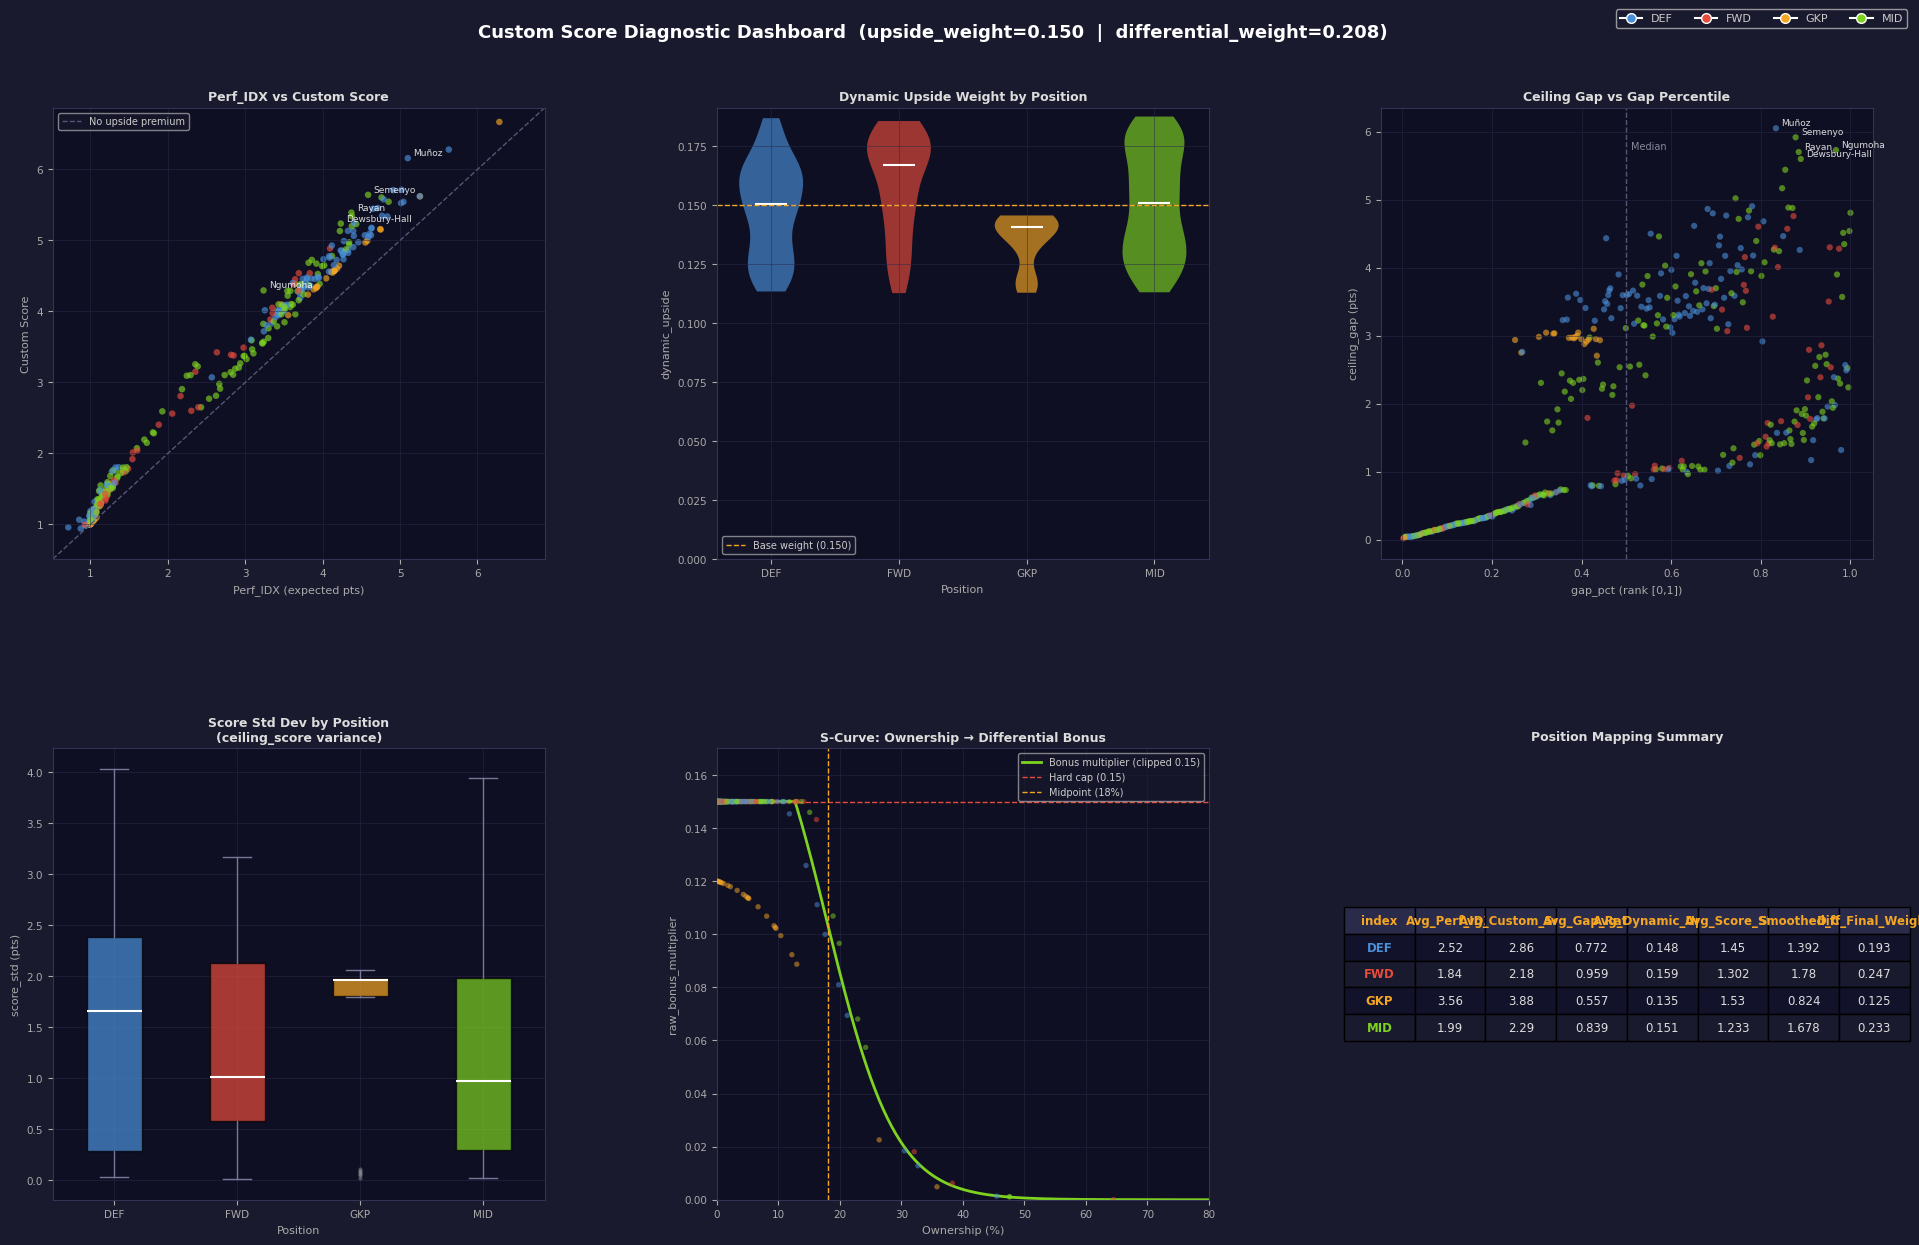

In [49]:
idx_df =  create_optimized_custom_score(
    df=gw_projection_df[gw_projection_df['gameweek'] >= GW+1].groupby(projection_group)[avg_columns].mean().reset_index(),
    differential_weight=diff_weight,
    upside_weight=upside_weight,
    visualize=True
    )

In [50]:
nan_rows = idx_df[idx_df.isna().any(axis=1)]

numeric_cols = idx_df.select_dtypes(include=np.number)
inf_rows = idx_df[np.isinf(numeric_cols).any(axis=1)]

if not nan_rows.empty:
    print("\n--- Sample row with NaN values ---")
    display(nan_rows)
    print("Columns with NaN values:", nan_rows.columns[nan_rows.isna().any()].tolist())
else:
    print("No rows with NaN values found in idx_df.")

if not inf_rows.empty:
    print("\n--- Sample row with Inf values ---")
    display(inf_rows)
else:
    print("No rows with Inf values found in idx_df.")

No rows with NaN values found in idx_df.
No rows with Inf values found in idx_df.


In [55]:
#['GKP', 'DEF', 'MID', 'FWD','all']
optimize_players_by_idx(
    df = idx_df.loc[(~idx_df.isna().any(axis=1))],
    budget =  locked_values,
    num_slots = {
        'GKP':2,
        'DEF':5,
        'MID':5,
        'FWD':3
    },
    position = 'all',
    fixed_players = [],
    banned_players = [],
    bench_factor=1e-3,

    preferred_teams_dict= {
          # 'Liverpool':1,
          # 'Chelsea':2
          },
    objective_column='custom_score',
    # objective_column='Perf_IDX'
    )


Optimal selection found for the combined squad!
Total Combined Weighted custom_score Score: 63.25
Total Combined Cost: £92.8m
[183, 5, 256, 145, 344, 227, 82, 235, 449, 807, 136, 221, 488, 100, 215]


,id_player,web_name,team_name,now_cost,position,Is_Starter,custom_score,minutes_IDX
182,183,Weiss,Burnley,4.2,GKP,1,6.669,85.522
4,5,Gabriel,Arsenal,7.3,DEF,1,6.280,89.132
255,256,Muñoz,Crystal Palace,5.9,DEF,1,6.159,81.309
144,145,De Cuyper,Brighton,4.3,DEF,1,5.714,61.777
343,344,Bijol,Leeds,3.9,DEF,1,5.709,83.858
226,227,Colwill,Chelsea,4.7,DEF,1,5.622,64.705
81,82,Semenyo,Man City,8.1,MID,1,5.642,90.000
234,235,Palmer,Chelsea,10.3,MID,1,5.606,85.361
448,449,B.Fernandes,Man Utd,10.4,MID,1,5.546,89.912
806,807,Rayan,Bournemouth,5.4,MID,1,5.392,73.318


In [56]:
display(idx_df.loc[
    # idx_df['position'] == 'GKP',
    # idx_df['team_name'].isin(["Liverpool",]),
    # idx_df['id'] == 5,
    # (idx_df['now_cost'] <= 10.5) & (idx_df['position'] == 'MID'),
    :,

    ['custom_score','captain_idx']+ display_columns
]
.sort_values('Perf_IDX',ascending = False).round(3).head(25).reset_index(drop=True)
)

,custom_score,captain_idx,id_player,now_cost,selected_by_percent,web_name,position,team_name,minutes_IDX,Perf_IDX,ceiling_score,GOAL_INDEX,ASSIST_INDEX,CLEAN_SHEET_INDEX,bonus_component,defcon_component,finishing_factor,fixture_attack_multiplier,protective_factor,fixture_defence_multiplier
0,6.669,8.339,183,4.2,0.1,Weiss,GKP,Burnley,85.522,6.284,9.219,0.000,0.000,2.666,0.071,0.000,0.944,1.030,1.007,0.866
1,6.280,8.732,5,7.3,45.5,Gabriel,DEF,Arsenal,89.132,5.630,10.062,0.543,0.151,2.333,0.032,0.812,0.985,0.951,0.965,1.092
2,5.622,7.183,221,4.3,0.2,Jörgensen,GKP,Chelsea,68.530,5.258,8.008,0.000,0.000,2.838,0.010,0.000,0.944,1.060,1.013,0.934
3,5.622,7.188,227,4.7,0.1,Colwill,DEF,Chelsea,64.705,5.256,8.016,0.012,0.061,3.060,0.038,0.108,0.944,1.060,1.005,0.934
4,6.159,9.334,256,5.9,9.9,Muñoz,DEF,Crystal Palace,81.309,5.100,11.149,1.080,0.453,1.843,0.018,0.149,1.310,1.121,0.977,1.012
5,5.543,7.536,77,4.2,7.4,Hill,DEF,Bournemouth,83.392,5.044,8.603,0.116,0.178,1.693,0.007,1.406,0.721,1.058,0.884,1.041
6,5.714,8.170,145,4.3,1.6,De Cuyper,DEF,Brighton,61.777,5.021,9.519,0.454,0.603,2.166,0.025,0.000,1.075,1.075,0.957,0.965
7,5.526,7.544,402,5.7,4.1,Aït-Nouri,DEF,Man City,71.452,5.014,8.629,0.145,0.523,2.524,0.034,0.017,0.782,1.084,0.922,1.042
8,5.709,8.317,344,3.9,1.1,Bijol,DEF,Leeds,83.858,4.914,9.775,0.573,0.108,1.604,0.007,1.014,0.988,0.961,0.975,1.095
9,5.546,7.973,449,10.4,47.6,B.Fernandes,MID,Man Utd,89.912,4.853,9.310,1.061,1.300,0.364,0.060,0.224,0.796,0.999,1.024,1.008


### NextWeek Challenges

In [57]:
Next_week_df =  gw_projection_df.loc[gw_projection_df['gameweek'] == GW+1]
Next_week_df = create_optimized_custom_score(
    df=Next_week_df,
    differential_weight=diff_weight,
    upside_weight=upside_weight,
    # visualize=True
    )

In [58]:
display(Next_week_df.loc[
    :,
    # Next_week_df['team_name'].isin(["Chelsea",]),
    # Next_week_df['position'] ==  'GKP',
    ['custom_score',]+ display_columns
]
.sort_values('Perf_IDX',ascending = False).round(3).head(25).reset_index(drop=True)
)

,custom_score,id_player,now_cost,selected_by_percent,web_name,position,team_name,minutes_IDX,Perf_IDX,ceiling_score,GOAL_INDEX,ASSIST_INDEX,CLEAN_SHEET_INDEX,bonus_component,defcon_component,finishing_factor,fixture_attack_multiplier,protective_factor,fixture_defence_multiplier
0,6.694,183,4.2,0.1,Weiss,GKP,Burnley,85.522,6.305,9.267,0.000,0.000,2.625,0.076,0.000,0.944,1.081,1.007,0.900
1,6.181,5,7.3,45.5,Gabriel,DEF,Arsenal,89.132,5.547,9.884,0.497,0.138,2.367,0.032,0.748,0.985,0.871,0.965,1.063
2,5.625,221,4.3,0.2,Jörgensen,GKP,Chelsea,68.530,5.261,8.007,0.000,0.000,2.843,0.010,0.000,0.944,1.153,1.013,0.929
3,5.626,227,4.7,0.1,Colwill,DEF,Chelsea,64.705,5.259,8.026,0.013,0.066,3.060,0.039,0.104,0.944,1.153,1.005,0.929
4,6.107,256,5.9,9.9,Muñoz,DEF,Crystal Palace,81.309,5.062,11.038,1.046,0.439,1.859,0.018,0.139,1.310,1.086,0.977,1.001
5,5.766,145,4.3,1.6,De Cuyper,DEF,Brighton,61.777,5.060,9.619,0.475,0.632,2.156,0.026,0.000,1.075,1.126,0.957,0.972
6,5.551,77,4.2,7.4,Hill,DEF,Bournemouth,83.392,5.054,8.609,0.118,0.181,1.675,0.007,1.431,0.721,1.079,0.884,1.054
7,5.875,235,10.3,12.8,Palmer,MID,Chelsea,85.361,4.996,10.231,2.212,0.501,0.391,0.072,0.013,0.899,1.153,1.030,0.929
8,5.496,402,5.7,4.1,Aït-Nouri,DEF,Man City,71.452,4.982,8.597,0.143,0.516,2.502,0.033,0.020,0.782,1.069,0.922,1.062
9,5.688,449,10.4,47.6,B.Fernandes,MID,Man Utd,89.912,4.978,9.543,1.118,1.369,0.367,0.068,0.211,0.796,1.053,1.024,0.998


In [59]:
player_list = ['Rogers','Palmer']
Next_week_df.loc[Next_week_df['web_name'].isin(player_list),['web_name','team_name','id_player']]

,web_name,team_name,id_player
29799,Rogers,Aston Villa,47
29987,Palmer,Chelsea,235


In [60]:
player_a_id = 5
player_b_id = 430

In [61]:
all_duels_df = generate_all_duels_matrix(Next_week_df)
all_duels_df.loc[
    (all_duels_df['id_player_A'] == player_a_id) &
    (all_duels_df['id_player_B'] == player_b_id)
]

,id_player_A,web_name_A,id_player_B,web_name_B,Win_%,Draw_%,Loss_%,Perf_IDX_A,Perf_IDX_B
73997,5,Gabriel,430,Haaland,87.922946,5.733039,6.344015,5.546595,1.597716


In [62]:
elo_win = 3.3
elo_loss = -5.5
evaluate_fpl_duel_discrete(Next_week_df, player_a_id, player_b_id, elo_win, elo_loss)

Matchup: Gabriel (ID: 5) vs Haaland (ID: 430)
Win: 87.9% | Exact Draw: 5.7% | Loss: 6.3%
Expected ELO: +2.49


(np.float64(2.4894729908759),
 np.float64(0.8792294646284255),
 np.float64(0.06344014852026633),
 np.float64(0.057330386851308285))

### Projection Optimize Squad

In [63]:
team_of_season_start,team_of_season_sub = create_optimal_fpl_team(budget = locked_values)


#################### Starter ####################

 id    web_name  now_cost position     team_name selected_by_percent  total_points
  1        Raya       6.1      GKP       Arsenal                35.8           156
  5     Gabriel       7.3      DEF       Arsenal                45.5           202
260       Guéhi       5.1      DEF      Man City                32.7           177
 72      Senesi       5.2      DEF   Bournemouth                21.2           169
449 B.Fernandes      10.4      MID       Man Utd                47.6           212
 82     Semenyo       8.1      MID      Man City                47.6           195
 21        Rice       7.2      MID       Arsenal                24.2           179
515 Gibbs-White       7.5      MID Nott'm Forest                 7.8           172
430     Haaland      14.7      FWD      Man City                64.5           230
136      Thiago       7.3      FWD     Brentford                32.1           177
249  João Pedro       7.5      FWD 

In [64]:
# Manual Fix
opt_fixture_player_df = fixture_player_df.copy()
minute_overrides_dict = {
    'default': {
        # 235:81,
        # 82:77,
        # 100:70,
        256:60,
    },
}

In [65]:
opt_fixture_player_df = _calculate_performance_indices(opt_fixture_player_df, params,minute_overrides=minute_overrides_dict,bonus_model=bonus_model)
opt_gw_projection_df = opt_fixture_player_df.groupby(grouping_columns).agg(agg_dict).reset_index()
opt_gw_projection_df = create_optimized_custom_score(
    df=opt_gw_projection_df,
    differential_weight=diff_weight,
    upside_weight=upside_weight,
    # visualize=True
    )

GKP: scale=0.645  intercept=5.894  R²=0.224  n=759
DEF: scale=0.974  intercept=6.926  R²=0.459  n=3208
MID: scale=1.016  intercept=6.595  R²=0.412  n=3622
FWD: scale=1.032  intercept=0.791  R²=0.761  n=829


In [66]:
# Plan for a 6-week horizon, but shrink it if we are near the end of the season (GW38)
default_horizon = min(6, 38 - GW + 1)


In [67]:
plan_sequential_transfers(
      gw_projection_df = opt_gw_projection_df,
      current_team_ids = get_my_player_ids(MY_FPL_ID, GW),
      start_gameweek = GW+1,
      planning_horizon = default_horizon,
      initial_free_transfers=current_free_transfer_avaliable,
      current_realizable_value_dict = current_realizable_value_dict,
      bank_balance= bank_values,

      ft_value = 1.23,
      bench_factor=1e-4,

      objective_column='custom_score',
      captain_column='captain_idx',

      # WC_WEEK = 24,
      # FH_WEEK = 34,
      # BB_WEEK = 33,
      # TC_WEEK = 26,

      fixed_player_dict = {
          'Default':[],
          },
      banned_player_dict = {
          'Default':[183,221,],
          },
    )

Successfully fetched your team IDs for Gameweek 36:
[736, 256, 5, 151, 82, 488, 235, 449, 136, 100, 430, 139, 457, 77, 343]

--- Running Sequential Transfer Planner for GW37 ---

Optimal Sequential Transfer Plan Found!
Projected Total Utility: 139.91

==================== Plan for Gameweek 37 ====================
Free Transfers Available: 1
Transfers Made: 1 (Hits Cost: 0)

--> OUT:
 id_player web_name team_name position  now_cost  custom_score  captain_idx  selected_by_percent  minutes_IDX  fixture_attack_multiplier  fixture_defence_multiplier  GOAL_INDEX  ASSIST_INDEX  CLEAN_SHEET_INDEX  bonus_component  defcon_component
       343  Struijk     Leeds      DEF       4.2         1.192        1.778                  2.5       43.596                      0.964                       1.098       0.122          0.05                0.0            0.001             0.015

<-- IN:
 id_player  web_name team_name position  now_cost  custom_score  captain_idx  selected_by_percent  minutes_IDX  fix

# Experiment


## Tuning

In [ ]:
## Tuning

start_time = time.time()

run_phase1 = False
run_phase2 = False
run_phase3 = False

# =============================================================================
# PARAM CONTRACT - Single Source of Truth
# =============================================================================

PARAM_CONTRACT = {
    # --- LOCKED STRUCTURAL PARAMS ---
    'fixture_alpha_att': 0.09,
    'fixture_alpha_def': 0.07,
    'blend_alpha': 0.50,
    'min_fixtures_full_trust': 15,

    'cs_clip_lower': 0.10,
    'cs_clip_upper': 0.765,
    'finishing_factor_clip_lower': 0.50,
    'finishing_factor_clip_upper': 1.69,
    'protective_factor_clip_lower': 0.65,
    'protective_factor_clip_upper': 1.50,

    'minutes_role_floor': 0.42,
    'minutes_loyalty_w': 0.95,
    'minutes_trend_scale': 0.10,
    'minutes_high_streak': 3.0,
    'minutes_low_vol_thresh': 45.0,

    'league_avg_xG': 1.45,          # Forced to neutral
    'league_avg_xGC': 1.45,         # Forced to neutral

    # --- ADAPTIVE / TUNABLE PARAMS (Defaults) ---
    'minutes_w_form': 0.94,
    'minutes_w_haaland_season': 0.1,
    'minutes_ema_alpha': 0.805,
    'minutes_w_gk_form': 1.0,
    'recency_ema_alpha': 0.0,
    'rolling_ema_alpha': 0.26,
    'c_finish': 0.5,
    'c_protect': 12.1,
    'c_base_defense': 8.0,
}

def validate_and_fill_params(params: dict, contract: dict, silent: bool = False) -> dict:
    """
    Ensures every key in contract exists in params.
    Fills missing keys with contract defaults.
    """
    result = params.copy()
    missing, filled = [], []
    for key, default in contract.items():
        if key not in result:
            result[key] = default
            filled.append(f"  {key} = {default}  <- filled from contract")

    if filled and not silent:
        print("WARNING: validate_and_fill_params missing keys auto-filled:")
        print("\n".join(filled))
    return result

def early_stopping_callback(study, trial, patience=40):
    """Stops the study if no improvement is found after 'patience' trials."""
    if trial.number >= patience:
        best_trial_num = study.best_trial.number
        if trial.number - best_trial_num >= patience:
            print(f"\nStopping early: No improvement in the last {patience} trials.")
            study.stop()

def _get_stable_eval_df(df: pd.DataFrame, skip_gws: int = 4) -> pd.DataFrame:
    """Filters out the first `skip_gws` gameweeks of each season to reduce noise."""
    if 'season' in df.columns:
        min_gw_per_season = df.groupby('season')['gameweek'].transform('min')
        return df[df['gameweek'] >= min_gw_per_season + skip_gws]
    else:
        df = df.sort_values(['id_player', 'gameweek']).copy()
        gw_vals = df['gameweek'].values
        season_ids = np.cumsum(np.append(0, np.diff(gw_vals) < 0))
        df['__proxy_season'] = season_ids
        min_gw = df.groupby('__proxy_season')['gameweek'].transform('min')
        stable_df = df[df['gameweek'] >= min_gw + skip_gws].drop(columns=['__proxy_season'])
        return stable_df

def _reapply_minutes_ema(base_df: pd.DataFrame, params: dict, raw_history_df: pd.DataFrame) -> pd.DataFrame:
    alpha = params.get('minutes_ema_alpha', 0.40)
    df = base_df.copy()

    finished_fixture_ids = df[df['finished'] == True]['id_fixture'].unique()
    hist = raw_history_df.drop_duplicates(subset=['id_player', 'id_fixture'])
    hist = hist[hist['id_fixture'].isin(finished_fixture_ids)].sort_values(['id_player', 'kickoff_time'])

    hist['past_ema'] = (
        hist.groupby('id_player')['minutes']
        .transform(lambda x: x.shift(1).ewm(alpha=alpha, adjust=False).mean())
        .fillna(0)
    )

    hist['full_ema'] = (
        hist.groupby('id_player')['minutes']
        .ewm(alpha=alpha, adjust=False)
        .mean()
        .reset_index(level=0, drop=True)
    )
    latest_emas = hist.groupby('id_player')['full_ema'].last()

    past_map = hist.set_index(['id_player', 'id_fixture'])['past_ema']
    df['recent_minutes_form'] = df.set_index(['id_player', 'id_fixture']).index.map(past_map).values

    future_mask = df['recent_minutes_form'].isna()
    df.loc[future_mask, 'recent_minutes_form'] = df.loc[future_mask, 'id_player'].map(latest_emas).fillna(0)

    return df

# =============================================================================
# 1. INITIALIZATION & DATA LOADING
# =============================================================================
player_df         = get_current_players_df()
active_player_ids = player_df['id'].unique()
fpl_team_df       = get_team_df() # Required for blend_team_ratings

raw_history_df = await fetch_raw_history_cache(active_player_ids, use_cache=True)
bonus_model  = _fit_bonus_multinomial(raw_history_df)
_diagnose_bonus_model(bonus_model)

BASE_CONSTANTS = PARAM_CONTRACT.copy()

# --- FIX 1: Generate Base xG Ratings for the Tuning Environment ---
_base_roll, _base_latest = compute_rolling_team_ratings(
    raw_history_df, ema_alpha=BASE_CONSTANTS['rolling_ema_alpha']
)
base_team_ratings, base_latest_ratings = blend_team_ratings(
    _base_roll, _base_latest, fpl_team_df,
    league_avg_xG=BASE_CONSTANTS['league_avg_xG'],
    league_avg_xGC=BASE_CONSTANTS['league_avg_xGC'],
    blend_alpha=BASE_CONSTANTS['blend_alpha'],
    min_fixtures_full_trust=BASE_CONSTANTS['min_fixtures_full_trust']
)

global_dists = compute_global_z_distributions(base_team_ratings)

MAX_GW       = get_max_finished_gameweek()
TRAIN_CUTOFF = MAX_GW - 5

train_raw_history_df = raw_history_df[raw_history_df['gameweek'] <= TRAIN_CUTOFF].copy()

# Pass the xG ratings into the base DataFrame
static_base_df = get_fixture_players_stats_df(
    BASE_CONSTANTS, raw_history_df, global_dists,
    team_ratings_df=base_team_ratings,
    latest_team_ratings=base_latest_ratings
)
train_base_df  = static_base_df[static_base_df['gameweek'] <= TRAIN_CUTOFF]

base_reg_params = _fit_regression_params(train_base_df)
BASE_CONSTANTS.update(base_reg_params)

print("Bootstrapping BPS calibration...")
bootstrap_df = _calculate_performance_indices(
    train_base_df,
    BASE_CONSTANTS,
    bonus_model=bonus_model,
    bps_calibrators=None,
)
bps_calibrators = fit_bps_calibration(
    bootstrap_df[bootstrap_df['finished'] == True],
    estimate_col='estimate_bps_calibrate',
    actual_col='actual_avg_bps',
    min_minutes=45,
)
print("BPS calibrators fitted and frozen.\n")

# =============================================================================
# SHARED UTILITY - split train gameweeks into N chunks
# =============================================================================
def _get_gw_chunks(df: pd.DataFrame, n_chunks: int = 5) -> list[np.ndarray]:
    train_gws = sorted(df['gameweek'].unique())
    return [arr for arr in np.array_split(train_gws, n_chunks) if len(arr) > 0]


# =============================================================================
# PHASE 1 / 1.5 - MedianPruner with 5-chunk GW steps
# =============================================================================
def run_minutes_optimization(base_params, precomputed_df, raw_history_df, n_trials=500, seed=42):

    def objective_minutes(trial):
        params = base_params.copy()
        params.update({
            'minutes_w_form':           trial.suggest_float('minutes_w_form',           0.50, 1.00),
            'minutes_w_haaland_season': trial.suggest_float('minutes_w_haaland_season', 0.10, 0.98),
            'minutes_role_floor':       trial.suggest_float('minutes_role_floor',       0.05, 0.50),
            'minutes_ema_alpha':        trial.suggest_float('minutes_ema_alpha',        0.20, 0.95),
            'minutes_loyalty_w':        trial.suggest_float('minutes_loyalty_w',        0.40, 0.95),
            'minutes_trend_scale':      trial.suggest_float('minutes_trend_scale',      0.10, 1.20),
            'minutes_high_streak':      trial.suggest_int('minutes_high_streak',        2.00, 6.00),
            'minutes_low_vol_thresh':   trial.suggest_float('minutes_low_vol_thresh',   5.00, 45.0),
        })
        params = validate_and_fill_params(params, PARAM_CONTRACT, silent=True)

        trial_df = _reapply_minutes_ema(precomputed_df, params, raw_history_df)
        temp_df  = _calculate_performance_indices(
            trial_df[trial_df['gameweek'] <= TRAIN_CUTOFF], params, bonus_model=bonus_model,bps_calibrators=bps_calibrators,
        )

        eval_df = temp_df[
            (temp_df['chance_of_playing_next_round'].fillna(100) == 100) &
            (temp_df['finished'] == True)
        ]

        eval_df = _get_stable_eval_df(eval_df, skip_gws=4)
        gw_chunks = _get_gw_chunks(eval_df, n_chunks=5)

        cumulative_gws = []
        last_loss = None

        for step, chunk in enumerate(gw_chunks):
            cumulative_gws.extend(chunk.tolist())
            chunk_eval = eval_df[eval_df['gameweek'].isin(cumulative_gws)]

            if len(chunk_eval) == 0:
                continue

            loss = minutes_composite_loss(
                chunk_eval['actual_minutes'].values,
                chunk_eval['minutes_IDX'].values,
            )
            trial.report(loss, step)
            last_loss = loss

            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return last_loss

    pruner_p1 = optuna.pruners.PatientPruner(
        optuna.pruners.MedianPruner(
            n_startup_trials=40,
            n_warmup_steps=1,
            interval_steps=1
        ),
        patience=1
    )

    study = optuna.create_study(
        direction='minimize',
        sampler=module.AutoSampler(seed=seed),
        pruner=pruner_p1,
    )
    study.optimize(objective_minutes, n_trials=n_trials, n_jobs=1, show_progress_bar=True,callbacks=[lambda study, trial: early_stopping_callback(study, trial, patience=50)])

    best = get_averaged_production_params(
        study, top_k=5, primary_metric_idx=0, maximize_primary=False
    )
    return {k: round(round(v / 0.005) * 0.005, 3) for k, v in best.items()}

# =============================================================================
# PHASE 1 - 500 trials
# =============================================================================
if run_phase1:
    print("Phase 1: Minutes Optimization (250 trials)...")
    best_minutes_v1 = run_minutes_optimization(BASE_CONSTANTS, static_base_df, raw_history_df, n_trials=250, seed=42)
else:
    best_minutes_v1 = {}

# =============================================================================
# PHASE 2 - MedianPruner, aggressive (expensive per trial)
# =============================================================================
def objective_alphas(trial):
    params = {**BASE_CONSTANTS, **best_minutes_v1}
    params.update({
        # Only tune these two now; the rest are locked in BASE_CONSTANTS
        'recency_ema_alpha' : trial.suggest_float('recency_ema_alpha', 0.00, 0.40),
        'rolling_ema_alpha' : trial.suggest_float('rolling_ema_alpha', 0.05, 0.40),
    })
    params = validate_and_fill_params(params, PARAM_CONTRACT, silent=True)

    # --- FIX 2: Compute rolling stats INSIDE the trial using the trial's alpha ---
    _trial_rolling, _trial_latest = compute_rolling_team_ratings(
        raw_history_df, ema_alpha=params['rolling_ema_alpha']
    )

    _team_ratings, _latest = blend_team_ratings(
        _trial_rolling, _trial_latest, fpl_team_df,
        league_avg_xG           = params['league_avg_xG'],
        league_avg_xGC          = params['league_avg_xGC'],
        blend_alpha             = params['blend_alpha'],
        min_fixtures_full_trust = params['min_fixtures_full_trust'],
    )

    _global_dists = compute_global_z_distributions(_team_ratings)

    trial_df = get_fixture_players_stats_df(
        params, raw_history_df, _global_dists,
        team_ratings_df     = _team_ratings,
        latest_team_ratings = _latest,
    )
    train_df = trial_df[trial_df['gameweek'] <= TRAIN_CUTOFF]

    dynamic_reg = _fit_regression_params(train_df)
    params.update(dynamic_reg)

    temp_df   = _calculate_performance_indices(
        train_df, params, bonus_model=bonus_model, bps_calibrators=bps_calibrators
    )
    eval_base = temp_df[temp_df['actual_minutes'] > 0]
    eval_base = _get_stable_eval_df(eval_base, skip_gws=4)

    gw_chunks      = _get_gw_chunks(eval_base, n_chunks=3)
    cumulative_gws = []
    last_score     = None

    for step, chunk in enumerate(gw_chunks):
        cumulative_gws.extend(chunk.tolist())
        chunk_eval = eval_base[eval_base['gameweek'].isin(cumulative_gws)]
        if len(chunk_eval) == 0:
            continue
        score = calculate_overall_score(
            chunk_eval, 'actual_points', 'fixture_calibrated_points'
        )
        trial.report(score, step)
        last_score = score
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return last_score

pruner_p2 = optuna.pruners.MedianPruner(
    n_startup_trials=20,
    n_warmup_steps=0,
    interval_steps=1
)

if run_phase2:
    print("\nPhase 2: Alpha + Recency Optimization (100 trials)...")
    study_alphas = optuna.create_study(
        direction='maximize',
        sampler=module.AutoSampler(seed=42),
        pruner=pruner_p2,
    )
    study_alphas.optimize(objective_alphas, n_trials=100, n_jobs=1, show_progress_bar=True,callbacks=[lambda study, trial: early_stopping_callback(study, trial, patience=50)])

    best_alphas = get_averaged_production_params(study_alphas, top_k=3, primary_metric_idx=0, maximize_primary=True)
    best_alphas = {k: round(round(v / 0.005) * 0.005, 3) for k, v in best_alphas.items()}
else:
    best_alphas = {}

# =============================================================================
# PHASE 2.5 - 150 trials
# =============================================================================
if run_phase2:
    print("\nPhase 2.5: Minutes Refinement with Best Alphas (150 trials)...")

    base_for_refinement = {**BASE_CONSTANTS, **best_alphas}
    base_for_refinement = validate_and_fill_params(base_for_refinement, PARAM_CONTRACT)

    # --- FIX 3a: Rebuild the exact ratings using the newly discovered best_alphas ---
    _opt_roll, _opt_latest = compute_rolling_team_ratings(raw_history_df, ema_alpha=base_for_refinement['rolling_ema_alpha'])
    opt_team_ratings, opt_latest = blend_team_ratings(
        _opt_roll, _opt_latest, fpl_team_df,
        league_avg_xG=base_for_refinement['league_avg_xG'], league_avg_xGC=base_for_refinement['league_avg_xGC'],
        blend_alpha=base_for_refinement['blend_alpha'], min_fixtures_full_trust=base_for_refinement['min_fixtures_full_trust']
    )
    opt_dists = compute_global_z_distributions(opt_team_ratings)

    static_alpha_df = get_fixture_players_stats_df(
        base_for_refinement, raw_history_df, opt_dists,
        team_ratings_df=opt_team_ratings, latest_team_ratings=opt_latest
    )

    final_minutes = run_minutes_optimization(base_for_refinement, static_alpha_df, raw_history_df, n_trials=150, seed=123)
else:
    final_minutes = {}

# =============================================================================
# PHASE 3 - MedianPruner (9 params, 500 trials)
# =============================================================================
master_params = BASE_CONSTANTS.copy()
master_params.update(final_minutes)
master_params.update(best_alphas)
master_params = validate_and_fill_params(master_params, PARAM_CONTRACT)

# --- FIX 3b: Rebuild safely for Phase 3 based on master_params ---
_master_roll, _master_latest = compute_rolling_team_ratings(raw_history_df, ema_alpha=master_params['rolling_ema_alpha'])
master_team_ratings, master_latest = blend_team_ratings(
    _master_roll, _master_latest, fpl_team_df,
    league_avg_xG=master_params['league_avg_xG'], league_avg_xGC=master_params['league_avg_xGC'],
    blend_alpha=master_params['blend_alpha'], min_fixtures_full_trust=master_params['min_fixtures_full_trust']
)
master_dists = compute_global_z_distributions(master_team_ratings)

static_perf_df  = get_fixture_players_stats_df(
    master_params, raw_history_df, master_dists,
    team_ratings_df=master_team_ratings, latest_team_ratings=master_latest
)
train_perf_df   = static_perf_df[static_perf_df['gameweek'] <= TRAIN_CUTOFF]

pre_fit_reg_params = _fit_regression_params(train_perf_df)
master_params.update(pre_fit_reg_params)

def objective_perf_idx(trial):
    params = master_params.copy()
    params.update({
        # Removed the clip limits, only tune the Bayesian Shrinkage
        'c_finish':       trial.suggest_float('c_finish',       0.5,  15.0),
        'c_protect':      trial.suggest_float('c_protect',      0.5,  15.0),
        'c_base_defense': trial.suggest_float('c_base_defense', 8.0,  50.0),
    })
    params = validate_and_fill_params(params, PARAM_CONTRACT, silent=True)

    temp_df   = _calculate_performance_indices(train_perf_df, params, bonus_model=bonus_model,bps_calibrators=bps_calibrators,)
    eval_base = temp_df[temp_df['actual_minutes'] > 0]

    eval_base = _get_stable_eval_df(eval_base, skip_gws=4)

    gw_chunks = _get_gw_chunks(eval_base, n_chunks=5)
    cumulative_gws = []
    last_score = None

    for step, chunk in enumerate(gw_chunks):
        cumulative_gws.extend(chunk.tolist())
        chunk_eval = eval_base[eval_base['gameweek'].isin(cumulative_gws)]

        if len(chunk_eval) == 0:
            continue

        score = calculate_overall_score(chunk_eval, 'actual_points', 'fixture_calibrated_points')
        trial.report(score, step)
        last_score = score

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return last_score

pruner_p3 = optuna.pruners.PatientPruner(
    optuna.pruners.PercentilePruner(
        percentile=75.0,
        n_startup_trials=50,
        n_warmup_steps=1,
        interval_steps=1
    ),
    patience=1
)

if run_phase3:
    print("\nPhase 3: Perf Index Tuning (500 trials)...")
    study_perf = optuna.create_study(
        direction='maximize',
        sampler=module.AutoSampler(seed=42),
        pruner=pruner_p3,
    )
    study_perf.optimize(objective_perf_idx, n_trials=500, n_jobs=1, show_progress_bar=True,callbacks=[lambda study, trial: early_stopping_callback(study, trial, patience=50)])

    final_perf_params = get_averaged_production_params(study_perf, top_k=5, primary_metric_idx=0, maximize_primary=True)
    final_perf_params = {k: round(round(v / 0.005) * 0.005, 3) for k, v in final_perf_params.items()}
else:
    final_perf_params = {}

# =============================================================================
# 6. FINAL AGGREGATION & HOLDOUT VALIDATION
# =============================================================================
print("\nExtracting Final Parameters & Validating on Holdout...")

REGRESSION_KEYS = set(pre_fit_reg_params.keys())

final_param = PARAM_CONTRACT.copy()
final_param.update(BASE_CONSTANTS)
final_param.update(final_minutes)
final_param.update(best_alphas)
final_param.update(final_perf_params)
final_param.update(pre_fit_reg_params)

final_param = validate_and_fill_params(final_param, PARAM_CONTRACT)

holdout_df = static_perf_df[static_perf_df['gameweek'] > TRAIN_CUTOFF]
if not holdout_df.empty:
    val_temp_df = _calculate_performance_indices(holdout_df, final_param, bonus_model=bonus_model,bps_calibrators=bps_calibrators,)
    val_eval_df = val_temp_df[val_temp_df['actual_minutes'] > 0]
    val_score   = calculate_overall_score(val_eval_df, 'actual_points', 'fixture_calibrated_points')
    print(f"\nHoldout (Composite Score): {val_score:.4f}")
else:
    print("\nNot enough gameweeks for holdout validation.")

final_param_clean = {k: v for k, v in final_param.items() if k not in REGRESSION_KEYS}

missing = [k for k in PARAM_CONTRACT if k not in final_param_clean]
assert not missing, f"FATAL: params missing after full pipeline: {missing}"

display(final_param_clean)
print(f"CPU times: Wall time: {time.time() - start_time:.2f} s")

Loading raw match history from raw_history_cache.parquet...
   bps    P(0)    P(1)    P(2)    P(3)  E(bonus)
     0   1.000   0.000   0.000   0.000     0.000
     5   1.000   0.000   0.000   0.000     0.000
    10   0.999   0.001   0.000   0.000     0.001
    15   0.994   0.005   0.001   0.000     0.007
    20   0.966   0.028   0.006   0.001     0.041
    25   0.810   0.126   0.052   0.012     0.267
    30   0.350   0.289   0.250   0.111     1.123
    35   0.050   0.219   0.398   0.333     2.014
    40   0.004   0.092   0.351   0.553     2.453
    50   0.000   0.009   0.151   0.840     2.831
    60   0.000   0.001   0.049   0.951     2.950
    70   0.000   0.000   0.014   0.986     2.986


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Bootstrapping BPS calibration...
GKP: scale=0.779  intercept=4.222  R²=0.285  n=657
DEF: scale=0.971  intercept=7.006  R²=0.454  n=2765
MID: scale=0.995  intercept=6.677  R²=0.410  n=3145
FWD: scale=1.012  intercept=0.922  R²=0.752  n=701
GKP: scale=0.779  intercept=4.222  R²=0.285  n=657
DEF: scale=0.971  intercept=7.006  R²=0.454  n=2765
MID: scale=0.995  intercept=6.677  R²=0.410  n=3145
FWD: scale=1.012  intercept=0.922  R²=0.752  n=701
BPS calibrators fitted and frozen.


Extracting Final Parameters & Validating on Holdout...

Holdout (Composite Score): 0.2788


/tmp/ipykernel_3140/235866893.py:437: ExperimentalWarning: PatientPruner is experimental (supported from v2.8.0). The interface can change in the future.
  pruner_p3 = optuna.pruners.PatientPruner(


{'fixture_alpha_att': 0.09,
 'fixture_alpha_def': 0.07,
 'blend_alpha': 0.5,
 'min_fixtures_full_trust': 15,
 'cs_clip_lower': 0.1,
 'cs_clip_upper': 0.765,
 'finishing_factor_clip_lower': 0.5,
 'finishing_factor_clip_upper': 1.69,
 'protective_factor_clip_lower': 0.65,
 'protective_factor_clip_upper': 1.5,
 'minutes_role_floor': 0.42,
 'minutes_loyalty_w': 0.95,
 'minutes_trend_scale': 0.1,
 'minutes_high_streak': 3.0,
 'minutes_low_vol_thresh': 45.0,
 'league_avg_xG': 1.45,
 'league_avg_xGC': 1.45,
 'minutes_w_form': 0.94,
 'minutes_w_haaland_season': 0.1,
 'minutes_ema_alpha': 0.805,
 'minutes_w_gk_form': 1.0,
 'recency_ema_alpha': 0.0,
 'rolling_ema_alpha': 0.26,
 'c_finish': 0.5,
 'c_protect': 12.1,
 'c_base_defense': 8.0}

CPU times: Wall time: 13.75 s
